# Data & Env Initialization

In [1]:
import os, sys, gc

import zipfile
from os import path
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

zip_file = "Sky-dataset/Sky303.zip"
data_path = "Sky-dataset/Sky303/"

if not path.exists(data_path):
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall("Sky-dataset/")

input_indice_path = data_path + "input_indices_{}.npy"
input_data_path = data_path + "input_data_{}.npy"
target_path = data_path + "output_indices_{}.npy"

# Constants

In [2]:
N_CONFIGURATIONS = 4262 # number of configurations of the problem
IMG_SHAPE = (1355, 3384, 3)
H, W = 128, 256 # the window size

CAMERA = np.array([[2304.5479, 0,  1686.2379], # the camera matrix
                          [0, 2305.8757, -0.0151],
                          [0, 0, 1.]], dtype=np.float32)

# Data Viz & Utils

In [3]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

np.random.seed(42)
torch.manual_seed(42)
torch.__version__

'1.3.1+cu92'

In [4]:
class Sky303Dataset(Dataset):
    """Car dataset."""

    def __init__(self):
        super(Sky303Dataset,self).__init__()

    def __len__(self):
        return N_CONFIGURATIONS

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
            
        indice_np = np.load(input_indice_path.format(idx))
        input_np = np.load(input_data_path.format(idx))
        target_np = np.load(target_path.format(idx))
        
        input_bin_mask = np.zeros([H, W, 1], dtype='float16')
        input_bin_mask[indice_np[:,0],indice_np[:,1],:] = 1.
        
        input_2Drepr = np.zeros([H, W, 3], dtype='float16')
        input_2Drepr[indice_np[:,0],indice_np[:,1],:] = input_np
        
        target_2Drepr = np.zeros([H, W, 1], dtype='float16')
        target_2Drepr[target_np[:,0],target_np[:,1],:] = 1.
        
        input_bin_mask = np.rollaxis(input_bin_mask, 2, 0)
        input_bin_mask = torch.from_numpy(input_bin_mask).float()
        
        input_2Drepr = np.rollaxis(input_2Drepr, 2, 0)
        input_2Drepr = torch.from_numpy(input_2Drepr).float()
        
        target_2Drepr = np.rollaxis(target_2Drepr, 2, 0)
        target_2Drepr = torch.from_numpy(target_2Drepr).float()
        
        return [input_bin_mask, input_2Drepr, target_2Drepr]

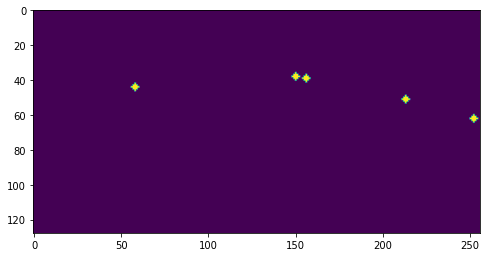

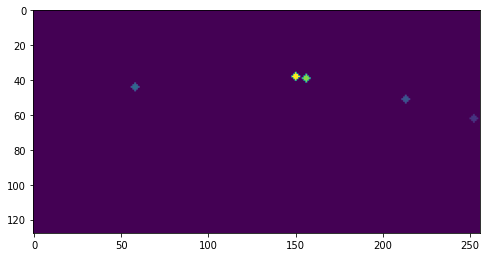

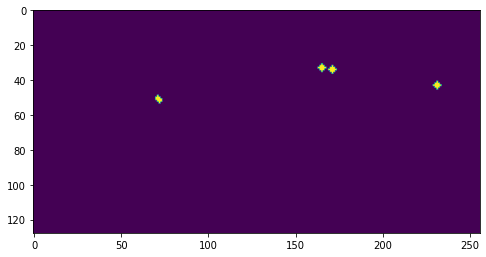

In [5]:
dataset = Sky303Dataset()
input_bin_mask, input_2Drepr, target_2Drepr = dataset[0]

plt.figure(figsize=(8,8))
plt.imshow((input_bin_mask.permute(1,2,0).numpy()[:,:,-1]).squeeze())
plt.show()

plt.figure(figsize=(8,8))
plt.imshow(input_2Drepr.permute(1,2,0).numpy()[:,:,-1]/350.)
plt.show()

plt.figure(figsize=(8,8))
plt.imshow((target_2Drepr.permute(1,2,0).numpy()[:,:,-1]).squeeze())
plt.show()

# Model

In [6]:
import torch.nn as nn
import torch.optim as optim
from smap import *

# Gets the GPU if there is one, otherwise the cpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [7]:
class Model(nn.Module):
    def __init__(self, camera_matrix, n=0):
        super(Model,self).__init__()
        self.n = n
        self.camera_matrix = nn.Parameter(torch.from_numpy(camera_matrix), requires_grad=False)
        self.camera_matrix_inv = nn.Parameter(torch.from_numpy(np.linalg.inv(camera_matrix)), requires_grad=False)
        
        self.phi = nn.Parameter(torch.from_numpy(np.array([.0])).float().reshape(1,1), requires_grad=True)
        self.gamma = nn.Parameter(torch.from_numpy(np.array([.0])).float().reshape(1,1), requires_grad=True)
        self.rho = nn.Parameter(torch.from_numpy(np.array([.0])).float().reshape(1,1), requires_grad=True)
        self.theta = nn.Parameter(torch.from_numpy(np.array([0.,-0.,0.])).float().reshape(1,3,1,1), requires_grad=True)
        self.smap_layer = SMap(IMG_SHAPE[0], IMG_SHAPE[1], camera_matrix, device, n)
        
        self.I00 = nn.Parameter(torch.from_numpy(np.array([[1.,.0,.0],[.0,0.,.0],[.0,.0,0.]])).float().reshape(3,3), requires_grad=False)
        self.I01 = nn.Parameter(torch.from_numpy(np.array([[0.,1.,.0],[.0,0.,.0],[.0,.0,0.]])).float().reshape(3,3), requires_grad=False)
        self.I10 = nn.Parameter(torch.from_numpy(np.array([[0.,.0,.0],[1.,0.,.0],[.0,.0,0.]])).float().reshape(3,3), requires_grad=False)
        self.I11 = nn.Parameter(torch.from_numpy(np.array([[0.,.0,.0],[.0,1.,.0],[.0,.0,0.]])).float().reshape(3,3), requires_grad=False)
        self.I22 = nn.Parameter(torch.from_numpy(np.array([[0.,.0,.0],[.0,0.,.0],[.0,.0,1.]])).float().reshape(3,3), requires_grad=False)
        
        self.net = nn.Sequential(nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1, bias=True), 
                                 nn.ReLU(), 
                                 nn.Conv2d(16, 64, kernel_size=3, stride=1, padding=1, bias=True), 
                                 nn.ReLU(), 
                                 nn.Conv2d(64, 1, kernel_size=3, stride=1, padding=1, bias=True))
        
        from tools.testing.vtest.vtest_types import NoneBot
        def get_activation_grad():
            def hook(module, grad_input, grad_output):
                print("grad_output[0].shape")
                print(grad_output[0].shape)
                
                print((grad_output[0]).min())
                print((grad_output[0]).max())
                grad_out = (grad_output[0])[0:1,0,:,:]
                print(grad_out)
                plt.figure(figsize=(8,8))
                plt.imshow((grad_out.permute(1,2,0).detach().cpu().numpy()[:,:,-1]).squeeze())
                plt.show()
            return hook

        self.bot = NoneBot()
        self.bot.register_backward_hook(get_activation_grad())
        
    def forward(self, r_x, r_mask, target_2Dr=None, zoom=0):
        from smap import utils
        mask = self.bot(torch.sigmoid(1e-2*self.net(r_mask)))
        
        x = 1.*(r_x[:,-1:,:,:])
        height, width = x.size(-2), x.size(-1)
        panels = list(np.where(np.ones([height, width])))
        panels[0] = panels[0] + .5
        panels[1] = panels[1] + .5
        
        x = utils.to_3d(x.reshape(-1,1,height,width), height, width, panels, (height, width), IMG_SHAPE, self.camera_matrix_inv, device)
        
        phi = torch.tanh(3e-2*self.phi)*np.pi
        gamma = torch.tanh(3e-2*self.gamma)*np.pi
        rho = torch.tanh(3e-2*self.rho)*np.pi
        r = torch.cos(phi)*self.I00-torch.sin(phi)*self.I01+torch.sin(phi)*self.I10+torch.cos(phi)*self.I11+self.I22
        y = torch.cos(gamma)*self.I00-torch.sin(gamma)*self.I01+torch.sin(gamma)*self.I10+torch.cos(gamma)*self.I11+self.I22
        p = torch.cos(rho)*self.I00-torch.sin(rho)*self.I01+torch.sin(rho)*self.I10+torch.cos(rho)*self.I11+self.I22
        
        x_r = torch.einsum('bdef,cd->bcef',x,r.detach())+torch.einsum('bdef,cd->bcef',torch.sign(x),(r-r.detach()))
        x_r = torch.cat([x_r[:,1:,:,:],x_r[:,:1,:,:]],dim=1)
        x_r = torch.einsum('bdef,cd->bcef',x_r,y.detach())+torch.einsum('bdef,cd->bcef',torch.sign(x_r),(y-y.detach()))
        x_r = torch.cat([x_r[:,1:,:,:],x_r[:,:1,:,:]],dim=1)
        x_r = torch.einsum('bdef,cd->bcef',x_r,p.detach())+torch.einsum('bdef,cd->bcef',torch.sign(x_r),(p-p.detach()))
        x_r = torch.cat([x_r[:,1:,:,:],x_r[:,:1,:,:]],dim=1)
        
        x_t = (x_r.detach()+(mask>.5).float()*self.theta)
        x_t = torch.where((x[:,-1:,:,:])>0.,x_t,x_t.detach())
        x_t = torch.where((mask>.5),x_t,torch.zeros_like(x_t))
        k_t = torch.where((x_t[:,-1:,:,:])>3e2, (x_t[:,-1:,:,:])-(x_t[:,-1:,:,:]).detach()+3e2,(x_t[:,-1:,:,:])+torch.exp(-1e2*(x_t[:,-1:,:,:]).detach()))
        k_t = 5./k_t
        
        x_r = x_r+(mask>.5).float()*self.theta.detach()

        weights = self.smap_layer(torch.cat([k_t*x_t+(x_r-x_r.detach()), mask], dim=1), target_2Dr, zoom)
        
        return phi, gamma, rho, mask, weights

In [8]:
def create_model(camera_matrix, n):
    return Model(camera_matrix, n)

# Datasets

In [9]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader, SequentialSampler, SubsetRandomSampler

In [10]:
train_idx, valid_idx= train_test_split(
    np.random.choice(np.arange(N_CONFIGURATIONS), size=512, replace=False), test_size=0.25, random_state=0, shuffle=True)

train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SequentialSampler(valid_idx)

# Training

In [11]:
def l1_error(pred, target):
    from smap import specials
    shapes = target.size()
    m_batch_size, height, width = shapes[0], shapes[-2], shapes[-1]
    
    pred_m = (torch.max((pred>specials.OFF_THRESH).reshape(m_batch_size, -1, height*width),dim=1,keepdim=True).values).float()
    abs_pred = torch.abs(pred)
    pred = ((1.-2e-3)*abs_pred.detach()+1e-3+(2.*((pred)>0.).float()-1.)*(pred-pred.detach())).reshape(m_batch_size, -1, height*width)
    target_m = target.reshape(m_batch_size, 1, -1)
    
    loss = torch.abs(pred-target_m)
    loss_m = torch.abs(pred_m-target_m)
    
    denom = loss.reshape(m_batch_size, -1).sum(dim=1)
    denom = torch.where(denom>1e1,denom,0.*denom+1e-1)
    loss = loss.reshape(m_batch_size, -1).sum(dim=1)/denom.detach()
    loss_m = loss_m.reshape(m_batch_size, -1).sum(dim=1)
    
    loss = torch.mean(loss_m.detach()+1e5*(loss-loss.detach()))
    return loss

def train_loop_fn(loader, zoom, epoch, history=None):
    model.train()
    for batch_idx, (r_mask_batch, input_2Dr_batch, target_2Dr_batch) in enumerate(tqdm(loader)):
        m_batchsize, height, width = r_mask_batch.size(0), r_mask_batch.size(-2), r_mask_batch.size(-1)
        if m_batchsize != batch_size:
            break
        else:
            r_mask_batch, input_2Dr_batch, target_2Dr_batch = r_mask_batch.to(device), input_2Dr_batch.to(device), target_2Dr_batch.to(device)

        optimizer.zero_grad()
        
        r, p, y, r_mask, weights = model(input_2Dr_batch, r_mask_batch, target_2Dr_batch, zoom)
        
        target_2Dr = target_2Dr_batch.reshape(m_batchsize,1,H//(2**zoom),(2**zoom),W//(2**zoom),(2**zoom)).permute(0,3,5,1,2,4).reshape(m_batchsize,(2**(zoom+zoom)),1,H//(2**zoom),W//(2**zoom))
        target_2Dr, _ = torch.max(target_2Dr,dim=1,keepdim=False)
        
        r_mask = r_mask_batch.reshape(m_batchsize,1,H//(2**zoom),(2**zoom),W//(2**zoom),(2**zoom)).permute(0,3,5,1,2,4).reshape(m_batchsize,(2**(zoom+zoom)),1,H//(2**zoom),W//(2**zoom))
        r_mask, _ = torch.max(r_mask,dim=1,keepdim=False)


        loss = l1_error(weights, target_2Dr)
        
        loss.backward()
        optimizer.step()
        
        print(weights.min())
        print(weights.max())
        out_batch = utils.recover_size(weights, n, zoom)
        print("out_batch")
        print(out_batch.min())
        print(out_batch.max())
        plt.figure(figsize=(8,8))
        plt.imshow(((out_batch>specials.OFF_THRESH)[0,:,:,:].permute(1,2,0).detach().cpu().numpy()[:,:,-1]).squeeze())
        plt.show()
        
        p = torch.tanh(3e-2*model.phi)*np.pi
        y = torch.tanh(3e-2*model.gamma)*np.pi
        r = torch.tanh(3e-2*model.rho)*np.pi
        print('theta_x: %.4f' % ((model.theta[0,0,0,0]).detach().cpu().numpy()))
        print('theta_y: %.4f' % ((model.theta[0,1,0,0]).detach().cpu().numpy()))
        print('theta_z: %.4f' % ((model.theta[0,2,0,0]).detach().cpu().numpy()))
        print('phi: %.4f' % ((r[0,0]).detach().cpu().numpy()))
        print('gamma: %.4f' % ((p[0,0]).detach().cpu().numpy()))
        print('rho: %.4f' % ((y[0,0]).detach().cpu().numpy()))

        loss_np = loss.detach().cpu().numpy()

        history.loc[(zoom, epoch, batch_idx), 'theta_x'] = (model.theta[0,0,0,0]).detach().cpu().numpy()
        history.loc[(zoom, epoch, batch_idx), 'theta_y'] = (model.theta[0,1,0,0]).detach().cpu().numpy()
        history.loc[(zoom, epoch, batch_idx), 'theta_z'] = (model.theta[0,2,0,0]).detach().cpu().numpy()
        history.loc[(zoom, epoch, batch_idx), 'phi'] = (r[0,0]).detach().cpu().numpy()
        history.loc[(zoom, epoch, batch_idx), 'gamma'] = (p[0,0]).detach().cpu().numpy()
        history.loc[(zoom, epoch, batch_idx), 'rho'] = (y[0,0]).detach().cpu().numpy()
        history.loc[(zoom, epoch, batch_idx), 'loss'] = loss_np
        
    print('Train Epoch: ({}, {}) \tLR: {:.6f}\tLoss: {:.6f}'.format(
            zoom, epoch,
            optimizer.state_dict()['param_groups'][0]['lr'],
            history['loss'].iloc[(-len(train_loader)+1):].mean()))
    
def evaluate_model(loader, key, history=None):
    model.eval()
    loss_np = 0.
    count = 0.

    with torch.no_grad():
        for batch_idx, (r_mask_batch, input_2Dr_batch, target_2Dr_batch) in enumerate(tqdm(loader)):
            m_batchsize = r_mask_batch.size(0)
            if m_batchsize != batch_size:
                break
            r_mask_batch, input_2Dr_batch, target_2Dr_batch = r_mask_batch.to(device), input_2Dr_batch.to(device), target_2Dr_batch.to(device)

            optimizer.zero_grad()

            r, p, y, r_mask, weights = model(input_2Dr_batch, r_mask_batch, r_mask_batch)
            
            print(weights.min())
            print(weights.max())
            out_batch = utils.recover_size(weights, n)
            print("out_batch")
            print(out_batch.min())
            print(out_batch.max())
            plt.figure(figsize=(8,8))
            plt.imshow(((out_batch>specials.OFF_THRESH)[0,:,:,:].permute(1,2,0).detach().cpu().numpy()[:,:,-1]).squeeze())
            plt.show()
            
            l1 = l1_error(weights, target_2Dr_batch)
            loss_np += l1.detach().cpu().numpy()
            count = count+1.
    loss_np /= count
    history.loc[key, 'theta_x'] = (model.theta[0,0,0,0]).detach().cpu().numpy()
    history.loc[key, 'theta_y'] = (model.theta[0,1,0,0]).detach().cpu().numpy()
    history.loc[key, 'theta_z'] = (model.theta[0,2,0,0]).detach().cpu().numpy()
    history.loc[key, 'phi'] = (r[0,0]).detach().cpu().numpy()
    history.loc[key, 'gamma'] = (p[0,0]).detach().cpu().numpy()
    history.loc[key, 'rho'] = (y[0,0]).detach().cpu().numpy()
    history.loc[key, 'dev_loss'] = loss_np
    print("n_epochs: {} - lr: {}".format(*key))
    print('theta_x: {:.4f}'.format((model.theta[0,0,0,0]).detach().cpu().numpy()))
    print('theta_y: {:.4f}'.format((model.theta[0,1,0,0]).detach().cpu().numpy()))
    print('theta_z: {:.4f}'.format((model.theta[0,2,0,0]).detach().cpu().numpy()))
    print('phi: {:.4f}'.format((r[0,0]).detach().cpu().numpy()))
    print('gamma: {:.4f}'.format((p[0,0]).detach().cpu().numpy()))
    print('rho: {:.4f}'.format((y[0,0]).detach().cpu().numpy()))
    print('Dev loss: {:.4f}'.format(loss_np))

Wall time: 0 ns


  0%|                                                                                           | 0/24 [00:00<?, ?it/s]

in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0091, device='cuda:0')
tensor(0.0091, device='cuda:0')
tensor([[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  2.6453e-01,  2.6453e-01,  2.6453e-01,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 1.2770e-01,  1.2770e-01,  1.2770e-01,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  2.6453e-01, -2.6453e-01, -2.0670e+01,  0.0000e+00,
           0.0000e+00,  9.1217e-02,  9.1217e-02,  9.1217e-02,  0.0000e+00,
           0.0000e+00],
         [ 1.2770e-01, -1.2770e-01,  1.2770e-01,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  2.6453e-01,  2.6453e-01,  2.6453e-01,  0.0000e+00,

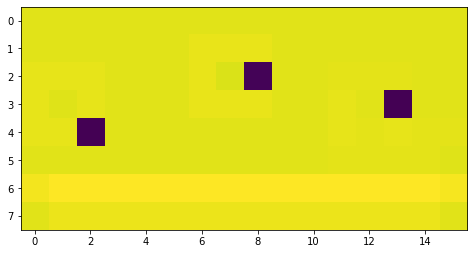

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0912, device='cuda:0')
tensor(0.0547, device='cuda:0')
tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0150, 0.0150, 0.0150,  ..., 0.0150, 0.0150, 0.0000],
         [0.0150, 0.0150, 0.0150,  ..., 0.0150, 0.0150, 0.0150]]],
       device='cuda:0')


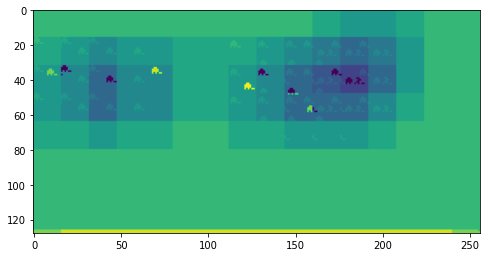

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5002, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


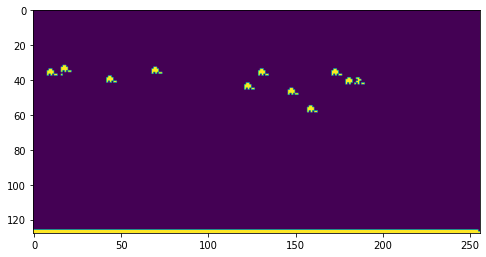

  4%|███▍                                                                               | 1/24 [00:02<00:50,  2.21s/it]

theta_x: 0.0038
theta_y: -0.0007
theta_z: 0.0011
phi: 0.0002
gamma: -0.0004
rho: -0.0000
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0079, device='cuda:0')
tensor(0.0079, device='cuda:0')
tensor([[[ 7.8740,  7.7470,  7.7470,  7.7470,  7.7470,  7.7470,  7.7470,
           7.7470,  7.7470,  7.7470,  7.7470,  7.7470,  7.7470,  7.7470,
           7.2628,  3.3258],
         [11.9381, 13.8431, 13.8431, 13.8113, 13.1604, 12.8271, 14.0415,
          13.8034, 13.4700, 14.2558, 13.8431, 13.8431, 13.8431, 13.8431,
          13.1049,  7.1358],
         [12.1921, 14.2241, 14.2241, 12.1603,  9.4615, -0.0238, -0.1667,
           0.0000,  0.0000,  0.0000, 14.2241, 14.2241, 14.2241, 14.2241,
          13.4621,  7.3660],
         [12.1921, 14.2241, 14.2241, 10.1283,  5.4134,  0.0000,  0.0000,
           7.2628,  9.7076, 11.7793, 14.2241, 14.2241, 14.2241, 14.2241,
          13.4621,  7.3660],
         [12.1921, 14.2241, 14.2241, 10.1600,  6.0960,  4.0640,  6.0960,
           8.1280, 10.1600, 12.192

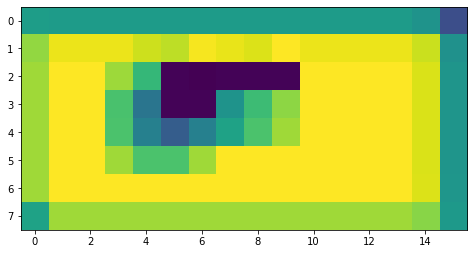

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0825, device='cuda:0')
tensor(0.0578, device='cuda:0')
tensor([[[0.0317, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0317],
         [0.0317, 0.0000, 0.0317,  ..., 0.0317, 0.0000, 0.0000],
         [0.0317, 0.0317, 0.0317,  ..., 0.0317, 0.0000, 0.0000],
         ...,
         [0.0159, 0.0159, 0.0159,  ..., 0.0317, 0.0000, 0.0000],
         [0.0159, 0.0159, 0.0159,  ..., 0.0317, 0.0317, 0.0317],
         [0.0159, 0.0159, 0.0159,  ..., 0.0317, 0.0317, 0.0317]]],
       device='cuda:0')


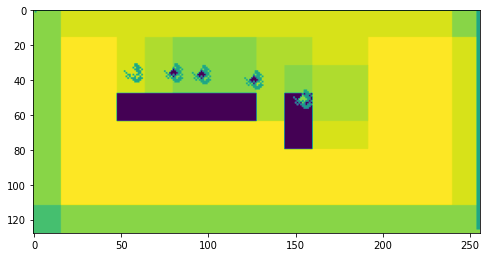

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5002, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


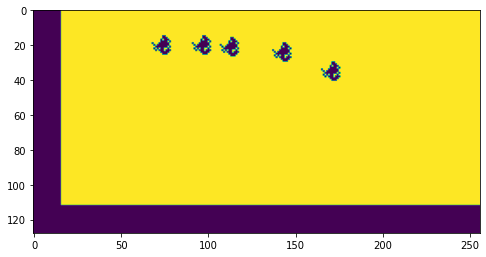

  8%|██████▉                                                                            | 2/24 [00:03<00:42,  1.92s/it]

theta_x: 0.0114
theta_y: 0.0022
theta_z: 0.0018
phi: 0.0005
gamma: -0.0013
rho: -0.0003
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0072, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
          -16.6033, -16.6033, -16.6033, -16.6033,   0.0000, -16.6033, -16.6033,
          -16.6033,   0.0000],
         [  0.0000, -16.6033, -16.6033, -16.6033, -16.6033,   0.0000, -16.6033,
          -16.6033, -16.6033, -16.6033, -16.6033,   0.0000, -16.6033, -16.6033,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000, -16.6033,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000

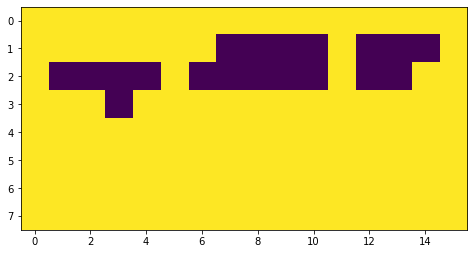

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0470, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


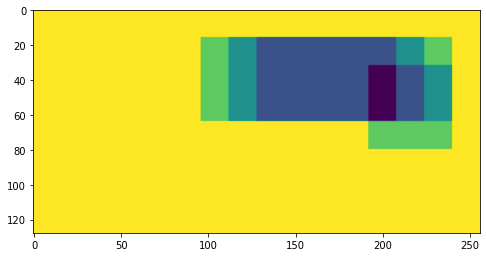

tensor(-0.2499, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(0., device='cuda:0')


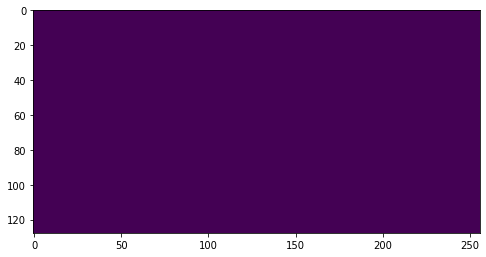

 12%|██████████▍                                                                        | 3/24 [00:04<00:35,  1.70s/it]

theta_x: 0.0114
theta_y: 0.0022
theta_z: 0.0018
phi: 0.0005
gamma: -0.0013
rho: -0.0003
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0081, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000, -18.5724, -18.5724,   0.0000,   0.0000,   0.0000,   0.0000,
          -18.5724, -18.5724,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000, -18.5724,   0.0000,
          -18.5724,   0.0000,   0.0000,   0.0000,   0.0000, -18.5724,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000

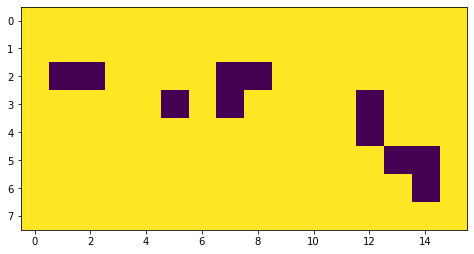

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0477, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


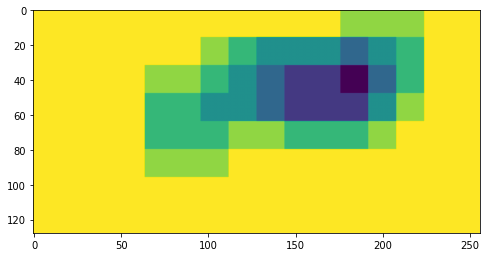

tensor(-0.2499, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(0., device='cuda:0')


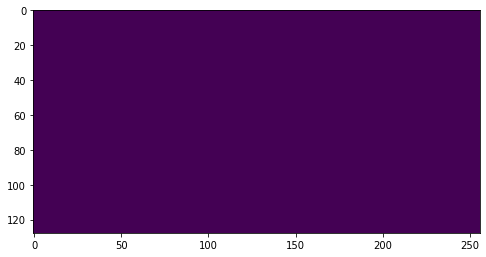

 17%|█████████████▊                                                                     | 4/24 [00:05<00:30,  1.55s/it]

theta_x: 0.0114
theta_y: 0.0022
theta_z: 0.0018
phi: 0.0005
gamma: -0.0013
rho: -0.0003
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0079, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000, -18.2096,   0.0000, -18.2096,   0.0000,   0.0000,   0.0000,
            0.0000, -18.2096, -18.2096, -18.2096, -18.2096,   0.0000,   0.0000,
            0.0000, -18.2096],
         [  0.0000, -18.2096, -18.2096,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000, -18.2096,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000

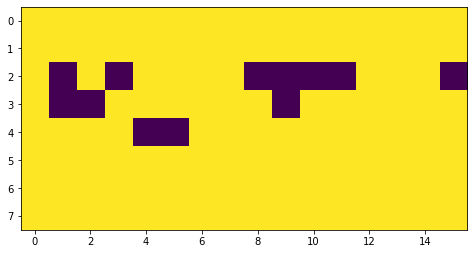

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0540, device='cuda:0')
tensor(0.0224, device='cuda:0')
tensor([[[ 0.0000,  0.0000,  0.0000,  ..., -0.0141, -0.0141, -0.0141],
         [ 0.0000,  0.0000,  0.0000,  ..., -0.0141, -0.0141, -0.0141],
         [ 0.0000,  0.0000,  0.0000,  ..., -0.0141, -0.0141, -0.0141],
         ...,
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]]],
       device='cuda:0')


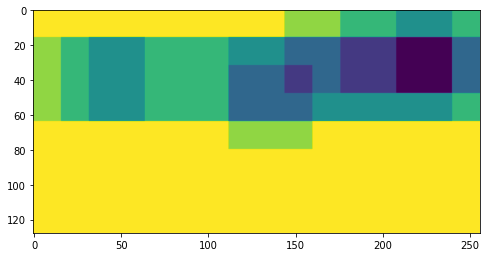

tensor(-0.2500, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5000, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


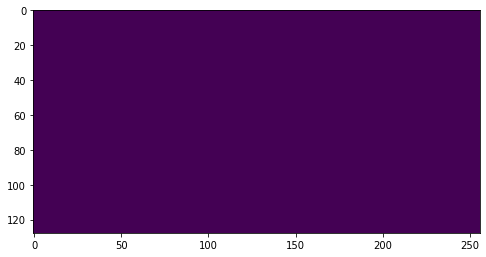

 21%|█████████████████▎                                                                 | 5/24 [00:06<00:26,  1.42s/it]

theta_x: 0.0114
theta_y: 0.0022
theta_z: 0.0018
phi: 0.0005
gamma: -0.0013
rho: -0.0003
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0081, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000, -18.6597],
         [  0.0000,   0.0000,   0.0000,   0.0000, -18.6597, -18.6597,   0.0000,
            0.0000,   0.0000, -18.6597, -18.6597, -18.6597, -18.6597, -18.6597,
          -18.6597, -18.6597],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000

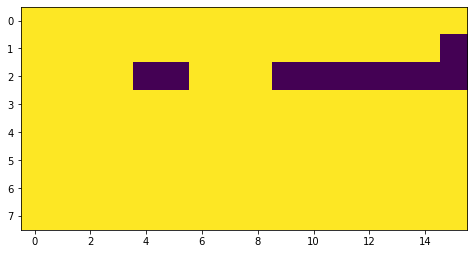

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0491, device='cuda:0')
tensor(0.0228, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


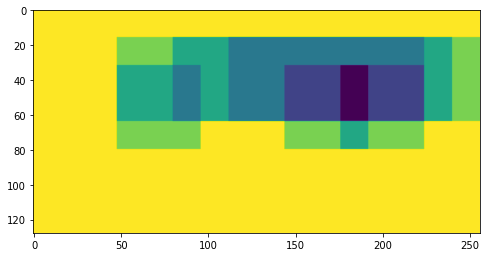

tensor(-0.2500, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5000, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


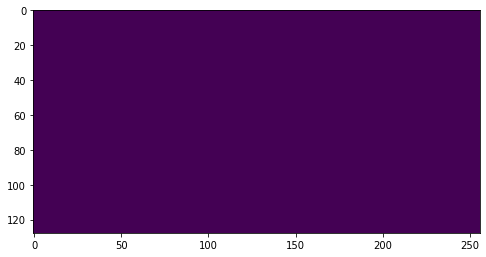

 25%|████████████████████▊                                                              | 6/24 [00:08<00:23,  1.31s/it]

theta_x: 0.0114
theta_y: 0.0022
theta_z: 0.0018
phi: 0.0005
gamma: -0.0013
rho: -0.0003
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0081, device='cuda:0')
tensor(0.0081, device='cuda:0')
tensor([[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  2.4171e-02,
           4.0285e-02,  8.8627e-02,  1.2086e-01,  1.2891e-01,  8.0570e-02,
           2.4171e-02,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 2.4171e-02,  3.2228e-02,  2.4171e-02,  2.4171e-02,  4.0285e-02,
           4.0285e-02, -1.8475e+01, -1.8434e+01, -1.8362e+01, -1.8451e+01,
          -1.8491e+01, -1.8515e+01,  2.4171e-02,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 2.4171e-02,  3.2228e-02,  2.4171e-02, -1.8515e+01,

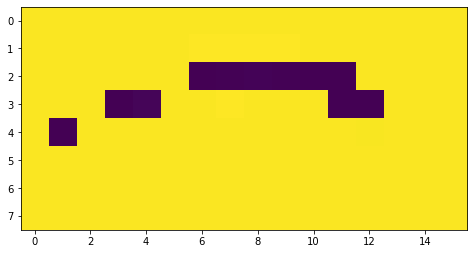

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0830, device='cuda:0')
tensor(0.0575, device='cuda:0')
tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0318, 0.0318, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],
       device='cuda:0')


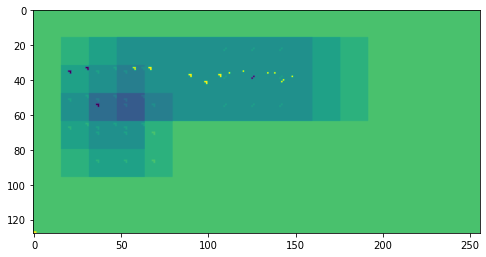

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5002, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


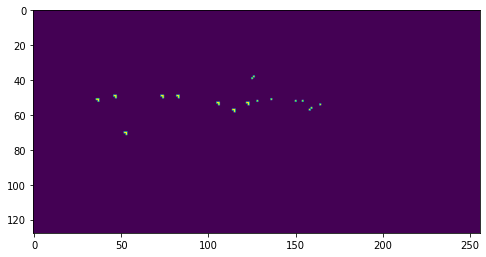

 29%|████████████████████████▏                                                          | 7/24 [00:09<00:20,  1.23s/it]

theta_x: 0.0114
theta_y: 0.0023
theta_z: 0.0018
phi: 0.0005
gamma: -0.0013
rho: -0.0003
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0082, device='cuda:0')
tensor(0.0082, device='cuda:0')
tensor([[[ 2.6139e-01,  2.6139e-01,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 3.9209e-01,  1.3070e-01,  2.2055e-01,  5.5546e-01,  5.7996e-01,
           3.5941e-01,  2.9406e-01,  5.5546e-01,  8.0051e-01,  6.4531e-01,
           3.7575e-01,  3.1040e-01,  2.1238e-01,  1.9604e-01,  1.6337e-02,
           0.0000e+00],
         [ 3.9209e-01,  1.3070e-01,  2.3689e-01,  1.3070e-01, -1.6067e+01,
          -1.8183e+01,  2.9406e-01,  3.8392e-01, -1.6999e+01, -1.6321e+01,
          -1.7154e+01, -1.7726e+01, -1.7342e+01, -1.7922e+01, -1.8281e+01,
           2.6956e-01],
         [ 3.9209e-01,  1.3070e-01,  2.3689e-01,  5.7179e-01,

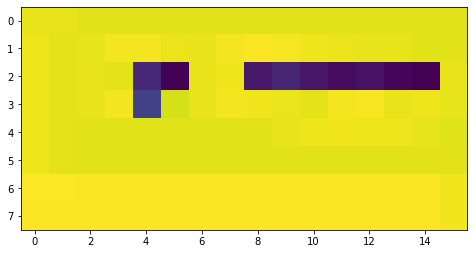

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0884, device='cuda:0')
tensor(0.0590, device='cuda:0')
tensor([[[0.0159, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0159, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0159, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0317, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0317, 0.0317, 0.0317,  ..., 0.0317, 0.0317, 0.0317],
         [0.0317, 0.0317, 0.0317,  ..., 0.0317, 0.0317, 0.0317]]],
       device='cuda:0')


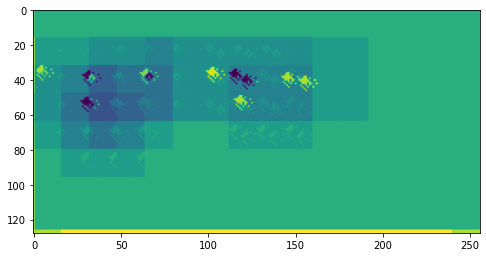

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5003, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


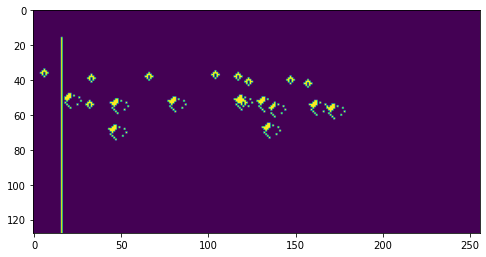

 33%|███████████████████████████▋                                                       | 8/24 [00:10<00:19,  1.19s/it]

theta_x: 0.0196
theta_y: -0.0002
theta_z: 0.0042
phi: 0.0008
gamma: -0.0023
rho: -0.0002
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0078, device='cuda:0')
tensor(0.0078, device='cuda:0')
tensor([[[ 8.0238,  8.0238,  8.0238,  8.0238,  8.0238,  8.0238,  8.0238,
           8.0238,  8.0238,  8.0238,  8.0238,  8.0238,  8.0238,  8.0238,
           8.0238,  4.0119],
         [11.9887, 13.9946, 14.2375, 13.9789, 13.9711, 13.6263, 13.9633,
          13.9241, 13.8379, 14.0886, 14.1983, 14.0416, 14.0416, 14.0416,
          14.0416,  8.0238],
         [11.9808, 13.7831, 13.9476, 11.7693,  9.5047,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000, 14.0416, 14.0416, 14.0416,
          14.0416,  8.0238],
         [ 9.9749, 11.9808,  0.0000,  9.9670,  0.0000,  7.4518,  7.3029,
           7.4204,  7.5066,  9.6693, 11.8790, 14.0416, 14.0416, 14.0416,
          14.0416,  8.0238],
         [10.0219, 12.0278, 10.0219, 10.0297,  8.0238,  8.0238,  8.0238,
           8.0238,  8.0238, 10.029

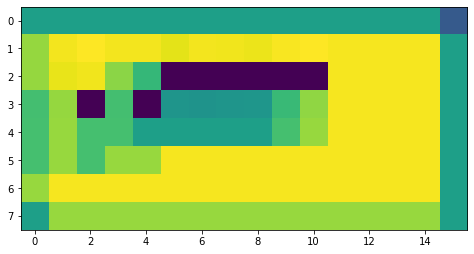

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0814, device='cuda:0')
tensor(0.0570, device='cuda:0')
tensor([[[0.0291, 0.0291, 0.0291,  ..., 0.0291, 0.0291, 0.0291],
         [0.0291, 0.0291, 0.0291,  ..., 0.0291, 0.0291, 0.0291],
         [0.0291, 0.0291, 0.0291,  ..., 0.0291, 0.0291, 0.0291],
         ...,
         [0.0146, 0.0146, 0.0146,  ..., 0.0291, 0.0291, 0.0291],
         [0.0146, 0.0146, 0.0146,  ..., 0.0291, 0.0291, 0.0291],
         [0.0146, 0.0146, 0.0146,  ..., 0.0291, 0.0291, 0.0291]]],
       device='cuda:0')


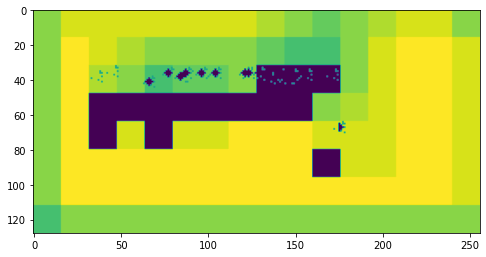

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5003, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


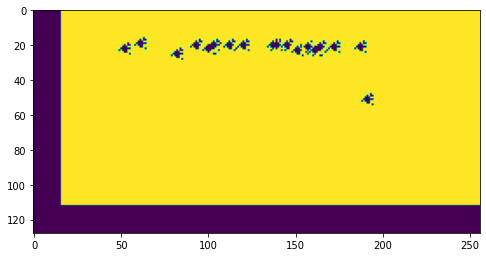

 38%|███████████████████████████████▏                                                   | 9/24 [00:11<00:17,  1.16s/it]

theta_x: 0.0278
theta_y: -0.0005
theta_z: 0.0074
phi: 0.0012
gamma: -0.0035
rho: -0.0001
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0086, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000, -19.7453, -19.7453,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000, -19.7453,   0.0000,   0.0000, -19.7453,
            0.0000, -19.7453, -19.7453,   0.0000, -19.7453,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.000

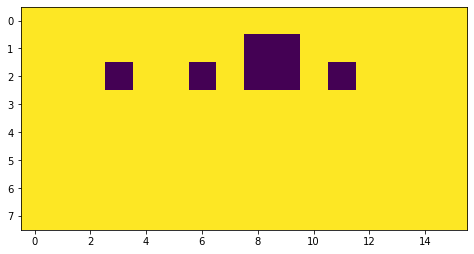

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0489, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


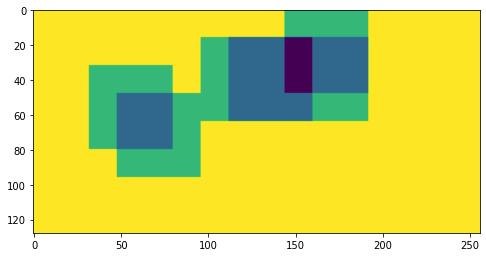

tensor(-0.2500, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(0., device='cuda:0')


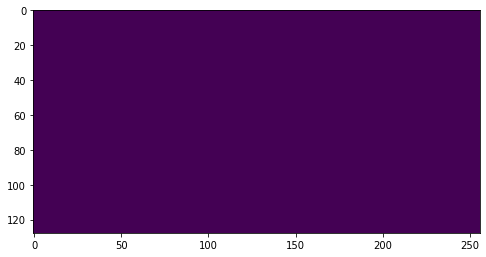

 42%|██████████████████████████████████▏                                               | 10/24 [00:12<00:16,  1.15s/it]

theta_x: 0.0278
theta_y: -0.0005
theta_z: 0.0074
phi: 0.0012
gamma: -0.0035
rho: -0.0001
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0084, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000, -19.4359,   0.0000, -19.4359,
          -19.4359, -19.4359, -19.4359,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000, -19.4359,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000, -19.4359,
          -19.4359,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.000

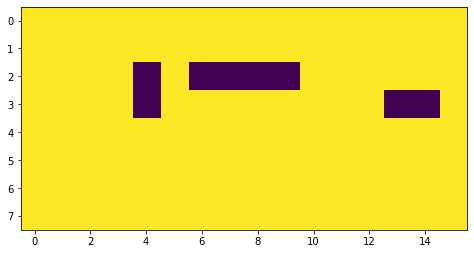

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0444, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


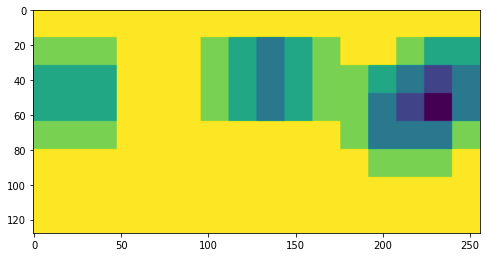

tensor(-0.2500, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(0., device='cuda:0')


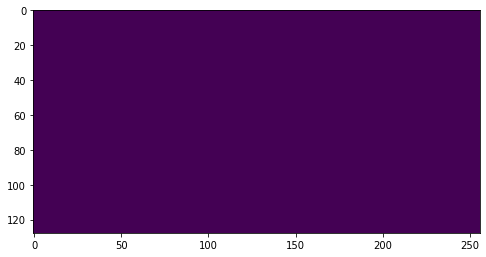

 46%|█████████████████████████████████████▌                                            | 11/24 [00:13<00:14,  1.11s/it]

theta_x: 0.0278
theta_y: -0.0005
theta_z: 0.0074
phi: 0.0012
gamma: -0.0035
rho: -0.0001
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0087, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000, -20.0563, -20.0563, -20.0563, -20.0563, -20.0563,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
          -20.0563,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.000

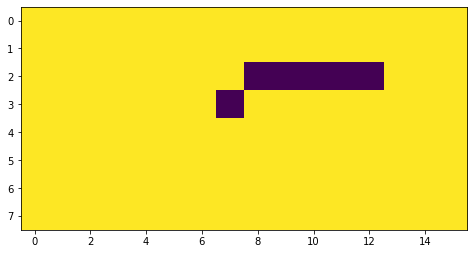

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0548, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[ 0.0000,  0.0000,  0.0000,  ..., -0.0083, -0.0083, -0.0083],
         [ 0.0000,  0.0000,  0.0000,  ..., -0.0083, -0.0083, -0.0083],
         [ 0.0000,  0.0000,  0.0000,  ..., -0.0083, -0.0083, -0.0083],
         ...,
         [ 0.0000,  0.0000,  0.0000,  ..., -0.0083, -0.0083, -0.0083],
         [ 0.0000,  0.0000,  0.0000,  ..., -0.0083, -0.0083, -0.0083],
         [ 0.0000,  0.0000,  0.0000,  ..., -0.0083, -0.0083, -0.0083]]],
       device='cuda:0')


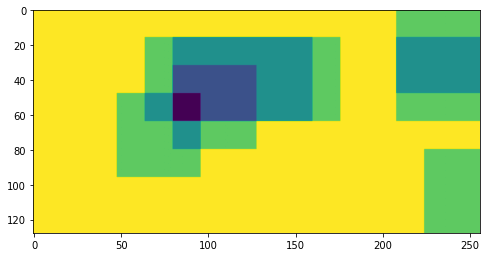

tensor(-0.2500, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(0., device='cuda:0')


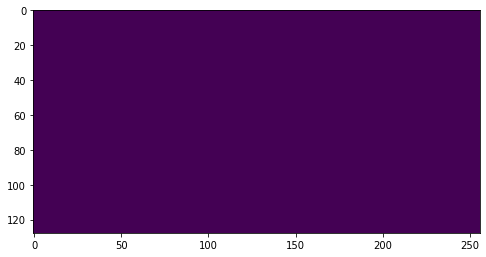

 50%|█████████████████████████████████████████                                         | 12/24 [00:14<00:13,  1.09s/it]

theta_x: 0.0278
theta_y: -0.0005
theta_z: 0.0074
phi: 0.0012
gamma: -0.0035
rho: -0.0001
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0083, device='cuda:0')
tensor(0.0083, device='cuda:0')
tensor([[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           8.3046e-03,  8.3046e-03, -8.3046e-03,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           8.3046e-03, -1.9126e+01, -1.9126e+01, -1.9134e+01, -1.9134e+01,
          -1.9134e+01, -1.9134e+01, -1.9134e+01,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00

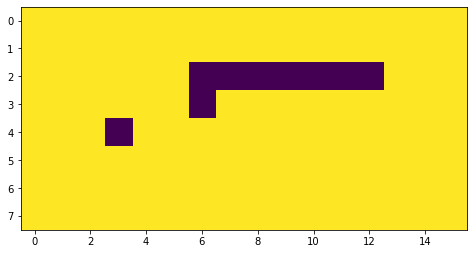

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0806, device='cuda:0')
tensor(0.0343, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


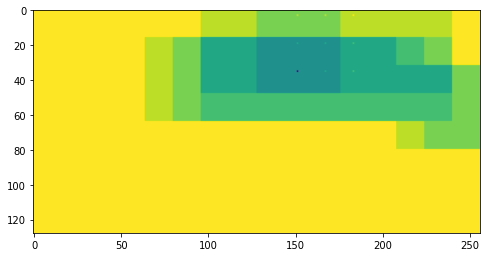

tensor(-0.2500, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5001, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


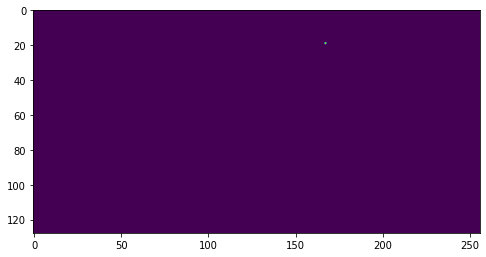

 54%|████████████████████████████████████████████▍                                     | 13/24 [00:15<00:11,  1.07s/it]

theta_x: 0.0278
theta_y: -0.0005
theta_z: 0.0074
phi: 0.0012
gamma: -0.0035
rho: -0.0001
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0081, device='cuda:0')
tensor(0.0081, device='cuda:0')
tensor([[[ 2.4269e-02, -2.4269e-02,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 1.2944e-01,  9.7077e-02, -4.8539e-02,  0.0000e+00,  8.0898e-02,
           1.2944e-01,  1.1326e-01,  3.2359e-02,  5.6629e-02,  1.3753e-01,
           8.0898e-03,  0.0000e+00,  3.2359e-02,  4.8539e-02, -1.6180e-02,
           0.0000e+00],
         [ 4.8539e-02, -1.8218e+01, -1.8558e+01,  0.0000e+00,  8.0898e-02,
           6.4718e-02, -1.8097e+01, -1.8113e+01, -1.8380e+01, -8.0898e-03,
          -1.8501e+01,  0.0000e+00,  4.0449e-02,  5.6629e-02,  1.0517e-01,
          -1.8518e+01],
         [ 1.0517e-01,  1.0517e-01,  4.8539e-02,  0.0000e+00

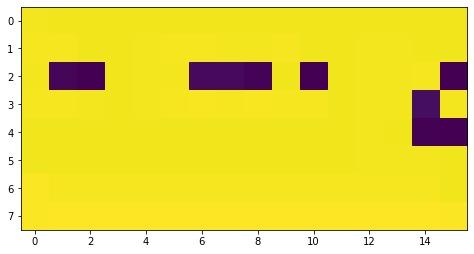

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0856, device='cuda:0')
tensor(0.0513, device='cuda:0')
tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0159, 0.0159, 0.0159,  ..., 0.0317, 0.0000, 0.0000]]],
       device='cuda:0')


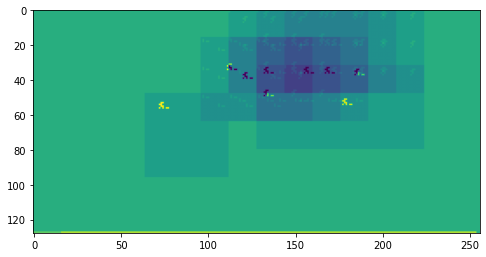

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5002, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


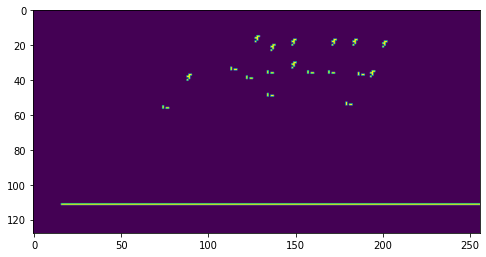

 58%|███████████████████████████████████████████████▊                                  | 14/24 [00:16<00:10,  1.08s/it]

theta_x: 0.0296
theta_y: -0.0014
theta_z: 0.0079
phi: 0.0013
gamma: -0.0037
rho: -0.0001
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0085, device='cuda:0')
tensor(0.0085, device='cuda:0')
tensor([[[ 2.7334e-01,  0.0000e+00,  0.0000e+00,  4.2709e-02,  4.2709e-02,
          -4.2709e-02,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  1.7084e-02,
           1.7084e-02],
         [ 4.1001e-01,  3.7584e-01,  3.0751e-01,  1.7084e-01,  2.0500e-01,
           2.4771e-01,  6.1501e-01,  2.3063e-01,  8.5418e-02, -2.6480e-01,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  1.7084e-02,
           1.7084e-02],
         [ 4.1001e-01,  3.7584e-01,  2.3917e-01, -1.8297e+01, -1.8262e+01,
          -1.8860e+01,  3.9292e-01, -1.7682e+01, -1.8117e+01, -1.9228e+01,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 4.1001e-01,  3.7584e-01,  3.0751e-01,  5.3814e-01

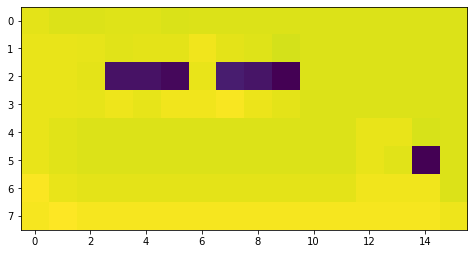

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0897, device='cuda:0')
tensor(0.0554, device='cuda:0')
tensor([[[0.0320, 0.0000, 0.0000,  ..., 0.0000, 0.0320, 0.0320],
         [0.0320, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0320, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0160, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0160, 0.0160, 0.0160,  ..., 0.0320, 0.0320, 0.0320],
         [0.0160, 0.0160, 0.0160,  ..., 0.0320, 0.0320, 0.0320]]],
       device='cuda:0')


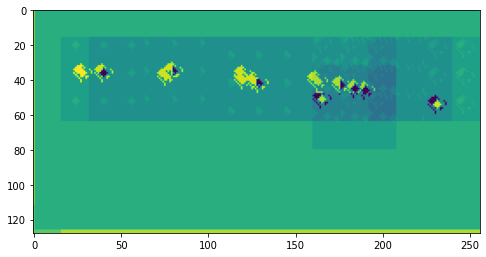

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5003, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


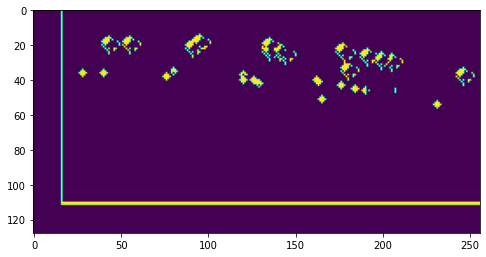

 62%|███████████████████████████████████████████████████▎                              | 15/24 [00:17<00:09,  1.10s/it]

theta_x: 0.0375
theta_y: -0.0012
theta_z: 0.0055
phi: 0.0015
gamma: -0.0045
rho: -0.0001
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0067, device='cuda:0')
tensor(0.0067, device='cuda:0')
tensor([[[ 6.8424e+00,  6.8424e+00,  6.8424e+00,  6.8357e+00,  6.8223e+00,
           6.8357e+00,  6.8557e+00,  6.8424e+00,  6.8424e+00,  6.8424e+00,
           6.8424e+00,  6.8424e+00,  6.8424e+00,  6.8424e+00,  6.8424e+00,
           3.4212e+00],
         [ 1.0016e+01,  1.1807e+01,  1.2001e+01,  1.1847e+01,  1.1520e+01,
           1.1727e+01,  1.1814e+01,  1.1927e+01,  1.1820e+01,  1.2048e+01,
           1.2074e+01,  1.1974e+01,  1.1974e+01,  1.1974e+01,  1.1974e+01,
           6.8424e+00],
         [ 8.1855e+00, -1.0691e-01,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00, -3.3410e-02, -6.6820e-03, -6.6820e-03, -4.6774e-02,
          -2.6728e-02,  1.2008e+01,  1.1981e+01,  1.1974e+01,  1.1974e+01,
           6.8424e+00],
         [ 6.6553e+00, -1.6705e-01, -2.6728e-02,  0.0000e+00

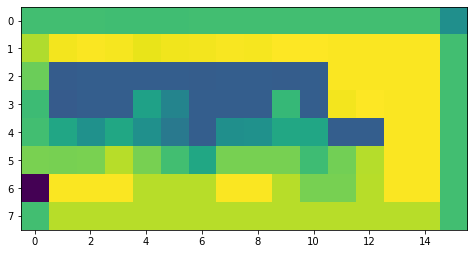

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0800, device='cuda:0')
tensor(0.0560, device='cuda:0')
tensor([[[0.0317, 0.0317, 0.0317,  ..., 0.0317, 0.0317, 0.0317],
         [0.0317, 0.0317, 0.0317,  ..., 0.0317, 0.0317, 0.0317],
         [0.0317, 0.0317, 0.0317,  ..., 0.0317, 0.0317, 0.0317],
         ...,
         [0.0159, 0.0159, 0.0159,  ..., 0.0317, 0.0317, 0.0317],
         [0.0159, 0.0159, 0.0159,  ..., 0.0317, 0.0317, 0.0317],
         [0.0159, 0.0159, 0.0159,  ..., 0.0317, 0.0317, 0.0317]]],
       device='cuda:0')


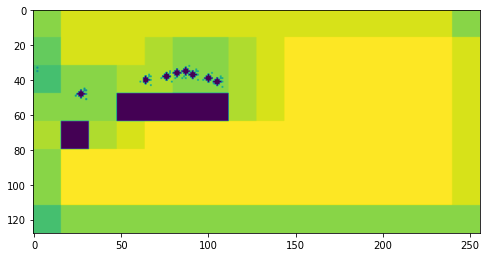

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5003, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


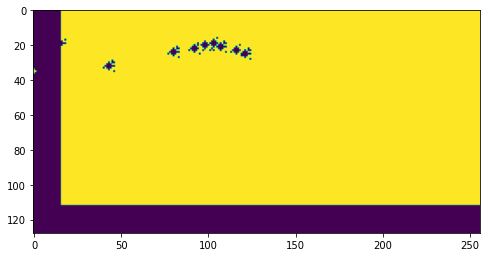

 67%|██████████████████████████████████████████████████████▋                           | 16/24 [00:18<00:08,  1.08s/it]

theta_x: 0.0490
theta_y: -0.0022
theta_z: 0.0065
phi: 0.0019
gamma: -0.0055
rho: -0.0001
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0090, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000, -20.7234,
            0.0000, -20.7234, -20.7234,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000, -20.7234,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.000

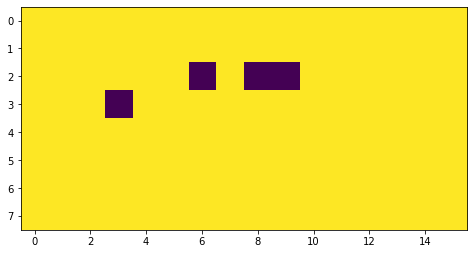

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0552, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


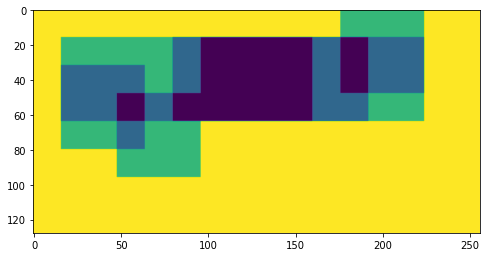

tensor(-0.2499, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(0., device='cuda:0')


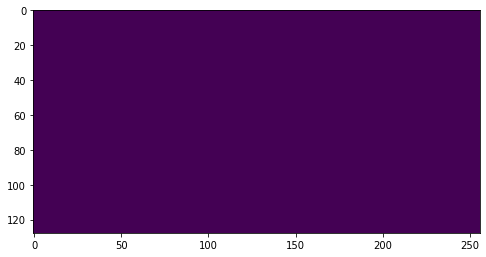

 71%|██████████████████████████████████████████████████████████                        | 17/24 [00:19<00:07,  1.06s/it]

theta_x: 0.0490
theta_y: -0.0022
theta_z: 0.0065
phi: 0.0019
gamma: -0.0055
rho: -0.0001
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0088, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
          -20.3831, -20.3831, -20.3831,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000, -20.3831, -20.3831,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.000

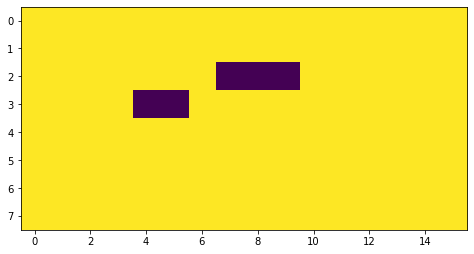

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0463, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


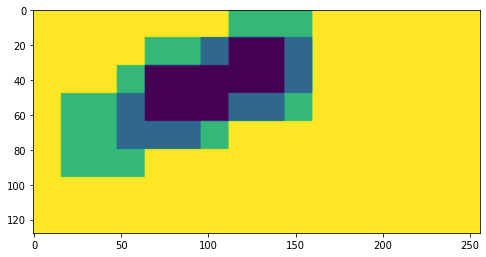

tensor(-0.2500, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(0., device='cuda:0')


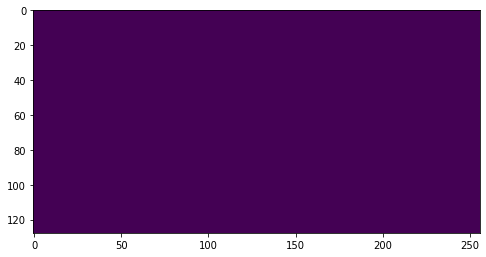

 75%|█████████████████████████████████████████████████████████████▌                    | 18/24 [00:20<00:06,  1.06s/it]

theta_x: 0.0490
theta_y: -0.0022
theta_z: 0.0065
phi: 0.0019
gamma: -0.0055
rho: -0.0001
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0073, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000, -16.7384,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000, -16.7457, -16.7457, -16.7457, -16.7457, -16.7457, -16.7457,
          -16.7457, -16.7457, -16.7384, -16.6803, -16.7384, -16.7457, -16.7457,
          -16.7457, -16.7457],
         [  0.0000,   0.0000, -16.7457,   0.0000, -16.7457,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.000

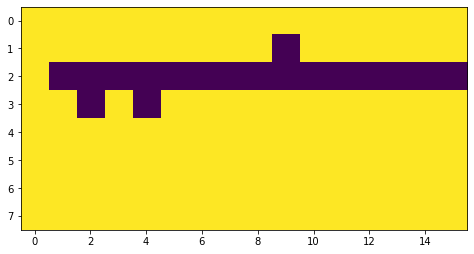

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0899, device='cuda:0')
tensor(0.0435, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


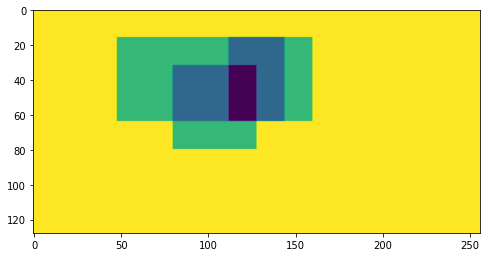

tensor(-0.2500, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5001, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


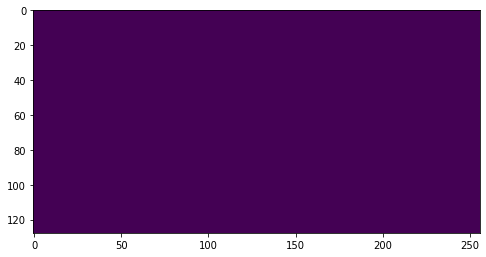

 79%|████████████████████████████████████████████████████████████████▉                 | 19/24 [00:21<00:05,  1.08s/it]

theta_x: 0.0490
theta_y: -0.0022
theta_z: 0.0065
phi: 0.0019
gamma: -0.0055
rho: -0.0001
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0087, device='cuda:0')
tensor(0.0087, device='cuda:0')
tensor([[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 6.9615e-02,  6.9615e-02,  0.0000e+00,  1.1312e-01,  1.1312e-01,
          -3.4807e-02,  1.5663e-01,  1.3923e-01, -1.4793e-01,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 6.9615e-02,  0.0000e+00, -1.9979e+01,  1.1312e-01,  4.3509e-02,
          -1.9553e+01, -1.9701e+01, -1.8839e+01, -1.9727e+01,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 6.9615e-02,  6.9615e-02,  6.9615e-02,  1.1312e-01

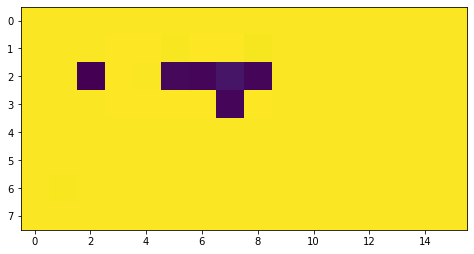

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0899, device='cuda:0')
tensor(0.0629, device='cuda:0')
tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0156, 0.0156, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],
       device='cuda:0')


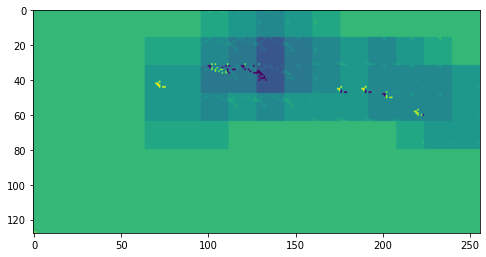

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5002, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


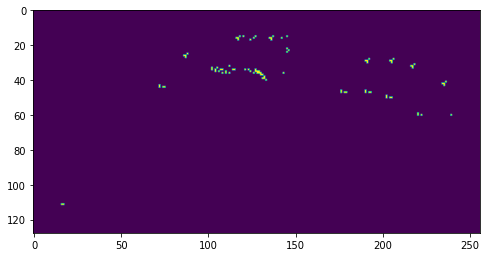

 83%|████████████████████████████████████████████████████████████████████▎             | 20/24 [00:22<00:04,  1.06s/it]

theta_x: 0.0521
theta_y: -0.0020
theta_z: 0.0064
phi: 0.0020
gamma: -0.0058
rho: -0.0002
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0087, device='cuda:0')
tensor(0.0087, device='cuda:0')
tensor([[[ 2.7782e-01,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 4.1674e-01,  2.8651e-01,  1.7364e-01, -3.4728e-02,  4.3410e-02,
           3.0387e-01,  3.6464e-01,  9.5502e-02,  1.7364e-01, -8.6820e-03,
          -1.3891e-01, -1.7364e-02,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 4.1674e-01,  3.2992e-01,  2.1705e-01,  1.1287e-01,  6.0774e-02,
           3.0387e-01, -1.7468e+01, -1.8093e+01, -1.8258e+01, -1.8588e+01,
          -1.9647e+01,  1.7364e-02,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 4.1674e-01,  3.2992e-01,  1.8232e-01, -1.9300e+01

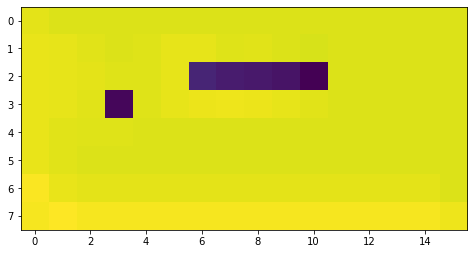

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0897, device='cuda:0')
tensor(0.0628, device='cuda:0')
tensor([[[0.0326, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0326, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0326, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0163, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0163, 0.0163, 0.0163,  ..., 0.0326, 0.0326, 0.0326],
         [0.0163, 0.0163, 0.0163,  ..., 0.0326, 0.0326, 0.0326]]],
       device='cuda:0')


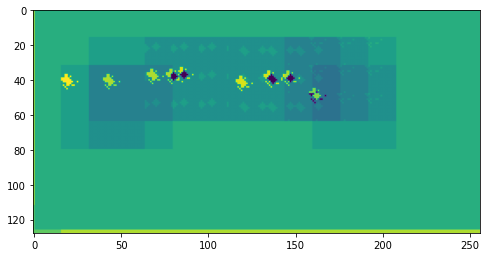

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5002, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


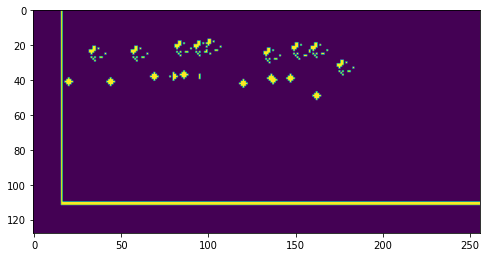

 88%|███████████████████████████████████████████████████████████████████████▊          | 21/24 [00:23<00:03,  1.06s/it]

theta_x: 0.0593
theta_y: 0.0023
theta_z: 0.0066
phi: 0.0023
gamma: -0.0067
rho: -0.0005
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0076, device='cuda:0')
tensor(0.0076, device='cuda:0')
tensor([[[ 7.7901, 11.6851, 11.6851, 11.6851, 11.6851, 11.6851,  9.7376,
           7.7901,  5.8426,  5.8426,  5.8426,  7.7901,  9.7376, 11.6851,
          11.6851,  7.7901],
         [11.6851, 13.6327, 13.6327, 13.6327, 13.6327, 11.6927,  9.6692,
           7.6836,  7.4934,  5.6220, -0.1522,  7.6912, 11.5862, 11.6851,
          11.6851,  5.8426],
         [11.6851, 13.6327, 13.6327, 13.6327, 13.6327, 11.6547,  9.5779,
           7.1967,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000, 11.6319,
          11.6319,  5.7893],
         [11.6851, 13.6327, 13.6327, 13.6327, 13.6327, 11.6547, 11.4645,
           0.0000, 13.8152, 11.4797, 11.3884, -0.0685, 13.6707, 11.6319,
          11.4341,  0.0000],
         [11.6851,  5.8426,  5.8426,  5.8426,  5.8426,  5.8045,  5.7513,
           5.8882,  5.8958,  5.7817

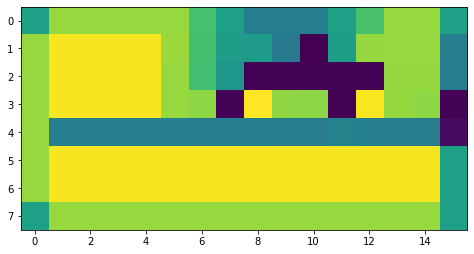

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0794, device='cuda:0')
tensor(0.0556, device='cuda:0')
tensor([[[0.0149, 0.0149, 0.0149,  ..., 0.0298, 0.0298, 0.0298],
         [0.0149, 0.0149, 0.0149,  ..., 0.0298, 0.0298, 0.0298],
         [0.0149, 0.0149, 0.0149,  ..., 0.0298, 0.0298, 0.0298],
         ...,
         [0.0149, 0.0149, 0.0149,  ..., 0.0298, 0.0298, 0.0298],
         [0.0149, 0.0149, 0.0149,  ..., 0.0298, 0.0298, 0.0298],
         [0.0149, 0.0149, 0.0149,  ..., 0.0298, 0.0298, 0.0298]]],
       device='cuda:0')


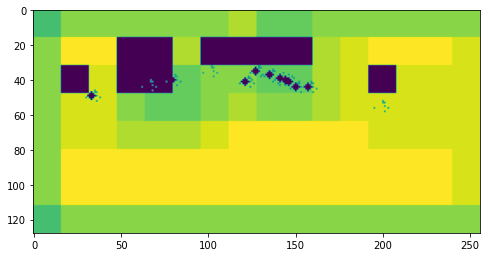

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5003, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


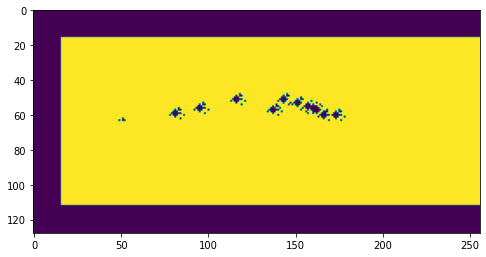

 92%|███████████████████████████████████████████████████████████████████████████▏      | 22/24 [00:25<00:02,  1.10s/it]

theta_x: 0.0669
theta_y: 0.0017
theta_z: 0.0063
phi: 0.0026
gamma: -0.0075
rho: -0.0005
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0074, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000, -16.9760,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000, -16.9760, -16.9760,
          -16.9760,   0.0000, -16.9760, -16.9760, -16.9760, -16.9760, -16.9760,
          -16.9760, -16.9760],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000, -16.9760,   0.0000,
            0.0000,   0.0000,   0.0000, -16.9760, -16.9760, -16.9760,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000

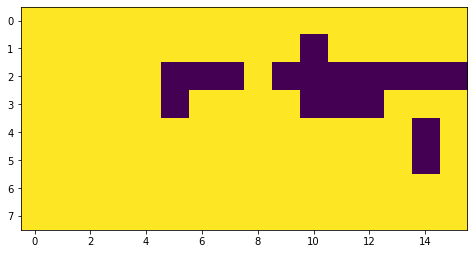

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0557, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


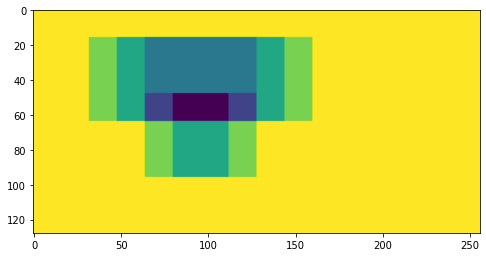

tensor(-0.2499, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(0., device='cuda:0')


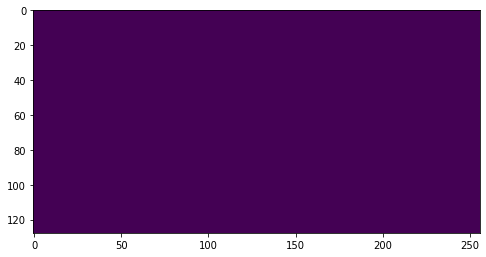

 96%|██████████████████████████████████████████████████████████████████████████████▌   | 23/24 [00:26<00:01,  1.09s/it]

theta_x: 0.0669
theta_y: 0.0017
theta_z: 0.0063
phi: 0.0026
gamma: -0.0075
rho: -0.0005
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0074, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000, -16.9744, -16.9744,   0.0000,   0.0000,   0.0000, -16.9744,
          -16.9744,   0.0000],
         [  0.0000, -16.9744,   0.0000,   0.0000, -16.9744, -16.9744,   0.0000,
            0.0000, -16.9744, -16.9744, -16.9744, -16.9744, -16.9744, -16.9744,
          -16.9744, -16.9744],
         [  0.0000,   0.0000,   0.0000, -16.9744,   0.0000, -16.9744,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000

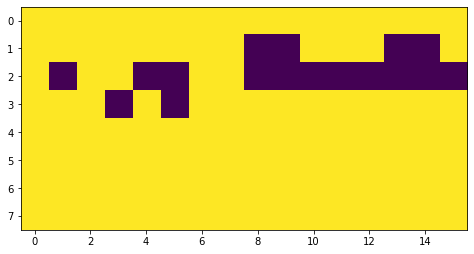

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0477, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[ 0.0000,  0.0000,  0.0000,  ..., -0.0071, -0.0071, -0.0071],
         [ 0.0000,  0.0000,  0.0000,  ..., -0.0071, -0.0071, -0.0071],
         [ 0.0000,  0.0000,  0.0000,  ..., -0.0071, -0.0071, -0.0071],
         ...,
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]]],
       device='cuda:0')


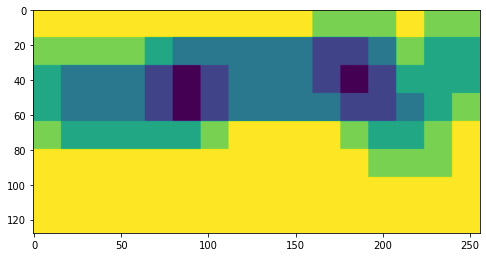

tensor(-0.2500, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(0., device='cuda:0')


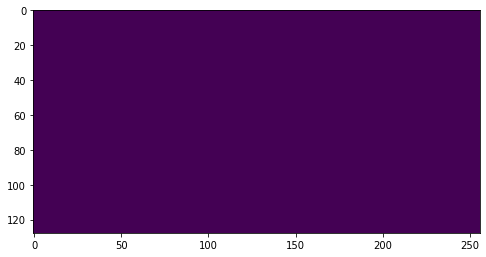

100%|██████████████████████████████████████████████████████████████████████████████████| 24/24 [00:27<00:00,  1.14s/it]

theta_x: 0.0669
theta_y: 0.0017
theta_z: 0.0063
phi: 0.0026
gamma: -0.0075
rho: -0.0005
Train Epoch: (4, 0) 	LR: 0.001000	Loss: 28.845109



  0%|                                                                                           | 0/24 [00:00<?, ?it/s]

in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0086, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
          -19.7379,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000, -19.7379, -19.7379, -19.7379,
          -19.7379, -19.7379,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000, -19.7379,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.00

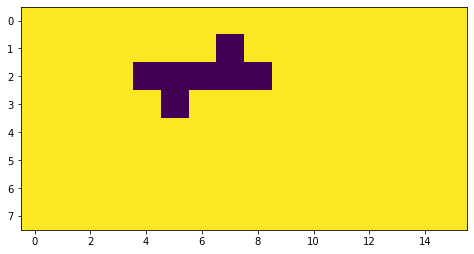

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0818, device='cuda:0')
tensor(0.0405, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


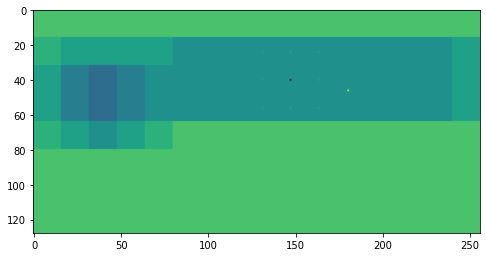

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5001, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


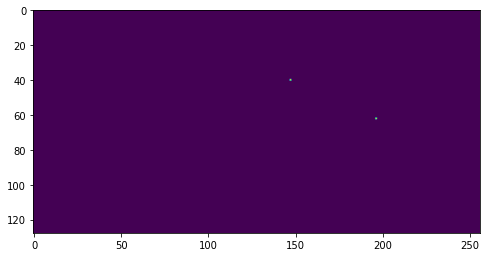

  4%|███▍                                                                               | 1/24 [00:01<00:24,  1.06s/it]

theta_x: 0.0669
theta_y: 0.0017
theta_z: 0.0063
phi: 0.0026
gamma: -0.0075
rho: -0.0005
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0090, device='cuda:0')
tensor(0.0090, device='cuda:0')
tensor([[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 0.0000e+00,  1.7981e-02,  1.7981e-02,  6.2933e-02,  4.4952e-02,
           4.4952e-02,  0.0000e+00,  8.0914e-02,  8.0914e-02, -2.0633e+01,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 0.0000e+00,  1.7981e-02, -1.7981e-02,  6.2933e-02,  8.9905e-03,
          -2.0669e+01,  0.0000e+00,  8.0914e-02,  2.6971e-02, -2.0633e+01,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 0.0000e+00,  1.7981e-02,  1.7981e-02, -2.0408e+01,

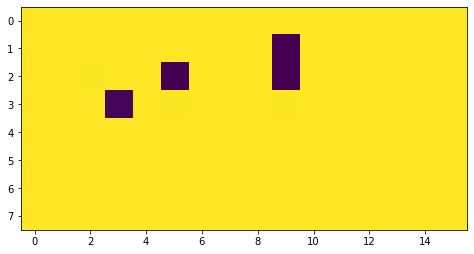

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0899, device='cuda:0')
tensor(0.0578, device='cuda:0')
tensor([[[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         ...,
         [ 0.0000,  0.0000,  0.0000,  ..., -0.0068, -0.0068, -0.0068],
         [ 0.0000,  0.0000,  0.0000,  ..., -0.0068, -0.0068, -0.0068],
         [ 0.0000,  0.0000,  0.0000,  ..., -0.0068, -0.0068, -0.0068]]],
       device='cuda:0')


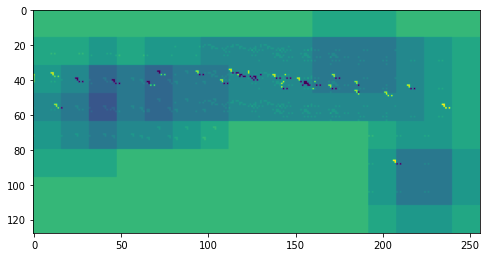

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5002, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


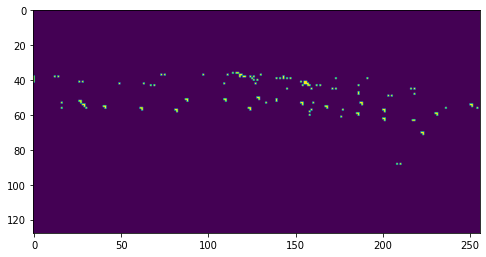

theta_x: 0.0680


  8%|██████▉                                                                            | 2/24 [00:02<00:24,  1.10s/it]

theta_y: 0.0021
theta_z: 0.0063
phi: 0.0026
gamma: -0.0076
rho: -0.0005
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0069, device='cuda:0')
tensor(0.0069, device='cuda:0')
tensor([[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  6.8954e-03,  6.8954e-03,
           6.8954e-03,  6.8954e-03,  6.8954e-03,  6.8954e-03,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 9.6536e-02,  1.5860e-01,  8.9641e-02,  7.5850e-02,  6.2059e-02,
          -1.5177e+01,  1.3791e-01,  2.6892e-01, -1.4646e+01, -1.4873e+01,
          -1.5301e+01, -1.5777e+01,  4.8268e-02,  8.2745e-02,  8.9641e-02,
           4.1373e-02],
         [ 1.1033e-01,  1.1722e-01,  8.2745e-02, -1.4942e+01, -1.5232e+01,
          -1.3570e+01, -1.4425e+01, -1.3605e+01, -1.2474e+01, -1.3046e+01,
          -1.4501e+01, -1.5398e+01,  3.7235e-01, -1.5053e+01, -1.5453e+01,
          -1.5673e+01],
         [ 1.1033e-01, -1.5384e+01,  9.6536e-02, -4.1373e-02,  6.2059e-02,
  

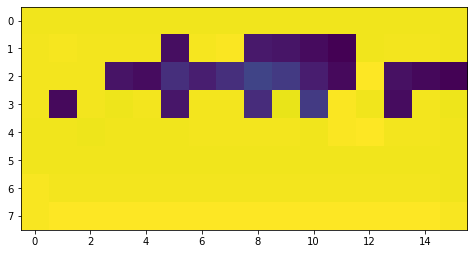

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0898, device='cuda:0')
tensor(0.0539, device='cuda:0')
tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0180, 0.0000, 0.0000,  ..., 0.0000, 0.0359, 0.0000],
         [0.0180, 0.0180, 0.0180,  ..., 0.0359, 0.0359, 0.0359]]],
       device='cuda:0')


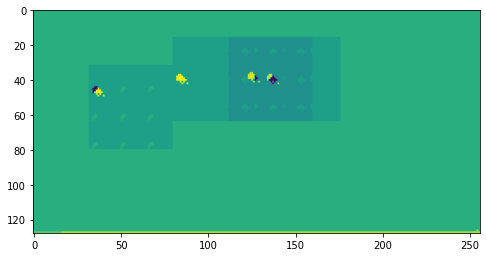

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5003, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


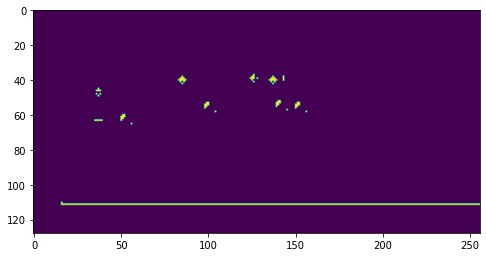

 12%|██████████▍                                                                        | 3/24 [00:03<00:23,  1.10s/it]

theta_x: 0.0754
theta_y: 0.0013
theta_z: 0.0059
phi: 0.0029
gamma: -0.0084
rho: -0.0006
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0079, device='cuda:0')
tensor(0.0079, device='cuda:0')
tensor([[[ 8.0851e+00,  1.2136e+01,  1.2151e+01,  1.2151e+01,  1.2151e+01,
           1.2151e+01,  1.0126e+01,  8.1009e+00,  6.0757e+00,  8.1009e+00,
           1.0126e+01,  1.2151e+01,  1.2151e+01,  1.2151e+01,  1.2151e+01,
           8.1009e+00],
         [ 1.2136e+01,  1.4192e+01,  1.4177e+01,  1.4177e+01,  1.4177e+01,
           1.4177e+01,  1.0134e+01,  6.0836e+00,  2.0331e+00, -8.1484e-01,
          -4.0347e-01,  1.4177e+01,  1.4177e+01,  1.4177e+01,  1.4177e+01,
           8.1009e+00],
         [ 1.2151e+01,  6.0757e+00,  6.0757e+00,  6.0757e+00,  6.0757e+00,
           6.0757e+00,  7.9111e-03, -6.0836e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  6.0757e+00,  6.0757e+00,  6.0757e+00,  5.9729e+00,
          -1.0284e-01],
         [ 1.2151e+01,  1.4177e+01,  1.4177e+01,  1.4177e+01,

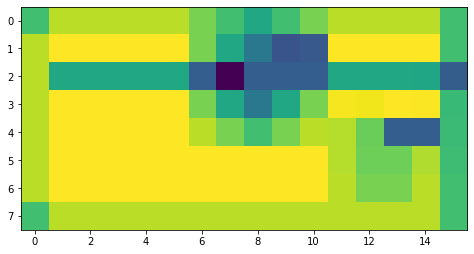

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0823, device='cuda:0')
tensor(0.0576, device='cuda:0')
tensor([[[0.0151, 0.0000, 0.0151,  ..., 0.0302, 0.0302, 0.0302],
         [0.0151, 0.0000, 0.0151,  ..., 0.0302, 0.0302, 0.0302],
         [0.0151, 0.0151, 0.0151,  ..., 0.0302, 0.0302, 0.0302],
         ...,
         [0.0151, 0.0151, 0.0151,  ..., 0.0226, 0.0226, 0.0226],
         [0.0151, 0.0151, 0.0151,  ..., 0.0226, 0.0226, 0.0226],
         [0.0151, 0.0151, 0.0151,  ..., 0.0226, 0.0226, 0.0226]]],
       device='cuda:0')


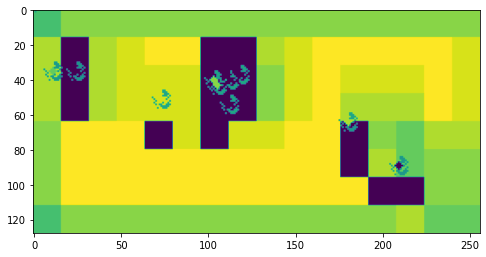

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5003, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


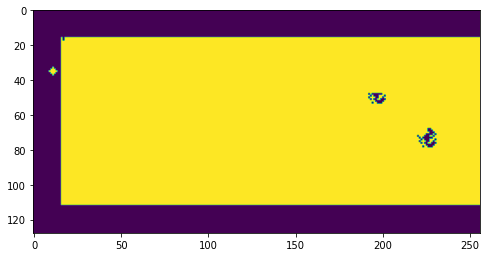

 17%|█████████████▊                                                                     | 4/24 [00:04<00:21,  1.09s/it]

theta_x: 0.0841
theta_y: 0.0018
theta_z: 0.0061
phi: 0.0033
gamma: -0.0092
rho: -0.0007
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0088, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000, -20.3835,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000, -20.3835, -20.3835,   0.0000,   0.0000,   0.0000,
          -20.3835,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000, -20.3835,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000

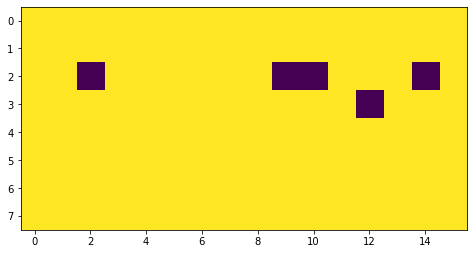

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0484, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


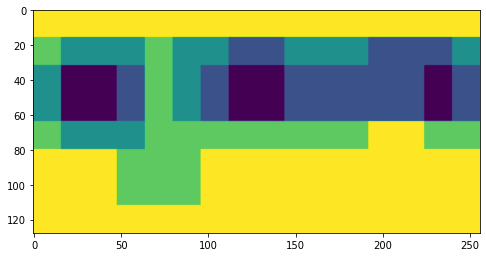

tensor(-0.2500, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(0., device='cuda:0')


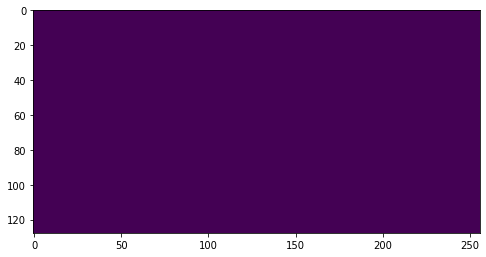

 21%|█████████████████▎                                                                 | 5/24 [00:05<00:20,  1.10s/it]

theta_x: 0.0841
theta_y: 0.0018
theta_z: 0.0061
phi: 0.0033
gamma: -0.0092
rho: -0.0007
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0073, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000, -16.8208, -16.8208, -16.8062, -16.8062, -16.8062,
          -16.8208, -16.8208, -16.8208, -16.8208,   0.0000, -16.8208, -16.8208,
            0.0000,   0.0000],
         [  0.0000,   0.0000, -16.8208, -16.8208, -16.8062, -16.8062, -16.6894,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000

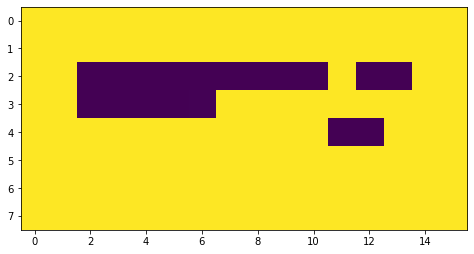

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0870, device='cuda:0')
tensor(0.0386, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


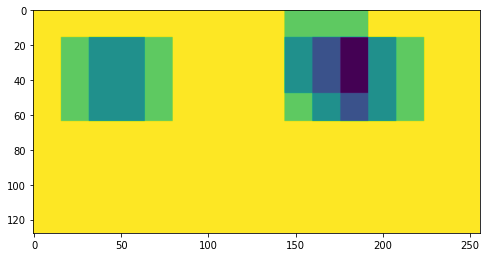

tensor(-0.2500, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5001, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


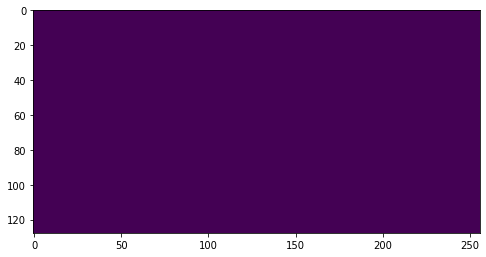

 25%|████████████████████▊                                                              | 6/24 [00:06<00:20,  1.17s/it]

theta_x: 0.0841
theta_y: 0.0018
theta_z: 0.0061
phi: 0.0033
gamma: -0.0092
rho: -0.0007
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0075, device='cuda:0')
tensor(0.0075, device='cuda:0')
tensor([[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 4.5218e-02,  6.7826e-02,  6.0290e-02,  6.7826e-02,  9.7972e-02,
           8.2899e-02,  8.2899e-02,  3.0145e-02,  2.2609e-02,  0.0000e+00,
           7.5363e-03,  9.0435e-02,  1.1304e-01,  1.2058e-01,  3.7681e-02,
           1.5073e-02],
         [ 9.0435e-02,  6.7826e-02,  1.5073e-02,  2.2609e-02,  5.2754e-02,
          -1.6746e+01, -1.6806e+01, -1.6565e+01, -1.7258e+01,  0.0000e+00,
           7.5363e-03,  9.0435e-02,  2.2609e-02, -1.7070e+01, -1.7168e+01,
          -1.7273e+01],
         [ 4.5218e-02, -1.7183e+01, -1.7040e+01, -1.7009e+01,

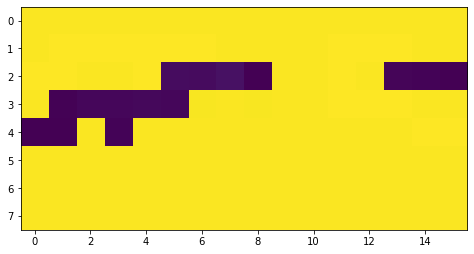

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0884, device='cuda:0')
tensor(0.0531, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


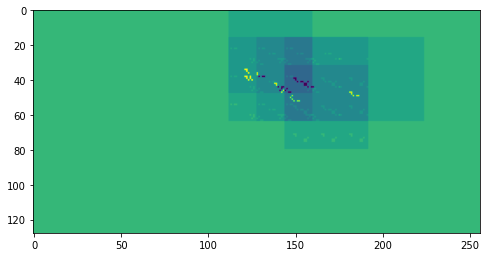

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5001, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


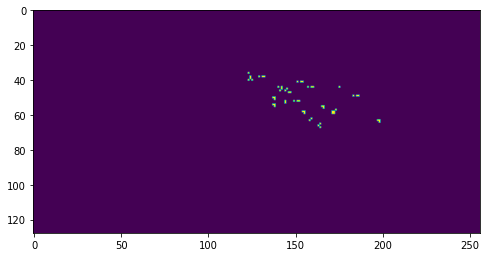

 29%|████████████████████████▏                                                          | 7/24 [00:08<00:20,  1.20s/it]

theta_x: 0.0856
theta_y: 0.0022
theta_z: 0.0062
phi: 0.0034
gamma: -0.0094
rho: -0.0007
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0086, device='cuda:0')
tensor(0.0086, device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.1882,   0.1882,   0.1882,   0.4191,   0.4362,   1.0435,
            0.7270, -18.7749, -19.2026,   0.1882,   0.1882,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.1882,  -0.0342, -19.5191,   0.4191,  -0.0428, -17.9965,
            0.0257, -17.0728, -19.2026,  -0.0342, -19.5191,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.1882,   0.1882,   0.0342,   0.4191,   0.4362,   0.6843,
            0.6928,   0.1967,   0.0855,   0.1882,   0.0342,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.

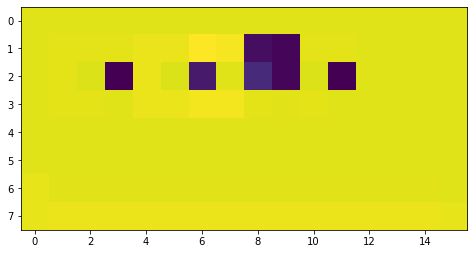

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0869, device='cuda:0')
tensor(0.0522, device='cuda:0')
tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0166, 0.0000, 0.0000,  ..., 0.0000, 0.0332, 0.0000],
         [0.0166, 0.0166, 0.0166,  ..., 0.0332, 0.0332, 0.0000]]],
       device='cuda:0')


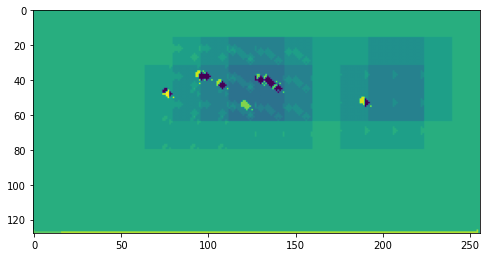

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5003, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


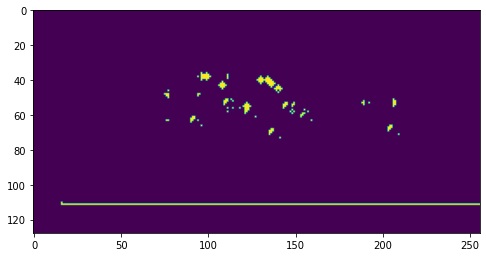

theta_x: 0.0893


 33%|███████████████████████████▋                                                       | 8/24 [00:09<00:19,  1.21s/it]

theta_y: -0.0022
theta_z: 0.0079
phi: 0.0036
gamma: -0.0101
rho: -0.0007
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0074, device='cuda:0')
tensor(0.0074, device='cuda:0')
tensor([[[ 7.5436,  7.5288,  7.4920,  7.4773,  7.4331,  7.4846,  7.6467,
           7.5436,  7.5436,  7.5436,  7.5436,  7.5436,  7.5436,  7.5436,
           7.5436,  3.7718],
         [11.3080, 12.8550, 12.4498, 12.9876, 12.5161, 12.9213, 13.3338,
          12.7592, 11.8016,  9.6357, -0.4052, -0.2210, 13.2012, 13.2012,
          13.2012,  7.5436],
         [11.3080, 10.9691,  8.3392,  0.0000,  0.0000,  0.0000,  0.0000,
           8.5160, -0.1031,  0.0000,  0.0000,  0.0000, 13.2012, 13.2012,
          13.2012,  7.5436],
         [11.2491,  9.0390,  6.8879,  0.0000,  6.2765,  8.5307,  6.7774,
           7.0721,  0.0000,  3.5655,  5.6577,  9.4295, 13.2012, 13.2012,
          13.2012,  7.5436],
         [11.0943,  9.2085,  7.8382,  5.6577,  7.5436,  9.4295,  7.5436,
           7.5436,  5.6577,  7.5436,  9.4295, 11.3

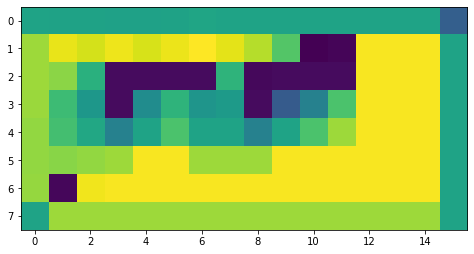

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0811, device='cuda:0')
tensor(0.0568, device='cuda:0')
tensor([[[0.0281, 0.0281, 0.0281,  ..., 0.0281, 0.0281, 0.0281],
         [0.0281, 0.0281, 0.0281,  ..., 0.0281, 0.0281, 0.0281],
         [0.0281, 0.0281, 0.0281,  ..., 0.0281, 0.0281, 0.0281],
         ...,
         [0.0141, 0.0141, 0.0141,  ..., 0.0281, 0.0281, 0.0281],
         [0.0141, 0.0141, 0.0141,  ..., 0.0281, 0.0281, 0.0281],
         [0.0141, 0.0141, 0.0141,  ..., 0.0281, 0.0281, 0.0281]]],
       device='cuda:0')


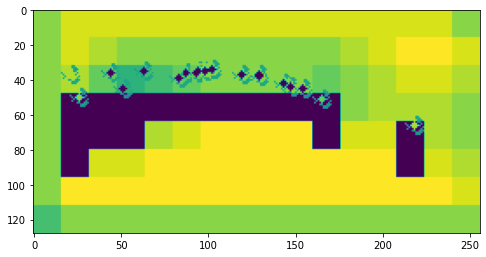

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5003, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


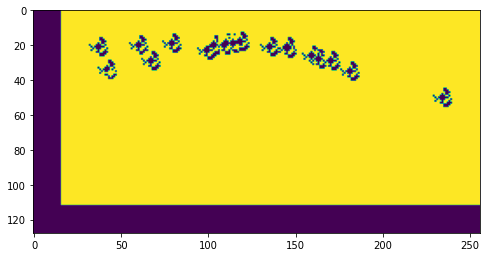

 38%|███████████████████████████████▏                                                   | 9/24 [00:10<00:17,  1.19s/it]

theta_x: 0.0965
theta_y: 0.0019
theta_z: 0.0072
phi: 0.0039
gamma: -0.0108
rho: -0.0008
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0081, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000, -18.6633],
         [  0.0000,   0.0000,   0.0000,   0.0000, -18.6633, -18.6633,   0.0000,
            0.0000,   0.0000, -18.6633, -18.6633, -18.6633, -18.6633, -18.6633,
          -18.6633, -18.6633],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000

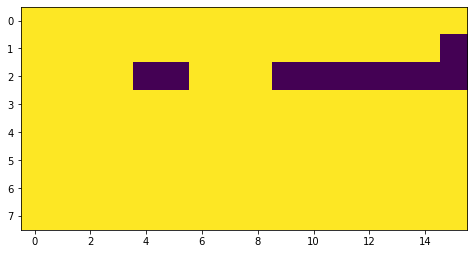

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0556, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


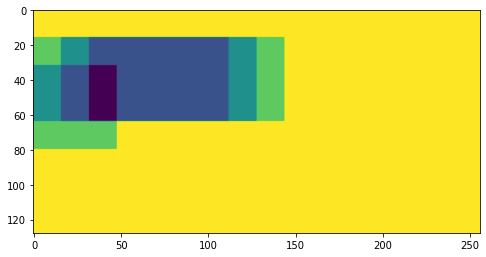

tensor(-0.2500, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(0., device='cuda:0')


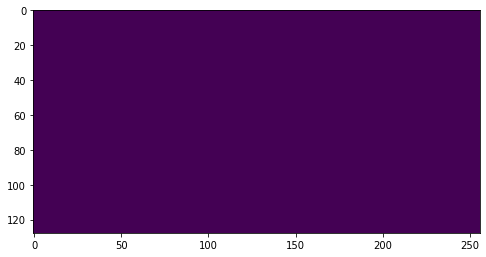

 42%|██████████████████████████████████▏                                               | 10/24 [00:11<00:16,  1.16s/it]

theta_x: 0.0965
theta_y: 0.0019
theta_z: 0.0072
phi: 0.0039
gamma: -0.0108
rho: -0.0008
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0084, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
          -19.4338,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000, -19.4338, -19.4338, -19.4338, -19.4338,   0.0000, -19.4338,
          -19.4338,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000

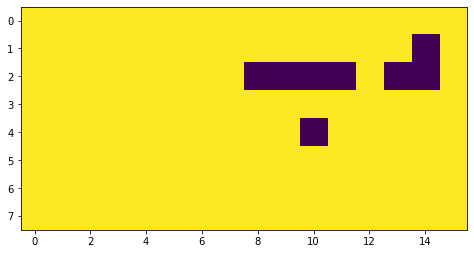

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0498, device='cuda:0')
tensor(0.0354, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


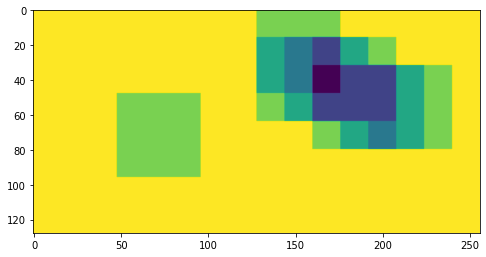

tensor(-0.2500, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5000, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


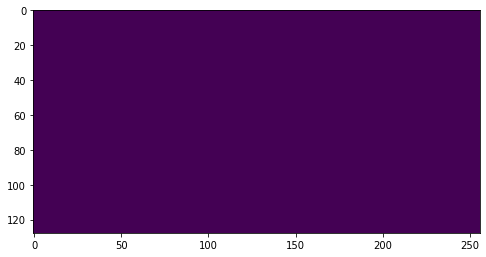

 46%|█████████████████████████████████████▌                                            | 11/24 [00:12<00:14,  1.13s/it]

theta_x: 0.0965
theta_y: 0.0019
theta_z: 0.0072
phi: 0.0039
gamma: -0.0108
rho: -0.0008
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0078, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000, -18.0323,   0.0000, -18.0323,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000, -18.0323, -18.0323,
          -18.0323, -18.0323, -18.0323, -18.0323,   0.0000,   0.0000,   0.0000,
          -18.0323,   0.0000],
         [  0.0000,   0.0000,   0.0000, -18.0323,   0.0000,   0.0000, -18.0323,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000

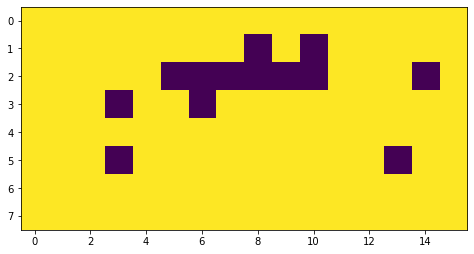

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0885, device='cuda:0')
tensor(0.0399, device='cuda:0')
tensor([[[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         ...,
         [-0.0080, -0.0080, -0.0080,  ...,  0.0000,  0.0000,  0.0000],
         [-0.0080, -0.0080, -0.0080,  ...,  0.0000,  0.0000,  0.0000],
         [-0.0080, -0.0080, -0.0080,  ...,  0.0000,  0.0000,  0.0000]]],
       device='cuda:0')


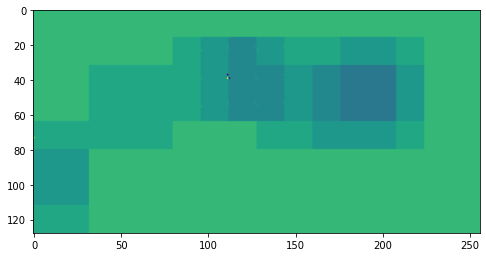

tensor(-0.2500, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5001, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


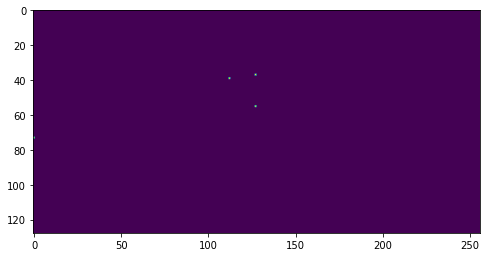

 50%|█████████████████████████████████████████                                         | 12/24 [00:13<00:13,  1.11s/it]

theta_x: 0.0965
theta_y: 0.0019
theta_z: 0.0072
phi: 0.0039
gamma: -0.0108
rho: -0.0008
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0079, device='cuda:0')
tensor(0.0079, device='cuda:0')
tensor([[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 1.5880e-02,  1.5880e-02,  3.1760e-02,  3.9700e-02,  3.9700e-02,
           2.3820e-02,  2.3820e-02,  2.3820e-02,  3.1760e-02,  7.9401e-03,
           7.9401e-03,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 2.3820e-02, -7.9401e-03, -1.8159e+01,  7.9401e-03,  7.9401e-03,
          -1.8246e+01, -1.8119e+01, -7.9401e-03, -1.8262e+01,  7.9401e-03,
          -1.8143e+01, -1.8254e+01,  1.5880e-02,  1.5880e-02,  0.0000e+00,
           0.0000e+00],
         [ 2.3820e-02,  7.9401e-03, -1.8103e+01,  3.9700e-02,

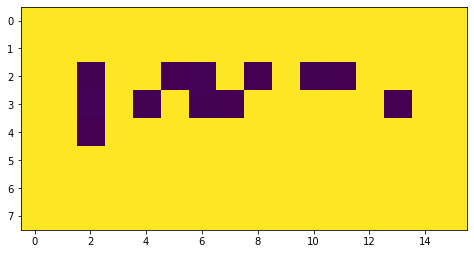

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0914, device='cuda:0')
tensor(0.0549, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


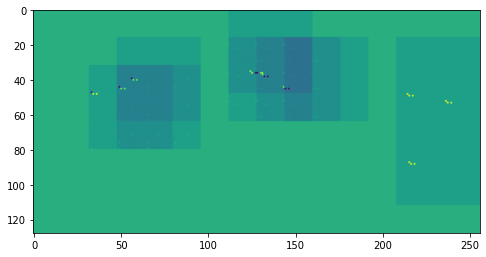

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5002, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


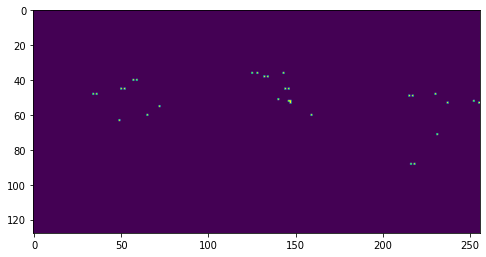

 54%|████████████████████████████████████████████▍                                     | 13/24 [00:14<00:12,  1.12s/it]

theta_x: 0.0977
theta_y: 0.0013
theta_z: 0.0076
phi: 0.0040
gamma: -0.0110
rho: -0.0008
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0083, device='cuda:0')
tensor(0.0083, device='cuda:0')
tensor([[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00, -1.8453e+01,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 1.6602e-01,  1.6602e-01,  3.3203e-02,  0.0000e+00,  0.0000e+00,
           5.8105e-02,  5.8105e-02, -5.8105e-02, -1.7838e+01, -1.7291e+01,
          -1.6037e+01, -1.5365e+01, -1.6004e+01, -1.7813e+01,  0.0000e+00,
           0.0000e+00],
         [ 1.6602e-01, -3.3203e-02,  1.6602e-01,  0.0000e+00,

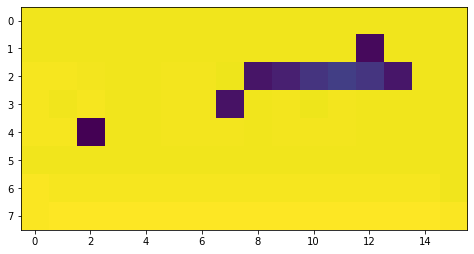

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0898, device='cuda:0')
tensor(0.0599, device='cuda:0')
tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0173, 0.0173, 0.0173,  ..., 0.0346, 0.0000, 0.0000]]],
       device='cuda:0')


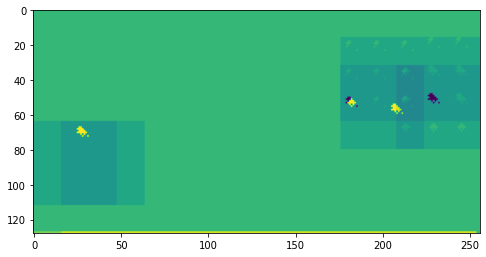

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5002, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


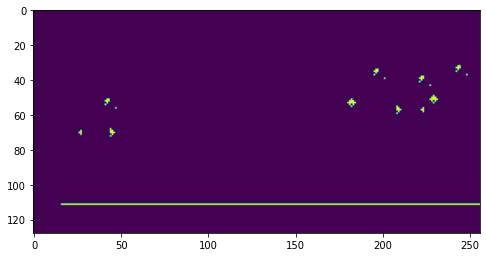

 58%|███████████████████████████████████████████████▊                                  | 14/24 [00:15<00:11,  1.10s/it]

theta_x: 0.1075
theta_y: 0.0037
theta_z: 0.0082
phi: 0.0044
gamma: -0.0120
rho: -0.0009
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0072, device='cuda:0')
tensor(0.0072, device='cuda:0')
tensor([[[ 1.4452e-02,  1.4452e-02,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 1.9511e-01,  3.6131e-01,  3.7576e-01,  1.9511e-01,  6.5036e-02,
           4.8416e-01,  5.8532e-01,  5.2029e-01,  4.7693e-01,  3.7576e-01,
           3.7576e-01,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 4.7693e-01,  4.2635e-01, -6.5036e-02, -1.4380e+01, -1.3773e+01,
          -1.4807e+01, -1.4322e+01, -1.4460e+01, -1.4496e+01, -1.3434e+01,
          -1.5681e+01,  2.9627e-01,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 3.3241e-01, -1.5233e+01, -1.2321e+01, -1.2053e+01,

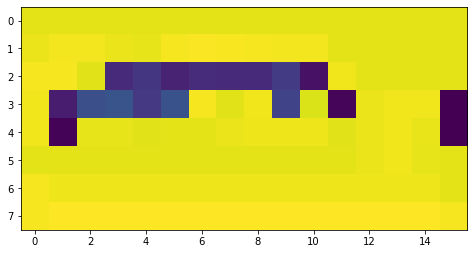

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0897, device='cuda:0')
tensor(0.0628, device='cuda:0')
tensor([[[0.0149, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0149, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0149, 0.0149, 0.0149,  ..., 0.0298, 0.0298, 0.0298],
         [0.0149, 0.0149, 0.0149,  ..., 0.0298, 0.0298, 0.0298]]],
       device='cuda:0')


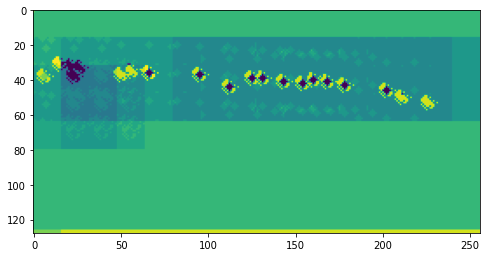

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5003, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


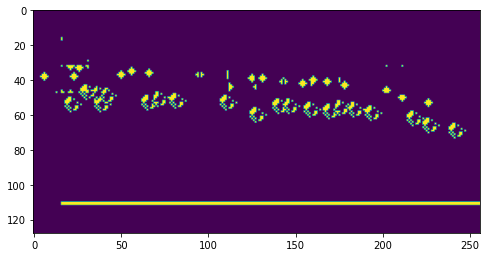

 62%|███████████████████████████████████████████████████▎                              | 15/24 [00:17<00:09,  1.10s/it]

theta_x: 0.1127
theta_y: 0.0049
theta_z: 0.0084
phi: 0.0046
gamma: -0.0127
rho: -0.0011
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0076, device='cuda:0')
tensor(0.0076, device='cuda:0')
tensor([[[ 5.8687e+00,  7.8249e+00,  7.8249e+00,  9.7812e+00,  1.1737e+01,
           1.1737e+01,  9.7812e+00,  7.8249e+00,  5.8687e+00,  7.8249e+00,
           9.7812e+00,  1.1737e+01,  1.1737e+01,  1.1737e+01,  1.1737e+01,
           7.8249e+00],
         [ 9.7047e+00,  7.7485e+00,  5.7923e+00,  7.7638e+00,  1.1676e+01,
           1.3632e+01,  1.1692e+01,  9.6742e+00,  5.7617e+00,  7.7562e+00,
           9.7735e+00,  1.3686e+01,  1.3694e+01,  1.3694e+01,  1.3694e+01,
           7.8249e+00],
         [ 7.8479e+00,  5.8687e+00,  0.0000e+00,  0.0000e+00,  1.1554e+01,
           1.3541e+01,  1.1692e+01,  9.4908e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  1.3648e+01,  1.3694e+01,  1.3694e+01,  1.3694e+01,
           7.8249e+00],
         [ 9.8041e+00,  9.6130e+00,  7.9778e+00, -6.8774e-02,

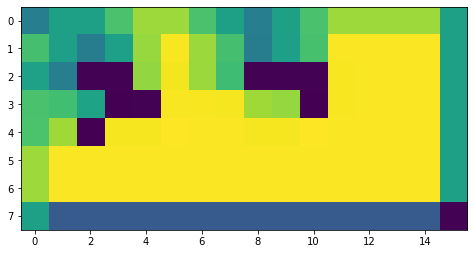

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0815, device='cuda:0')
tensor(0.0571, device='cuda:0')
tensor([[[0.0152, 0.0152, 0.0152,  ..., 0.0304, 0.0304, 0.0304],
         [0.0152, 0.0152, 0.0152,  ..., 0.0304, 0.0304, 0.0304],
         [0.0152, 0.0152, 0.0152,  ..., 0.0304, 0.0304, 0.0304],
         ...,
         [0.0152, 0.0152, 0.0152,  ..., 0.0304, 0.0304, 0.0304],
         [0.0152, 0.0152, 0.0152,  ..., 0.0304, 0.0304, 0.0304],
         [0.0152, 0.0152, 0.0152,  ..., 0.0304, 0.0304, 0.0304]]],
       device='cuda:0')


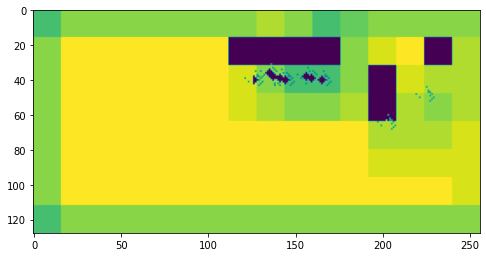

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5004, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


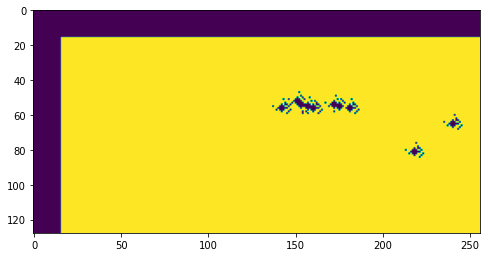

 67%|██████████████████████████████████████████████████████▋                           | 16/24 [00:18<00:08,  1.08s/it]

theta_x: 0.1212
theta_y: 0.0029
theta_z: 0.0095
phi: 0.0049
gamma: -0.0133
rho: -0.0011
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0078, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000, -18.0347,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000, -18.0347, -18.0347, -18.0347, -18.0347,
            0.0000, -18.0347, -18.0347, -18.0347, -18.0347, -18.0347, -18.0347,
          -18.0347,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000

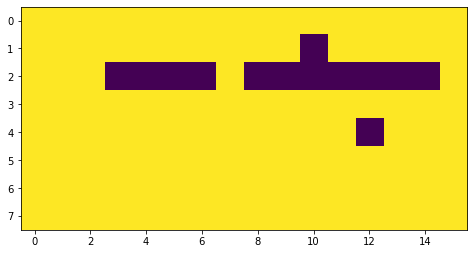

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0457, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


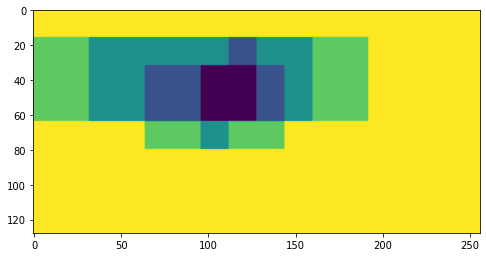

tensor(-0.2500, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(0., device='cuda:0')


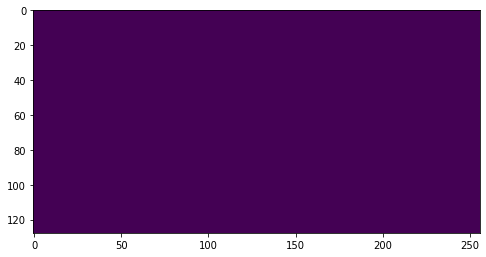

 71%|██████████████████████████████████████████████████████████                        | 17/24 [00:19<00:07,  1.05s/it]

theta_x: 0.1212
theta_y: 0.0029
theta_z: 0.0095
phi: 0.0049
gamma: -0.0133
rho: -0.0011
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0074, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000, -17.1285, -17.1285,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000, -17.1285,
          -17.1285, -17.1285, -17.1285,   0.0000, -17.1285, -17.1285, -17.1285,
          -17.1285, -17.1285],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000, -17.1285, -17.1285,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000

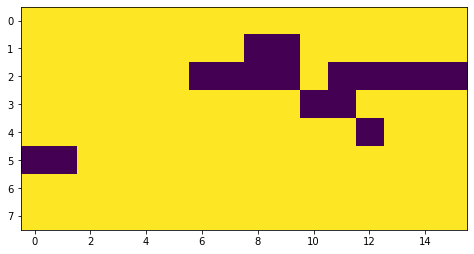

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0609, device='cuda:0')
tensor(0.0318, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


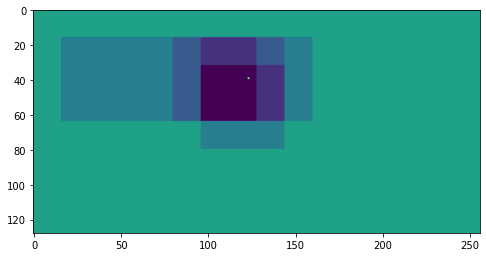

tensor(-0.2500, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5001, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


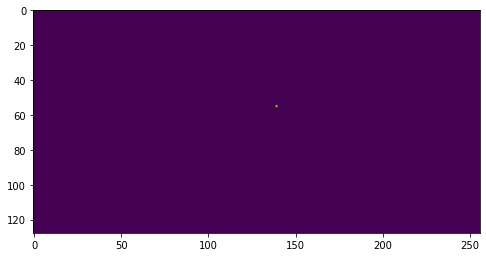

 75%|█████████████████████████████████████████████████████████████▌                    | 18/24 [00:20<00:06,  1.04s/it]

theta_x: 0.1212
theta_y: 0.0029
theta_z: 0.0095
phi: 0.0049
gamma: -0.0133
rho: -0.0011
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0086, device='cuda:0')
tensor(0.0086, device='cuda:0')
tensor([[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  8.5664e-03,
           8.5664e-03,  3.4266e-02,  3.4266e-02,  4.2832e-02,  1.7133e-02,
           8.5664e-03,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00, -1.9531e+01,
          -1.9394e+01, -1.9677e+01,  0.0000e+00, -1.9660e+01, -1.9412e+01,
          -1.9703e+01,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,

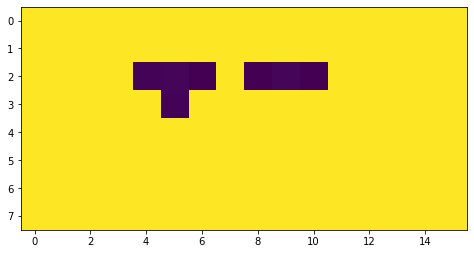

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0857, device='cuda:0')
tensor(0.0581, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


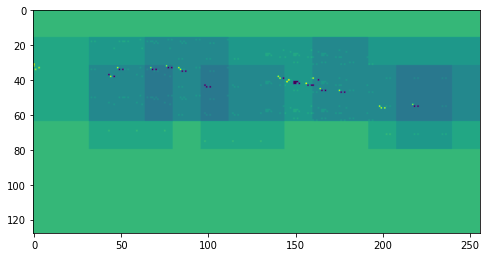

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5002, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


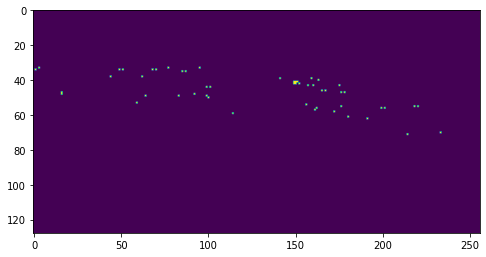

theta_x: 0.1216


 79%|████████████████████████████████████████████████████████████████▉                 | 19/24 [00:21<00:05,  1.04s/it]

theta_y: 0.0021
theta_z: 0.0097
phi: 0.0049
gamma: -0.0134
rho: -0.0011
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0083, device='cuda:0')
tensor(0.0083, device='cuda:0')
tensor([[[ 0.0000e+00,  0.0000e+00,  2.4918e-02,  2.4918e-02,  2.4918e-02,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 7.4755e-02,  7.4755e-02,  9.9674e-02,  8.3062e-03, -8.3062e-03,
           0.0000e+00,  3.0733e-01,  3.0733e-01, -1.8581e+01,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 7.4755e-02, -7.4755e-02, -1.7435e+01, -1.6546e+01, -1.6845e+01,
          -1.7285e+01, -1.8523e+01, -3.0733e-01, -1.6587e+01,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 7.4755e-02,  7.4755e-02,  7.4755e-02,  0.0000e+00,  0.0000e+00,
  

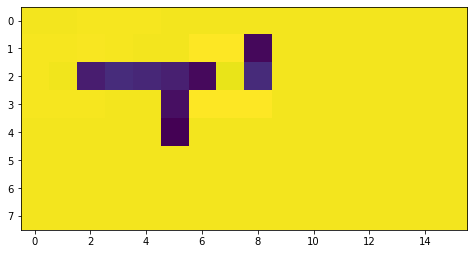

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0870, device='cuda:0')
tensor(0.0538, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


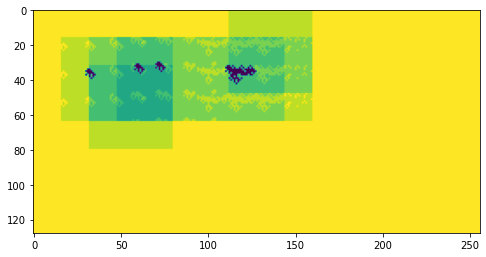

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5002, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


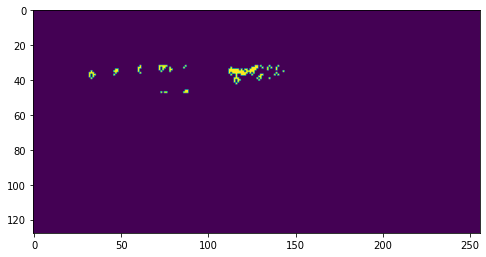

 83%|████████████████████████████████████████████████████████████████████▎             | 20/24 [00:22<00:04,  1.04s/it]

theta_x: 0.1286
theta_y: 0.0000
theta_z: 0.0102
phi: 0.0053
gamma: -0.0143
rho: -0.0010
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0073, device='cuda:0')
tensor(0.0073, device='cuda:0')
tensor([[[ 7.2541e-03, -7.2541e-03,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 7.2541e-03,  2.1762e-01,  4.2799e-01,  4.6426e-01,  3.4094e-01,
           3.6270e-02,  2.6115e-01,  2.5389e-01,  2.3213e-01,  8.7049e-02,
          -2.5389e-01, -1.4508e-02,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 2.9742e-01,  1.6684e-01,  4.3524e-01,  5.2955e-01, -1.4922e+01,
          -1.5139e+01, -1.5081e+01, -1.4269e+01, -1.4276e+01, -1.3514e+01,
          -1.4530e+01, -1.4102e+01, -5.8033e-02,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 1.0881e-01,  5.7307e-01,  3.6270e-01, -1.5807e+01,

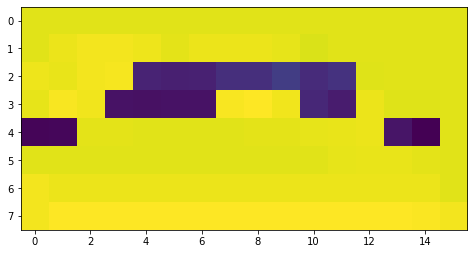

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0897, device='cuda:0')
tensor(0.0574, device='cuda:0')
tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0164, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0164, 0.0164, 0.0164,  ..., 0.0328, 0.0328, 0.0000],
         [0.0164, 0.0164, 0.0164,  ..., 0.0328, 0.0328, 0.0328]]],
       device='cuda:0')


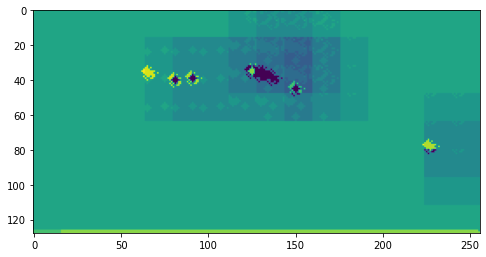

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5003, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


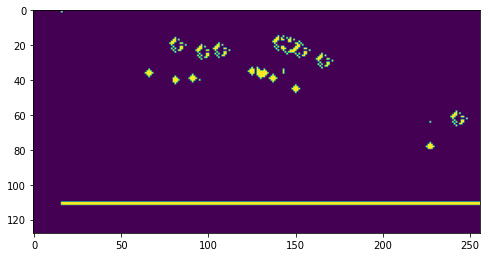

 88%|███████████████████████████████████████████████████████████████████████▊          | 21/24 [00:23<00:03,  1.04s/it]

theta_x: 0.1365
theta_y: -0.0009
theta_z: 0.0112
phi: 0.0056
gamma: -0.0152
rho: -0.0010
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0074, device='cuda:0')
tensor(0.0074, device='cuda:0')
tensor([[[ 7.5413e+00,  7.5413e+00,  7.5413e+00,  7.5339e+00,  7.5339e+00,
           7.5487e+00,  7.5413e+00,  7.5413e+00,  7.5413e+00,  7.5413e+00,
           7.5413e+00,  7.5413e+00,  7.5413e+00,  7.5413e+00,  7.5413e+00,
           3.7707e+00],
         [ 1.1172e+01,  1.3153e+01,  1.3116e+01,  1.3072e+01,  1.3205e+01,
           1.3381e+01,  1.2895e+01,  1.3205e+01,  1.2954e+01,  1.2785e+01,
           1.3595e+01,  1.3212e+01,  1.3205e+01,  1.3197e+01,  1.3197e+01,
           7.5413e+00],
         [ 1.1172e+01, -1.3256e-01,  1.0981e+01,  0.0000e+00,  1.0892e+01,
           0.0000e+00,  8.9332e+00, -7.3646e-03,  0.0000e+00,  0.0000e+00,
          -2.9458e-02,  1.1312e+01, -1.0310e-01,  1.3352e+01,  1.3087e+01,
           7.4750e+00],
         [ 9.2867e+00, -1.3256e-01,  0.0000e+00,  9.1321e+00

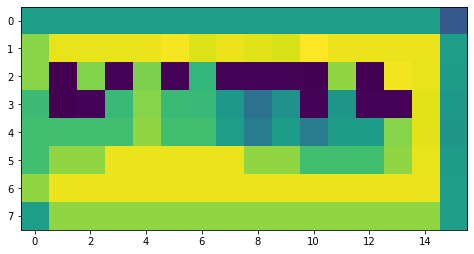

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0860, device='cuda:0')
tensor(0.0602, device='cuda:0')
tensor([[[0.0288, 0.0288, 0.0288,  ..., 0.0288, 0.0288, 0.0288],
         [0.0288, 0.0288, 0.0288,  ..., 0.0288, 0.0288, 0.0288],
         [0.0288, 0.0288, 0.0288,  ..., 0.0288, 0.0288, 0.0288],
         ...,
         [0.0144, 0.0144, 0.0144,  ..., 0.0288, 0.0288, 0.0288],
         [0.0144, 0.0144, 0.0144,  ..., 0.0288, 0.0288, 0.0288],
         [0.0144, 0.0144, 0.0144,  ..., 0.0288, 0.0288, 0.0288]]],
       device='cuda:0')


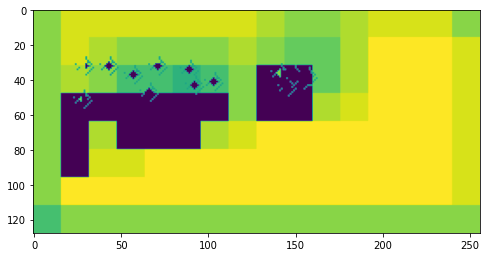

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5004, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


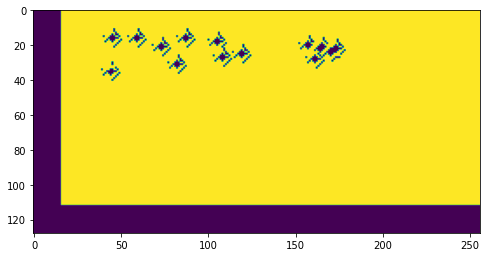

 92%|███████████████████████████████████████████████████████████████████████████▏      | 22/24 [00:24<00:02,  1.03s/it]

theta_x: 0.1418
theta_y: 0.0015
theta_z: 0.0116
phi: 0.0058
gamma: -0.0156
rho: -0.0011
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0083, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000, -19.1383, -19.1383,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000, -19.1383, -19.1383,   0.0000,   0.0000,
          -19.1383, -19.1383, -19.1383, -19.1383,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000, -19.1383,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000

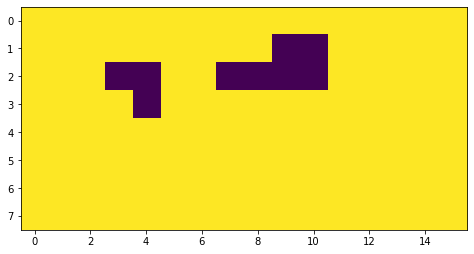

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0422, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


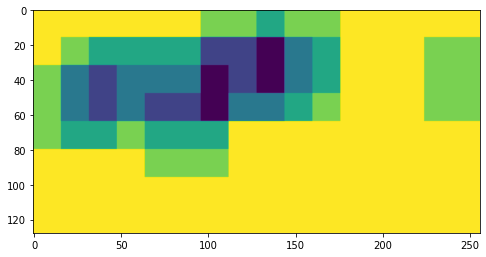

tensor(-0.2500, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(0., device='cuda:0')


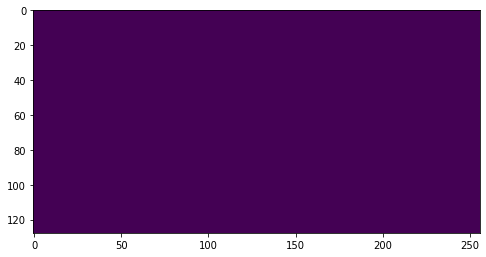

 96%|██████████████████████████████████████████████████████████████████████████████▌   | 23/24 [00:25<00:01,  1.03s/it]

theta_x: 0.1418
theta_y: 0.0015
theta_z: 0.0116
phi: 0.0058
gamma: -0.0156
rho: -0.0011
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0078, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
          -17.9398, -17.9398, -17.9398,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000, -17.9476,   0.0000,
          -17.9398, -17.8775, -17.9398,   0.0000, -17.9476, -17.9476, -17.9476,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000, -17.9476,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
          -17.9476, -17.9476],
         [  0.0000,   0.0000,   0.0000,   0.0000

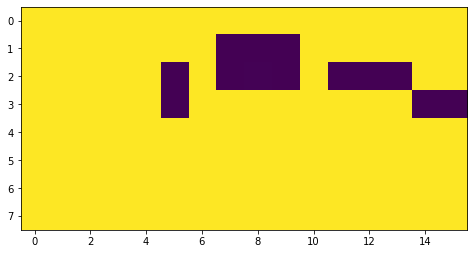

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0843, device='cuda:0')
tensor(0.0337, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


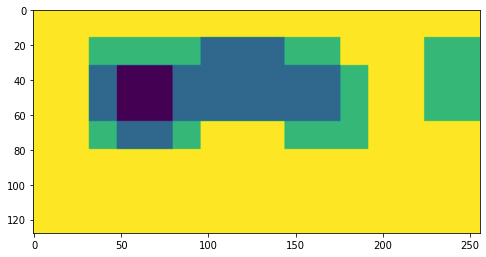

tensor(-0.2500, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5000, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


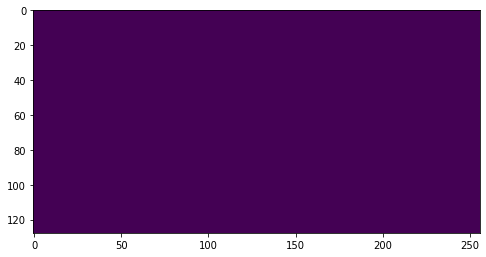

100%|██████████████████████████████████████████████████████████████████████████████████| 24/24 [00:26<00:00,  1.09s/it]

theta_x: 0.1418
theta_y: 0.0015
theta_z: 0.0116
phi: 0.0058
gamma: -0.0156
rho: -0.0011
Train Epoch: (4, 1) 	LR: 0.001000	Loss: 28.847826



  0%|                                                                                           | 0/24 [00:00<?, ?it/s]

in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0074, device='cuda:0')
tensor(0.0074, device='cuda:0')
tensor([[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 7.4002e-03, -7.4002e-03,  0.0000e+00,  7.4002e-03,  3.7001e-02,
           2.2200e-02,  7.4002e-03, -1.6969e+01,  7.4002e-03, -1.6946e+01,
           0.0000e+00,  0.0000e+00, -7.4002e-03,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 7.4002e-03,  7.4002e-03,  7.4002e-03,  1.4800e-02,  2.9601e-02,
           7.4002e-03, -1.6421e+01, -1.6969e+01, -1.6887e+01, -1.6998e+01,
          -1.7013e+01, -1.6961e+01, -1.7035e+01, -1.6983e+01,  0.0000e+00,
           0.0000e+00],
         [ 7.4002e-03, -1.7043e+01,  7.4002e-03,  1.4800e-02,  4.4401e-02,
          -1.6946e+01, -1.6946e+01, -1.6969e+01,  2.2200e-02,  2.2200e-02,

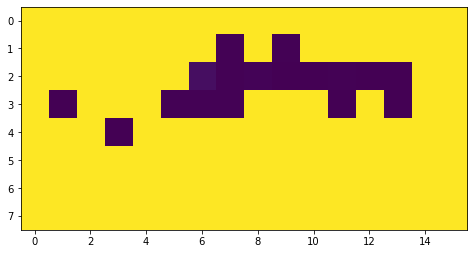

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0885, device='cuda:0')
tensor(0.0531, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


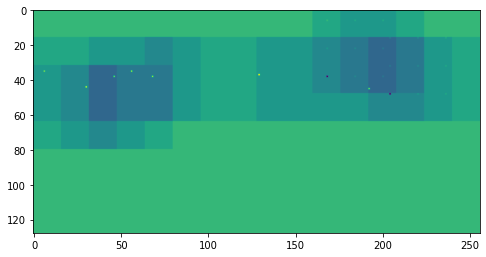

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5001, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


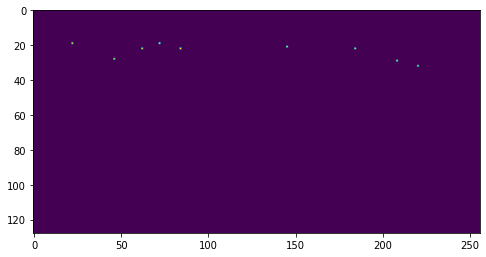

  4%|███▍                                                                               | 1/24 [00:01<00:24,  1.07s/it]

theta_x: 0.1418
theta_y: 0.0015
theta_z: 0.0116
phi: 0.0058
gamma: -0.0156
rho: -0.0011
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0083, device='cuda:0')
tensor(0.0083, device='cuda:0')
tensor([[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  4.1524e-02,  4.1524e-02,  2.4914e-02,  4.1524e-02,
           4.9829e-02,  3.3219e-02, -8.3048e-03, -1.8669e+01, -1.9010e+01,
           0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  4.1524e-02, -2.4914e-02, -1.9076e+01,  5.8133e-02,
           0.0000e+00, -1.8495e+01, -1.8096e+01, -1.8470e+01, -1.9076e+01,
           0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,

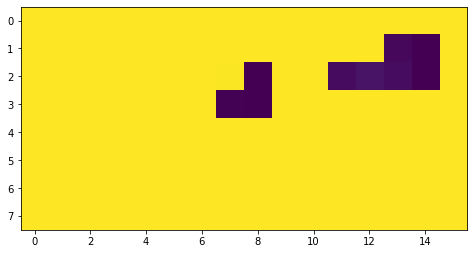

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0870, device='cuda:0')
tensor(0.0573, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


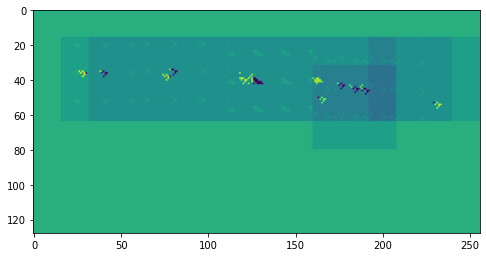

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5001, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


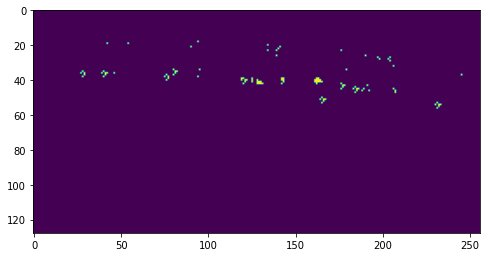

  8%|██████▉                                                                            | 2/24 [00:02<00:23,  1.06s/it]

theta_x: 0.1441
theta_y: -0.0003
theta_z: 0.0119
phi: 0.0060
gamma: -0.0160
rho: -0.0011
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0083, device='cuda:0')
tensor(0.0083, device='cuda:0')
tensor([[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  2.5742e-01,
           4.4840e-01,  1.9099e-01, -1.4947e-01,  4.1519e-02,  1.4947e-01,
           6.6430e-02, -1.1625e-01,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 0.0000e+00,  4.9822e-02,  4.9822e-02, -4.9822e-02,  2.5742e-01,
           2.1590e-01, -1.6059e+01, -1.7795e+01, -1.8833e+01, -1.7911e+01,
          -1.7886e+01, -1.7944e+01, -1.8982e+01,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 0.0000e+00,  5.8126e-02,  6.6430e-02,  4.9822e-02

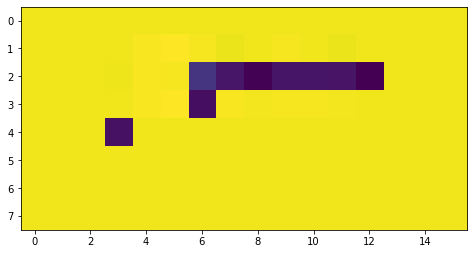

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0899, device='cuda:0')
tensor(0.0575, device='cuda:0')
tensor([[[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         ...,
         [-0.0080, -0.0080, -0.0080,  ...,  0.0000,  0.0000,  0.0000],
         [-0.0080, -0.0080, -0.0080,  ...,  0.0000,  0.0000,  0.0000],
         [-0.0080, -0.0080, -0.0080,  ...,  0.0000,  0.0000,  0.0000]]],
       device='cuda:0')


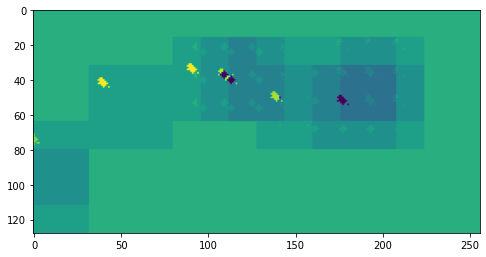

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5003, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


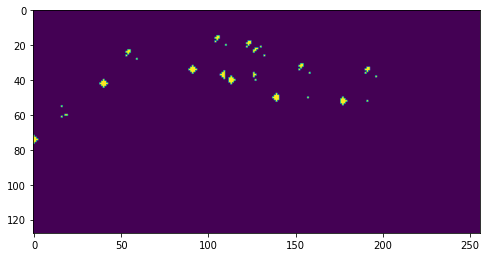

 12%|██████████▍                                                                        | 3/24 [00:03<00:21,  1.04s/it]

theta_x: 0.1469
theta_y: -0.0021
theta_z: 0.0125
phi: 0.0061
gamma: -0.0165
rho: -0.0011
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0071, device='cuda:0')
tensor(0.0071, device='cuda:0')
tensor([[[ 7.1281e-03,  7.1281e-03,  7.1281e-03,  7.1281e-03, -7.1281e-03,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 2.7087e-01, -2.8513e-02,  2.4948e-01,  5.5600e-01,  3.7066e-01,
           4.2769e-02,  1.8533e-01,  1.0692e-01,  0.0000e+00, -4.2769e-02,
          -5.7025e-02, -1.3993e+01,  1.2831e-01,  1.9959e-01, -1.4256e-02,
          -1.5782e+01],
         [ 2.0672e-01, -1.6160e+01,  2.9225e-01,  3.7066e-01, -1.4670e+01,
          -1.3993e+01, -1.4449e+01, -1.5033e+01, -1.5896e+01, -1.4898e+01,
          -1.4320e+01, -1.4933e+01, -1.4712e+01,  1.9959e-01,  1.4256e-02,
          -1.6295e+01],
         [ 2.6374e-01, -1.6160e+01, -1.6138e+01,  5.4887e-01

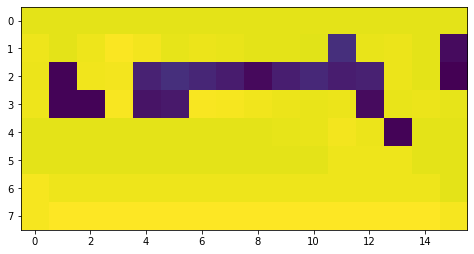

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0897, device='cuda:0')
tensor(0.0521, device='cuda:0')
tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0347, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0174, 0.0174, 0.0174,  ..., 0.0347, 0.0347, 0.0000],
         [0.0174, 0.0174, 0.0174,  ..., 0.0347, 0.0347, 0.0347]]],
       device='cuda:0')


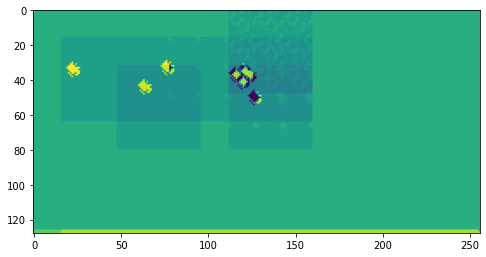

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5003, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


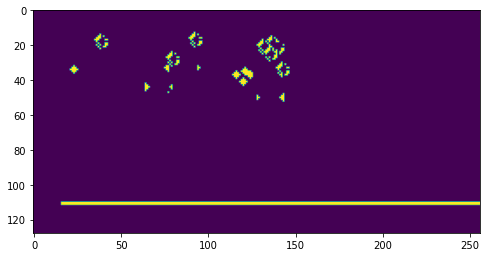

 17%|█████████████▊                                                                     | 4/24 [00:04<00:20,  1.04s/it]

theta_x: 0.1506
theta_y: -0.0042
theta_z: 0.0138
phi: 0.0064
gamma: -0.0174
rho: -0.0011
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0071, device='cuda:0')
tensor(0.0071, device='cuda:0')
tensor([[[ 7.0418,  7.1552,  7.4173,  7.2048,  7.2756,  7.2685,  7.2544,
           7.2544,  7.2544,  7.2544,  7.2544,  7.2544,  7.2544,  7.2544,
           7.2544,  3.6272],
         [10.0527, 12.4330, 12.6597, 12.2488, 12.9077, 12.5818, 12.2205,
          12.2417, 12.2984, 12.1992, 12.4401, 12.7306, 12.6668, 12.8368,
          12.7447,  7.2544],
         [ 8.0549, -0.5172,  0.0000,  8.1966,  0.0000,  0.0000,  0.0000,
           0.0000, -0.0354,  0.0000,  0.0000,  0.0000, -0.0283, -0.0708,
          -0.1842, -0.8430],
         [ 6.6380, -0.3967,  0.0000,  8.6146,  6.7372,  6.7160,  6.5955,
           6.3476,  6.1775,  6.0784,  6.2059,  6.4113,  6.8789,  7.0277,
           9.0042,  5.5329],
         [ 7.2544,  9.0680,  7.2544,  9.0680,  7.2544,  7.2544,  7.2544,
           7.2544,  7.2544,  7.254

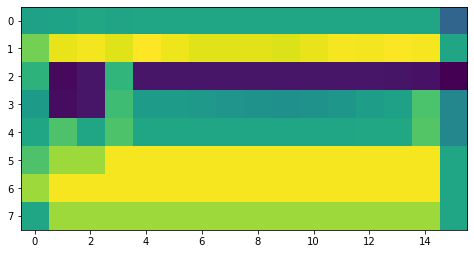

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0794, device='cuda:0')
tensor(0.0556, device='cuda:0')
tensor([[[0.0280, 0.0280, 0.0280,  ..., 0.0280, 0.0280, 0.0280],
         [0.0280, 0.0280, 0.0280,  ..., 0.0280, 0.0280, 0.0280],
         [0.0280, 0.0280, 0.0280,  ..., 0.0280, 0.0280, 0.0280],
         ...,
         [0.0140, 0.0140, 0.0140,  ..., 0.0280, 0.0280, 0.0280],
         [0.0140, 0.0140, 0.0140,  ..., 0.0280, 0.0280, 0.0280],
         [0.0140, 0.0140, 0.0140,  ..., 0.0280, 0.0280, 0.0280]]],
       device='cuda:0')


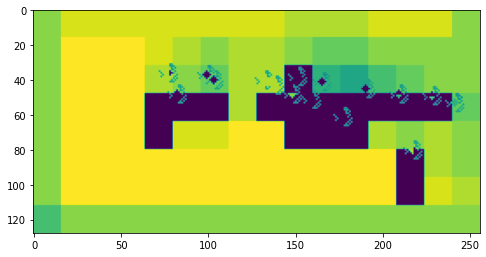

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5004, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


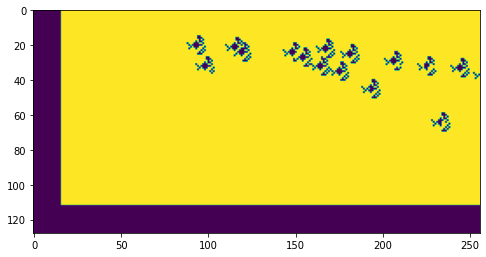

 21%|█████████████████▎                                                                 | 5/24 [00:05<00:19,  1.05s/it]

theta_x: 0.1549
theta_y: -0.0010
theta_z: 0.0129
phi: 0.0066
gamma: -0.0182
rho: -0.0014
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0081, device='cuda:0')
tensor(0.0081, device='cuda:0')
tensor([[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00, -1.8569e+01, -1.8561e+01,
           8.0595e-03, -8.0595e-03,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          -1.8569e+01, -1.8569e+01,  0.0000e+00, -1.8569e+01, -1.8561e+01,
          -1.8561e+01, -1.8561e+01,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00

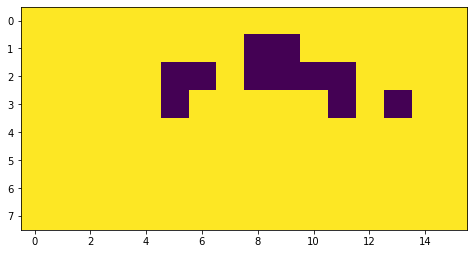

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0783, device='cuda:0')
tensor(0.0247, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


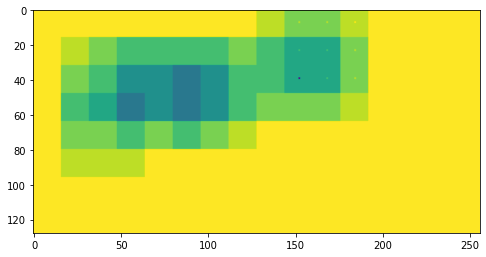

tensor(-0.2500, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5000, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


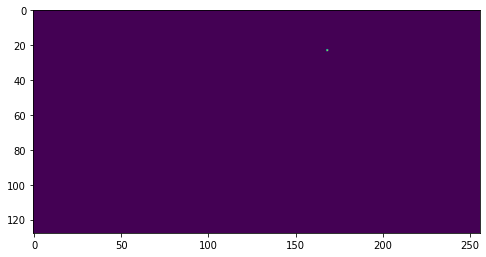

 25%|████████████████████▊                                                              | 6/24 [00:06<00:18,  1.04s/it]

theta_x: 0.1549
theta_y: -0.0010
theta_z: 0.0129
phi: 0.0066
gamma: -0.0182
rho: -0.0014
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0082, device='cuda:0')
tensor(0.0082, device='cuda:0')
tensor([[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  8.1801e-03,  8.1801e-03, -8.1801e-03,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  8.1801e-03,
           8.1801e-03, -8.1801e-03,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 0.0000e+00, -1.8847e+01, -1.8839e+01, -1.8839e+01, -1.8839e+01,
           0.0000e+00,  0.0000e+00, -1.8847e+01, -1.8847e+01, -1.8831e+01,
          -1.8765e+01, -1.8831e+01,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 0.0000e+00,  0.0000e+00, -1.8839e+01,  8.1801e-03

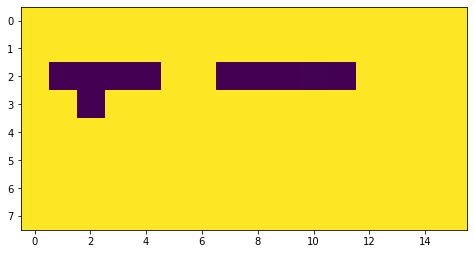

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0885, device='cuda:0')
tensor(0.0428, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


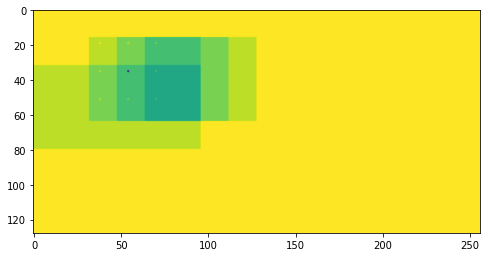

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5001, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


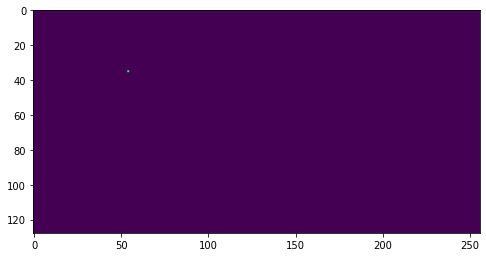

 29%|████████████████████████▏                                                          | 7/24 [00:07<00:17,  1.03s/it]

theta_x: 0.1549
theta_y: -0.0009
theta_z: 0.0129
phi: 0.0066
gamma: -0.0182
rho: -0.0014
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0080, device='cuda:0')
tensor(0.0080, device='cuda:0')
tensor([[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 0.0000e+00,  5.6142e-02,  5.6142e-02,  6.4162e-02,  4.0101e-02,
           8.0203e-03,  3.2081e-02,  3.2081e-02, -1.6041e-02, -1.6041e-02,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  4.0101e-02,
           4.0101e-02],
         [ 0.0000e+00,  5.6142e-02, -4.0101e-02, -1.8302e+01, -1.7476e+01,
          -1.7356e+01, -1.6907e+01, -1.6899e+01, -1.5912e+01, -1.8182e+01,
           0.0000e+00,  0.0000e+00,  1.6041e-02,  1.6041e-02,  5.6142e-02,
          -4.0101e-02],
         [ 0.0000e+00,  5.6142e-02,  5.6142e-02, -1.8302e+01

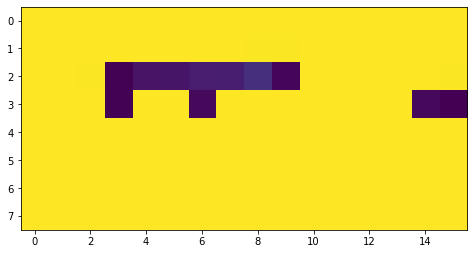

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0914, device='cuda:0')
tensor(0.0573, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


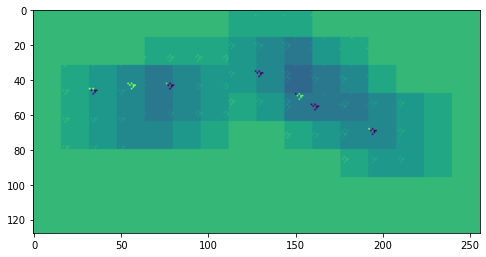

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5002, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


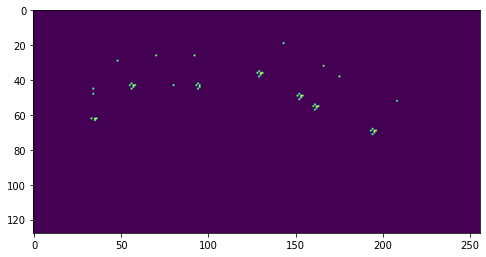

 33%|███████████████████████████▋                                                       | 8/24 [00:08<00:16,  1.02s/it]

theta_x: 0.1571
theta_y: -0.0012
theta_z: 0.0134
phi: 0.0067
gamma: -0.0184
rho: -0.0014
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0079, device='cuda:0')
tensor(0.0079, device='cuda:0')
tensor([[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 1.2641e-01,  1.2641e-01,  1.7382e-01,  2.8443e-01,  2.6073e-01,
           8.6909e-02, -1.5802e-02,  7.9008e-02,  0.0000e+00,  1.1851e-01,
           1.5802e-01, -1.7184e+01,  4.7405e-02, -2.3702e-02,  7.9008e-03,
          -7.9008e-03],
         [ 1.3431e-01,  8.6909e-02,  2.6863e-01,  2.2912e-01,  1.5802e-01,
          -1.6315e+01, -1.7864e+01,  7.9008e-02, -1.6418e+01, -1.7769e+01,
          -1.5802e-01, -1.7556e+01,  3.1603e-02, -1.7240e+01, -1.7808e+01,
          -1.7816e+01],
         [ 1.3431e-01, -7.9008e-03, -1.7935e+01,  1.6592e-01

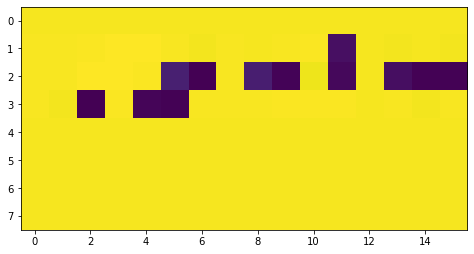

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0885, device='cuda:0')
tensor(0.0522, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


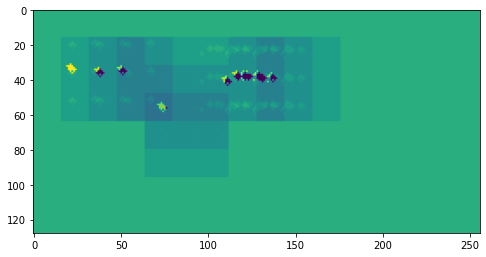

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5002, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


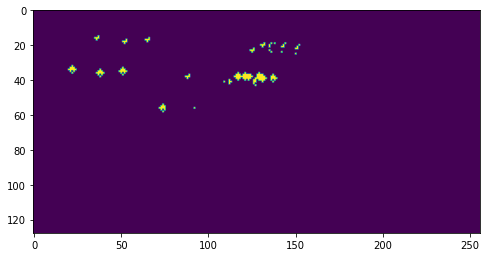

 38%|███████████████████████████████▏                                                   | 9/24 [00:09<00:15,  1.02s/it]

theta_x: 0.1598
theta_y: -0.0002
theta_z: 0.0145
phi: 0.0068
gamma: -0.0188
rho: -0.0014
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0081, device='cuda:0')
tensor(0.0081, device='cuda:0')
tensor([[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 1.5368e-01,  1.5368e-01, -8.0883e-03,  0.0000e+00,  0.0000e+00,
           2.5883e-01,  4.5295e-01,  3.6398e-01,  2.4265e-01, -8.0883e-03,
          -1.7794e-01, -2.4265e-02,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 2.6692e-01,  2.6692e-01,  1.0515e-01,  0.0000e+00,  0.0000e+00,
           2.5883e-01,  2.9118e-01, -1.6791e+01, -1.4721e+01, -1.6541e+01,
          -1.7042e+01, -1.7738e+01, -1.1324e-01, -8.0883e-03,  0.0000e+00,
           0.0000e+00],
         [ 2.6692e-01,  5.6618e-02, -1.8369e+01,  0.0000e+00

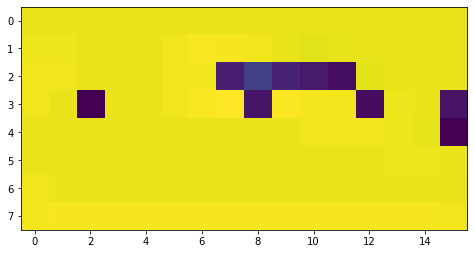

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0898, device='cuda:0')
tensor(0.0599, device='cuda:0')
tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0342, 0.0000],
         [0.0171, 0.0171, 0.0171,  ..., 0.0342, 0.0000, 0.0000]]],
       device='cuda:0')


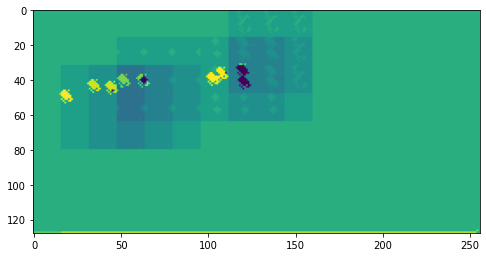

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5003, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


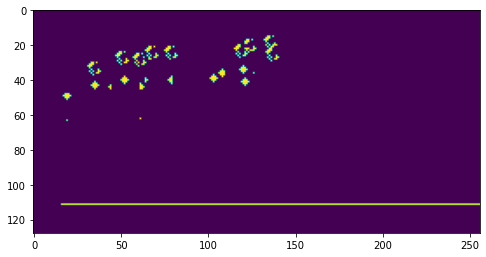

 42%|██████████████████████████████████▏                                               | 10/24 [00:10<00:14,  1.03s/it]

theta_x: 0.1644
theta_y: -0.0023
theta_z: 0.0156
phi: 0.0071
gamma: -0.0197
rho: -0.0014
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0070, device='cuda:0')
tensor(0.0070, device='cuda:0')
tensor([[[ 2.2406e-01,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  1.4004e-02,
           1.4004e-02],
         [ 3.9911e-01,  2.3106e-01, -7.0020e-03,  4.4813e-01,  1.0153e+00,
           7.7022e-01,  7.9822e-01,  7.8422e-01,  3.2209e-01, -1.1903e-01,
          -2.3807e-01, -3.5010e-02, -7.0020e-02,  0.0000e+00,  1.4004e-02,
           1.4004e-02],
         [ 4.6213e-01,  4.2012e-01,  2.1006e-01,  4.6213e-01,  8.0523e-01,
          -1.2653e+01, -1.0881e+01, -9.9428e+00, -1.0769e+01, -1.2506e+01,
          -1.4641e+01, -1.3122e+01, -1.3731e+01, -1.2407e+01, -1.2954e+01,
           0.0000e+00],
         [ 4.6213e-01,  4.2012e-01, -1.4606e+01, -1.4886e+01

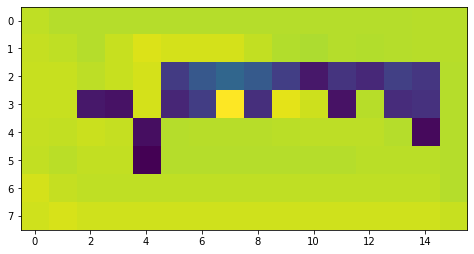

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0897, device='cuda:0')
tensor(0.0598, device='cuda:0')
tensor([[[0.0299, 0.0000, 0.0000,  ..., 0.0000, 0.0299, 0.0299],
         [0.0299, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0299, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0150, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0150, 0.0150, 0.0150,  ..., 0.0299, 0.0299, 0.0299],
         [0.0150, 0.0150, 0.0150,  ..., 0.0299, 0.0299, 0.0299]]],
       device='cuda:0')


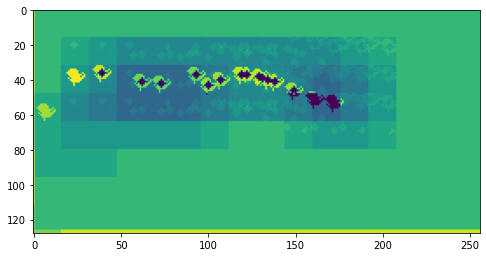

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5004, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


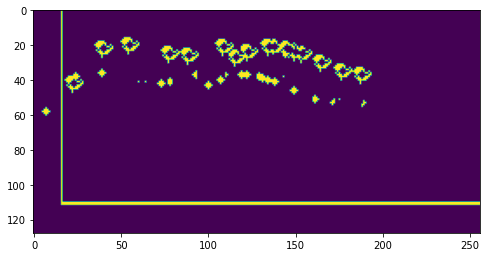

 46%|█████████████████████████████████████▌                                            | 11/24 [00:11<00:13,  1.03s/it]

theta_x: 0.1697
theta_y: -0.0035
theta_z: 0.0175
phi: 0.0074
gamma: -0.0205
rho: -0.0013
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0072, device='cuda:0')
tensor(0.0072, device='cuda:0')
tensor([[[ 7.3846,  7.3846,  7.3846,  7.3846,  7.3846,  7.3846,  7.3846,
           7.3846,  7.3846,  7.3846,  7.3846,  7.3846,  7.3846,  7.3846,
           7.3846,  3.6923],
         [11.0408, 12.8869, 13.1465, 12.8941, 12.6778, 12.7715, 12.9807,
          12.8292, 12.5696, 12.8437, 12.7211, 12.9663, 12.9518, 12.8653,
          13.0023,  7.3846],
         [ 9.1946, 10.8533,  0.0000, 11.0480,  8.7980,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000, -0.0216, -0.0288,
          -0.0505, -0.3389],
         [ 7.3485,  9.1946,  0.0000, 11.0480,  8.9855,  6.9879,  7.0096,
           6.9879,  7.0168,  6.8293,  7.0096,  7.0961,  7.2836,  5.5024,
           7.2043,  0.0000],
         [ 7.3846,  9.2307,  9.2307, 11.0768,  9.2307,  7.3846,  7.3846,
           7.3846,  7.3846,  7.384

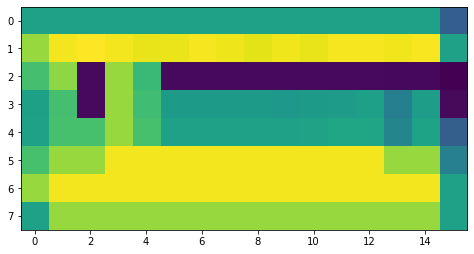

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0860, device='cuda:0')
tensor(0.0602, device='cuda:0')
tensor([[[0.0295, 0.0295, 0.0295,  ..., 0.0295, 0.0295, 0.0295],
         [0.0295, 0.0295, 0.0295,  ..., 0.0295, 0.0295, 0.0295],
         [0.0295, 0.0295, 0.0295,  ..., 0.0295, 0.0295, 0.0295],
         ...,
         [0.0147, 0.0147, 0.0147,  ..., 0.0295, 0.0295, 0.0295],
         [0.0147, 0.0147, 0.0147,  ..., 0.0295, 0.0295, 0.0295],
         [0.0147, 0.0147, 0.0147,  ..., 0.0295, 0.0295, 0.0295]]],
       device='cuda:0')


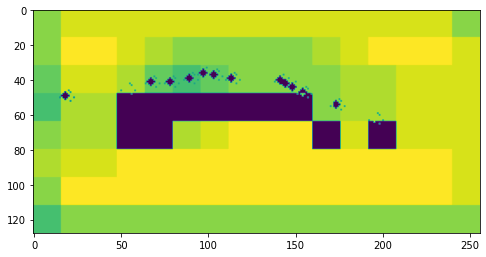

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5005, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


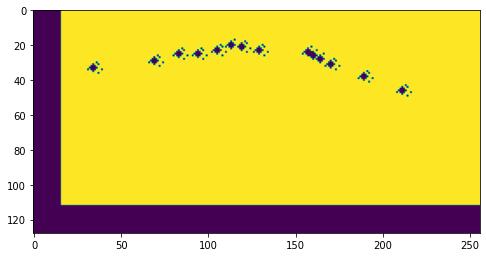

 50%|█████████████████████████████████████████                                         | 12/24 [00:12<00:12,  1.03s/it]

theta_x: 0.1738
theta_y: -0.0073
theta_z: 0.0179
phi: 0.0076
gamma: -0.0211
rho: -0.0012
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0083, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000, -19.1359, -19.1359, -19.1359,
          -19.1359, -19.1359, -19.1359,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000, -19.1359,   0.0000,   0.0000, -19.1359,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000, -19.135

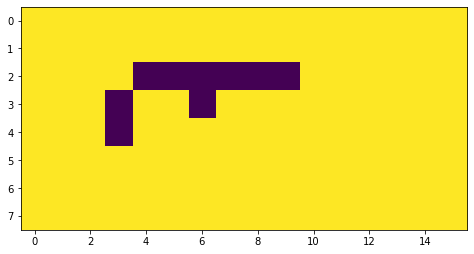

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0914, device='cuda:0')
tensor(0.0076, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


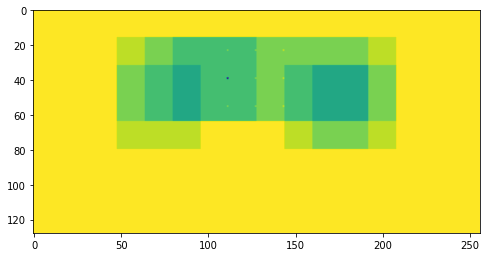

tensor(-0.2500, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5001, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


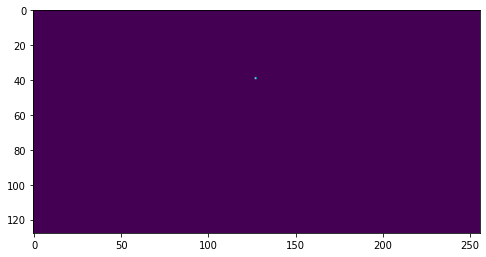

 54%|████████████████████████████████████████████▍                                     | 13/24 [00:13<00:11,  1.03s/it]

theta_x: 0.1738
theta_y: -0.0073
theta_z: 0.0179
phi: 0.0076
gamma: -0.0211
rho: -0.0012
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0083, device='cuda:0')
tensor(0.0083, device='cuda:0')
tensor([[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  2.4915e-02,  3.3219e-02,  4.1524e-02,
           1.6610e-02, -2.4915e-02,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 8.3048e-03,  8.3048e-03,  1.6610e-02,  0.0000e+00, -1.8885e+01,
          -1.8769e+01, -1.8927e+01, -1.9126e+01,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 2.4915e-02,  2.4915e-02, -1.8860e+01, -1.9076e+01

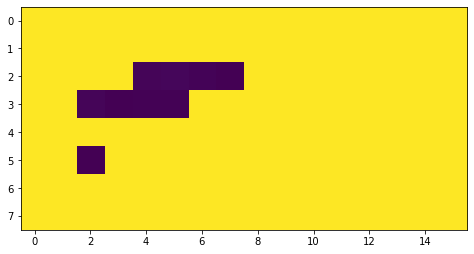

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0885, device='cuda:0')
tensor(0.0619, device='cuda:0')
tensor([[[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         ...,
         [-0.0070, -0.0070, -0.0070,  ...,  0.0000,  0.0000,  0.0000],
         [-0.0070, -0.0070, -0.0070,  ...,  0.0000,  0.0000,  0.0000],
         [-0.0070, -0.0070, -0.0070,  ...,  0.0000,  0.0000,  0.0000]]],
       device='cuda:0')


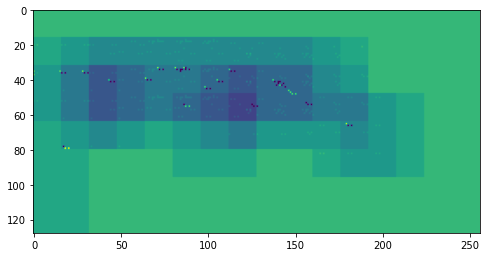

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5001, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


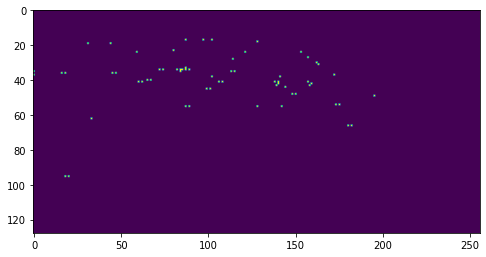

 58%|███████████████████████████████████████████████▊                                  | 14/24 [00:14<00:10,  1.02s/it]

theta_x: 0.1744
theta_y: -0.0074
theta_z: 0.0181
phi: 0.0076
gamma: -0.0212
rho: -0.0012
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0091, device='cuda:0')
tensor(0.0091, device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.1189,   0.1189,
            0.0640, -20.4251,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.1189,  -0.0640,
          -19.2914, -20.3520,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.1189,   0.1189,
            0.1189,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0

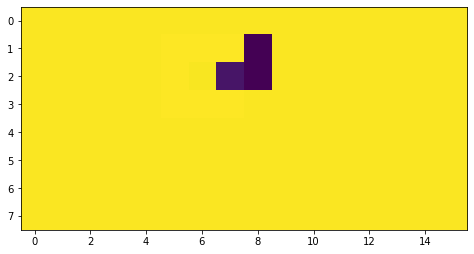

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0914, device='cuda:0')
tensor(0.0558, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


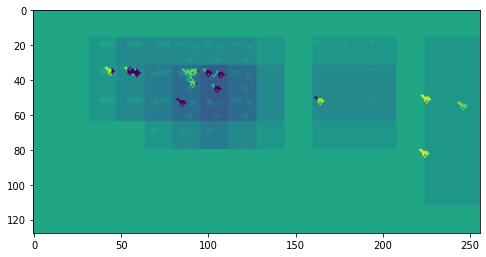

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5002, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


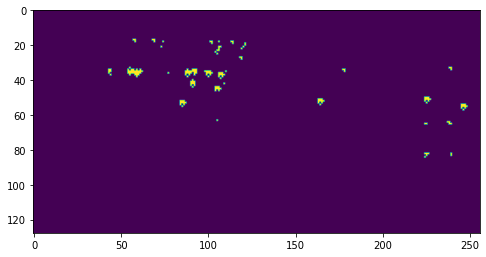

 62%|███████████████████████████████████████████████████▎                              | 15/24 [00:15<00:09,  1.04s/it]

theta_x: 0.1829
theta_y: -0.0057
theta_z: 0.0178
phi: 0.0079
gamma: -0.0219
rho: -0.0013
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0087, device='cuda:0')
tensor(0.0087, device='cuda:0')
tensor([[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 6.0905e-02,  6.0905e-02,  3.4803e-01,  6.7866e-01,  4.0894e-01,
          -1.0441e-01, -1.1311e-01,  0.0000e+00,  7.8307e-02,  7.8307e-02,
          -6.0905e-02,  0.0000e+00,  0.0000e+00,  0.0000e+00,  5.2205e-02,
           5.2205e-02],
         [ 1.0441e-01,  1.0441e-01,  4.4374e-01,  2.5232e-01, -1.7958e+01,
          -1.7053e+01, -1.9786e+01,  0.0000e+00,  8.7008e-02,  8.7008e-02,
          -1.9002e+01, -1.7402e-02,  0.0000e+00,  0.0000e+00,  2.0882e-01,
           6.9606e-02],
         [ 1.0441e-01,  8.7008e-02, -1.8585e+01,  6.8736e-01

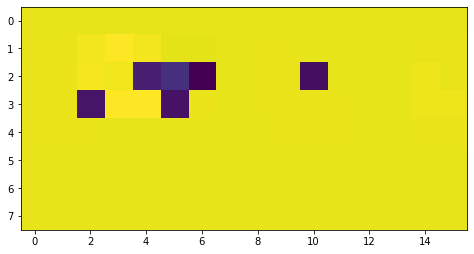

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0914, device='cuda:0')
tensor(0.0616, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


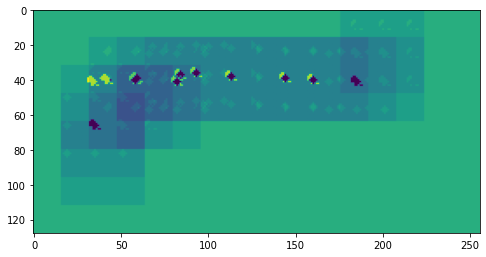

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5003, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


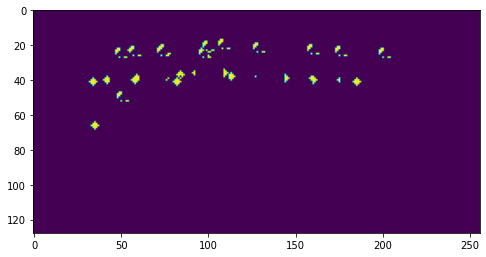

 67%|██████████████████████████████████████████████████████▋                           | 16/24 [00:16<00:08,  1.03s/it]

theta_x: 0.1853
theta_y: -0.0081
theta_z: 0.0186
phi: 0.0081
gamma: -0.0224
rho: -0.0012
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0084, device='cuda:0')
tensor(0.0084, device='cuda:0')
tensor([[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 2.9443e-01,  6.6456e-01,  6.9821e-01,  6.3933e-01,  1.8507e-01,
          -5.8885e-02, -1.0936e-01,  2.2713e-01, -8.4122e-02, -6.7297e-02,
           3.3649e-01,  3.3649e-01, -1.1777e-01,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 4.3743e-01,  8.0757e-01,  8.2439e-01, -1.6135e+01, -1.6109e+01,
          -1.7043e+01, -1.8473e+01,  2.2713e-01, -1.8238e+01,  6.7297e-02,
           3.3649e-01,  1.1777e-01, -1.9045e+01,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 4.3743e-01,  5.8885e-01, -1.7825e+01,  1.1777e+00

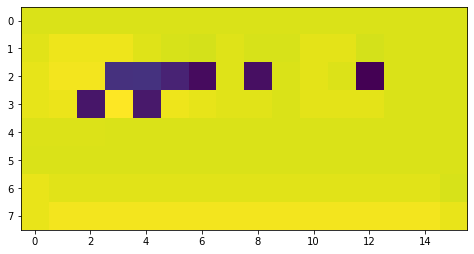

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0912, device='cuda:0')
tensor(0.0598, device='cuda:0')
tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0150, 0.0150, 0.0150,  ..., 0.0299, 0.0299, 0.0000],
         [0.0150, 0.0150, 0.0150,  ..., 0.0299, 0.0299, 0.0000]]],
       device='cuda:0')


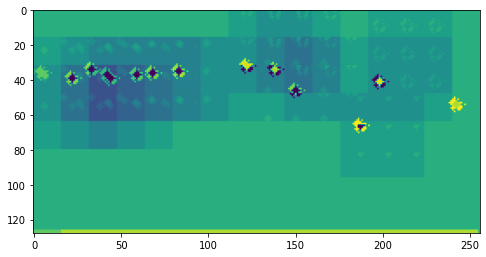

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5004, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


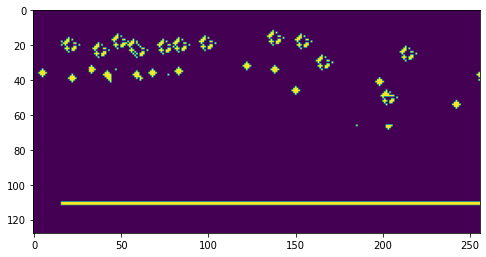

 71%|██████████████████████████████████████████████████████████                        | 17/24 [00:17<00:07,  1.02s/it]

theta_x: 0.1916
theta_y: -0.0100
theta_z: 0.0198
phi: 0.0084
gamma: -0.0233
rho: -0.0011
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0080, device='cuda:0')
tensor(0.0080, device='cuda:0')
tensor([[[ 7.4011e-01,  7.4011e-01,  7.6398e-01,  7.6398e-01,  7.6398e-01,
           7.6398e-01,  7.6398e-01,  7.6398e-01,  7.6398e-01,  7.6398e-01,
           7.6398e-01,  7.6398e-01,  7.6398e-01,  7.6398e-01,  1.2415e+00,
           9.8681e-01],
         [ 8.6744e-01,  8.6744e-01,  9.3906e-01,  1.0903e+00,  1.4563e+00,
           1.3608e+00,  1.1141e-01,  7.1623e-01,  1.0982e+00,  1.2256e+00,
           6.8440e-01,  1.0903e+00,  1.3608e+00,  7.6398e-01,  1.7190e+00,
          -1.4142e+01],
         [ 3.8199e-01,  1.2733e-01,  5.6503e-01,  7.1623e-01,  8.2765e-01,
          -1.6012e+01, -1.6792e+01,  4.7749e-02,  3.4220e-01,  4.2178e-01,
          -1.5749e+01, -1.4388e+01,  3.9791e-01, -1.6251e+01,  1.2813e+00,
          -1.6131e+01],
         [ 3.8199e-01,  1.2733e-01,  5.6503e-01,  5.0932e-01

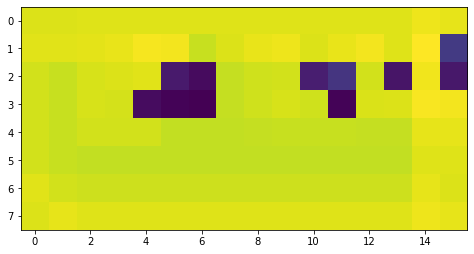

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0897, device='cuda:0')
tensor(0.0617, device='cuda:0')
tensor([[[0.0353, 0.0353, 0.0353,  ..., 0.0353, 0.0353, 0.0353],
         [0.0353, 0.0000, 0.0353,  ..., 0.0353, 0.0353, 0.0353],
         [0.0353, 0.0000, 0.0000,  ..., 0.0000, 0.0353, 0.0353],
         ...,
         [0.0176, 0.0000, 0.0000,  ..., 0.0000, 0.0353, 0.0353],
         [0.0176, 0.0176, 0.0176,  ..., 0.0353, 0.0353, 0.0353],
         [0.0176, 0.0176, 0.0176,  ..., 0.0353, 0.0353, 0.0353]]],
       device='cuda:0')


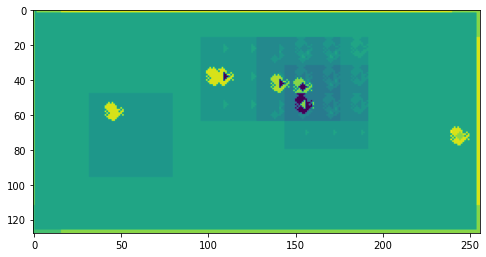

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5004, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


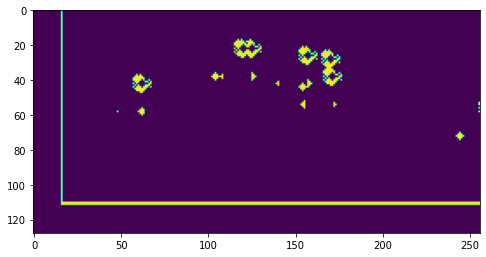

 75%|█████████████████████████████████████████████████████████████▌                    | 18/24 [00:18<00:06,  1.02s/it]

theta_x: 0.1956
theta_y: -0.0104
theta_z: 0.0210
phi: 0.0086
gamma: -0.0238
rho: -0.0012
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0076, device='cuda:0')
tensor(0.0076, device='cuda:0')
tensor([[[ 7.7330e+00,  7.7784e+00,  7.7481e+00,  7.7481e+00,  7.7481e+00,
           7.7481e+00,  7.7481e+00,  7.7481e+00,  7.7481e+00,  7.7481e+00,
           7.7481e+00,  7.7481e+00,  7.7481e+00,  7.7481e+00,  7.7481e+00,
           3.8740e+00],
         [ 1.1456e+01,  1.3605e+01,  1.3695e+01,  1.3559e+01,  1.3521e+01,
           1.3393e+01,  1.3438e+01,  1.3438e+01,  1.3703e+01,  1.3514e+01,
           1.3945e+01,  1.3567e+01,  1.3559e+01,  1.3544e+01,  1.3544e+01,
           7.8238e+00],
         [ 9.3219e+00, -6.0532e-02,  0.0000e+00,  1.3559e+01,  1.1584e+01,
           9.3219e+00,  0.0000e+00,  0.0000e+00, -7.5665e-03,  1.1198e+01,
          -7.5665e-03,  1.3552e+01,  1.3552e+01,  1.1660e+01,  1.1456e+01,
          -2.4213e-01],
         [ 9.5338e+00,  1.1471e+01,  1.1486e+01,  1.3559e+01

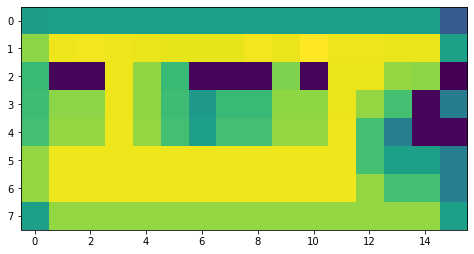

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0804, device='cuda:0')
tensor(0.0563, device='cuda:0')
tensor([[[0.0283, 0.0283, 0.0283,  ..., 0.0283, 0.0283, 0.0283],
         [0.0283, 0.0283, 0.0283,  ..., 0.0283, 0.0283, 0.0283],
         [0.0283, 0.0283, 0.0283,  ..., 0.0283, 0.0283, 0.0283],
         ...,
         [0.0142, 0.0142, 0.0142,  ..., 0.0283, 0.0283, 0.0283],
         [0.0142, 0.0142, 0.0142,  ..., 0.0283, 0.0283, 0.0283],
         [0.0142, 0.0142, 0.0142,  ..., 0.0283, 0.0283, 0.0283]]],
       device='cuda:0')


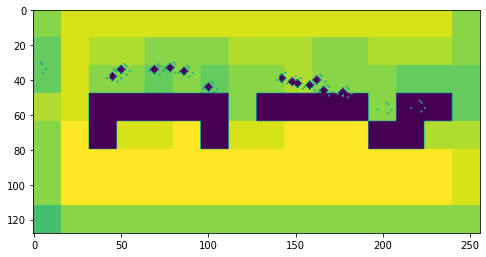

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5005, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


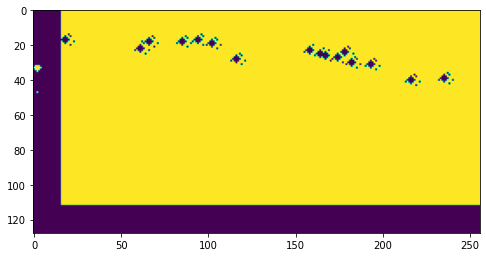

 79%|████████████████████████████████████████████████████████████████▉                 | 19/24 [00:19<00:05,  1.05s/it]

theta_x: 0.2002
theta_y: -0.0123
theta_z: 0.0204
phi: 0.0088
gamma: -0.0244
rho: -0.0011
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0082, device='cuda:0')
tensor(0., device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000, -18.8480,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000, -18.6271, -18.8235, -18.8480,
          -18.8480, -18.8480, -18.8480,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000, -18.8235,   0.0000,   0.0000,
            0.0000,   0.0000, -18.8480,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.000

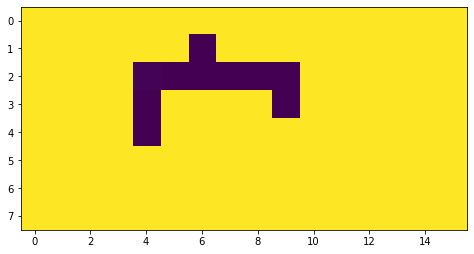

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0899, device='cuda:0')
tensor(0.0386, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


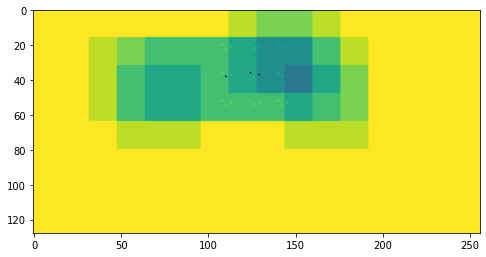

tensor(-0.2500, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5001, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


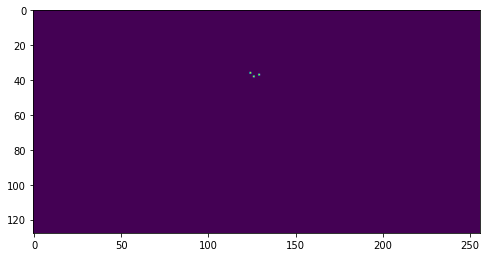

theta_x: 0.2002

 83%|████████████████████████████████████████████████████████████████████▎             | 20/24 [00:20<00:04,  1.05s/it]


theta_y: -0.0123
theta_z: 0.0204
phi: 0.0088
gamma: -0.0244
rho: -0.0011
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0074, device='cuda:0')
tensor(0.0074, device='cuda:0')
tensor([[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 3.6835e-02,  1.4734e-02,  2.2101e-02,  2.9468e-02,  2.9468e-02,
           0.0000e+00,  7.3670e-03,  1.4734e-02,  2.2101e-02,  7.3670e-03,
           2.2101e-02,  2.9468e-02, -2.2101e-02, -7.3670e-03,  0.0000e+00,
           0.0000e+00],
         [ 7.3670e-03, -1.6708e+01, -1.6716e+01,  1.4734e-02, -1.6627e+01,
          -1.6576e+01, -1.6775e+01, -1.6767e+01, -1.6664e+01, -1.6377e+01,
          -1.6686e+01, -1.6495e+01, -1.6672e+01, -1.6929e+01, -1.6893e+01,
          -1.6974e+01],
         [ 3.6835e-02, -1.6885e+01, -1.6893e+01, -1.6878e+01,  4.4202e-02,


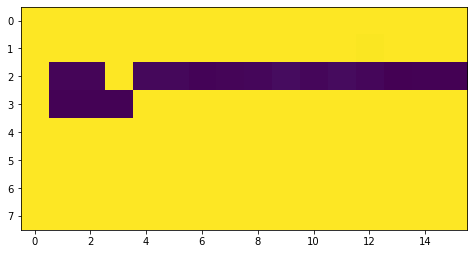

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0899, device='cuda:0')
tensor(0.0629, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


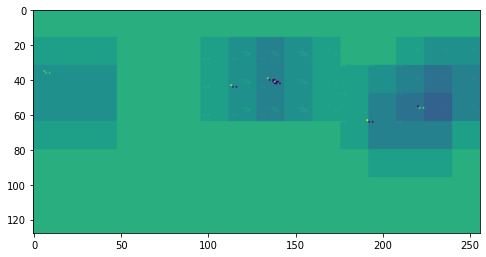

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5002, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


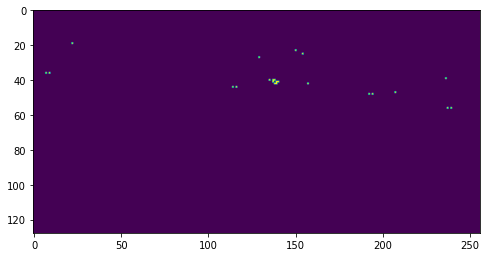

 88%|███████████████████████████████████████████████████████████████████████▊          | 21/24 [00:21<00:03,  1.08s/it]

theta_x: 0.2007
theta_y: -0.0121
theta_z: 0.0205
phi: 0.0089
gamma: -0.0245
rho: -0.0011
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0073, device='cuda:0')
tensor(0.0073, device='cuda:0')
tensor([[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 0.0000e+00,  7.2696e-02,  8.7236e-02,  8.7236e-02,  2.1809e-02,
          -7.2696e-03,  2.9079e-02,  2.9079e-02,  5.0887e-02,  2.9079e-02,
          -5.0887e-02,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 8.7236e-02,  1.3812e-01,  6.5427e-02,  1.2358e-01, -1.5324e+01,
          -1.5906e+01, -1.5855e+01, -1.5339e+01, -1.5353e+01, -1.4648e+01,
          -1.5928e+01, -1.6342e+01,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [-5.8157e-02,  1.6720e-01, -7.2696e-03, -1.6415e+01

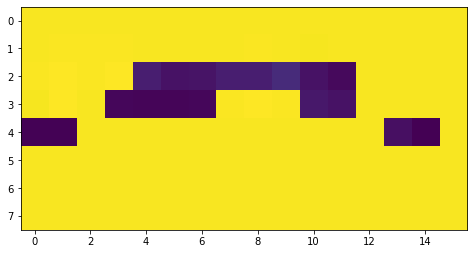

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0870, device='cuda:0')
tensor(0.0553, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


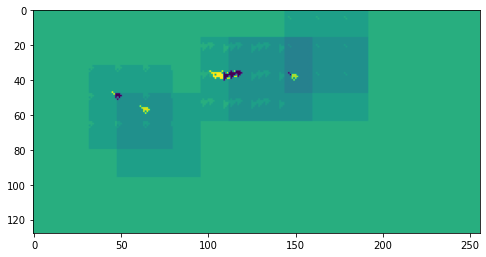

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5002, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


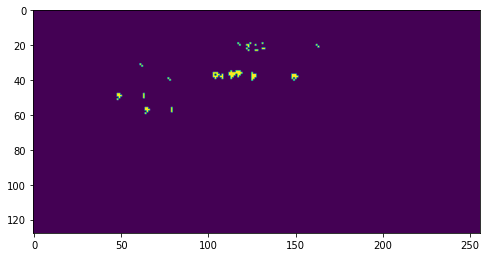

 92%|███████████████████████████████████████████████████████████████████████████▏      | 22/24 [00:22<00:02,  1.09s/it]

theta_x: 0.2036
theta_y: -0.0115
theta_z: 0.0209
phi: 0.0090
gamma: -0.0248
rho: -0.0012
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0083, device='cuda:0')
tensor(0.0083, device='cuda:0')
tensor([[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  7.4378e-02,  7.4378e-02, -5.7849e-02, -1.6421e+01,
          -1.7454e+01, -9.0906e-02,  4.1321e-02,  4.9585e-02, -3.3057e-02,
           8.2642e-03],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  7.4378e-02,  5.7849e-02, -1.5685e+01, -1.6223e+01,
          -1.6628e+01, -1.8760e+01,  1.4049e-01,  1.3223e-01, -7.4378e-02,
          -1.8818e+01],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00

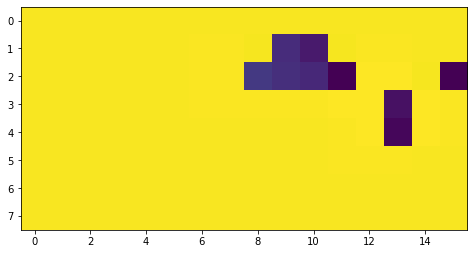

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0843, device='cuda:0')
tensor(0.0578, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


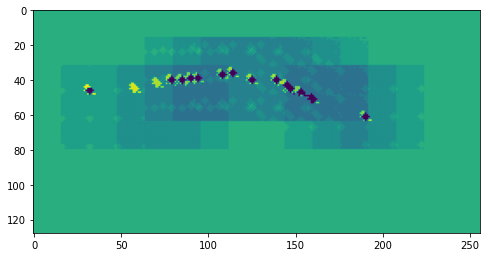

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5003, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


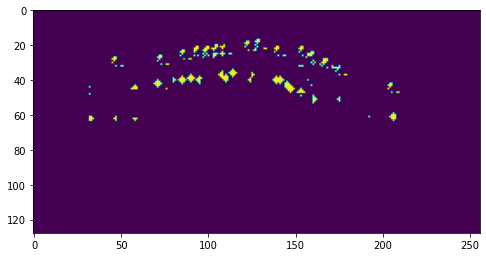

 96%|██████████████████████████████████████████████████████████████████████████████▌   | 23/24 [00:24<00:01,  1.10s/it]

theta_x: 0.2091
theta_y: -0.0098
theta_z: 0.0197
phi: 0.0093
gamma: -0.0254
rho: -0.0013
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0076, device='cuda:0')
tensor(0.0076, device='cuda:0')
tensor([[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  7.5561e-02,  1.3601e-01,
          -9.3132e-10, -6.0449e-02,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 3.3247e-01,  1.2090e-01,  3.4002e-01,  8.8406e-01,  1.3752e+00,
           1.0201e+00,  5.8938e-01,  1.9646e-01,  1.5112e-02, -4.1558e-01,
          -1.3427e+01,  1.5868e-01, -1.3367e+01, -1.3782e+01,  3.0980e-01,
          -1.1334e-01],
         [ 1.3601e-01,  5.8938e-01,  3.4002e-01,  1.0503e+00,  9.2184e-01,
          -1.1568e+01, -1.3556e+01, -1.3012e+01, -1.4976e+01, -1.4062e+01,
          -1.6223e+01, -1.5868e-01, -1.4538e+01, -1.5346e+01, -1.5346e+01,
          -1.4477e+01],
         [ 3.7025e-01, -1.6775e+01,  3.4002e-01, -1.6102e+01

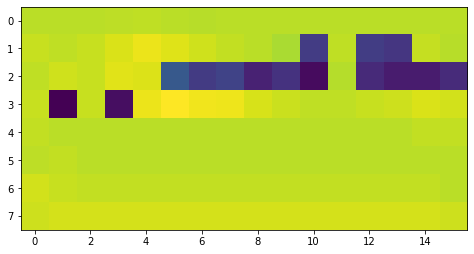

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0897, device='cuda:0')
tensor(0.0538, device='cuda:0')
tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0174, 0.0174, 0.0174,  ..., 0.0347, 0.0347, 0.0000],
         [0.0174, 0.0174, 0.0174,  ..., 0.0347, 0.0347, 0.0000]]],
       device='cuda:0')


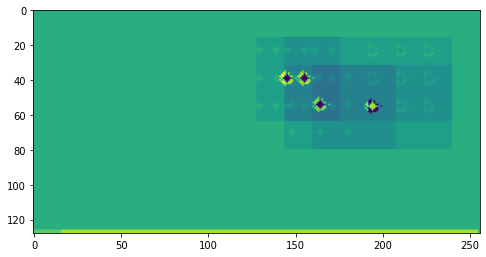

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5004, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


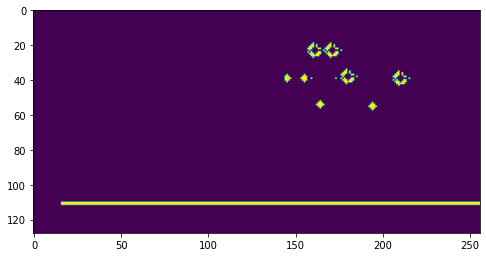

100%|██████████████████████████████████████████████████████████████████████████████████| 24/24 [00:25<00:00,  1.05s/it]

theta_x: 0.2121
theta_y: -0.0069
theta_z: 0.0199
phi: 0.0095
gamma: -0.0261
rho: -0.0014
Train Epoch: (4, 2) 	LR: 0.001000	Loss: 28.464674



  0%|                                                                                           | 0/24 [00:00<?, ?it/s]

in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0085, device='cuda:0')
tensor(0.0085, device='cuda:0')
tensor([[[  0.7943,   0.7943,   0.8199,   0.8199,   0.8199,   0.8199,   0.8199,
            0.8199,   0.8199,   0.8199,   0.8199,   0.8199,   0.8199,   0.8199,
            1.3324,   1.0591],
         [  0.9310,   0.9310,   0.8199,   1.3751,   2.1779,   1.4605,   0.4697,
            1.1445,   0.9139,   0.9310,   0.8199,   0.6576,   0.8199,   0.8199,
            1.6057,   1.3324],
         [  0.4100,   0.1367,   0.0000,   0.5552,   1.1530, -16.6718, -17.3807,
            0.6662, -17.9615, -18.7814, -17.7736, -18.3373,   0.0000,   0.0000,
            0.8199,   0.8199],
         [  0.4100,   0.1367,   0.0000,   0.5552,   1.3409, -17.8761,   1.2555,
            0.6662,   0.6576,   0.5381,   0.3246,   0.1623,   0.0000,   0.0000,
            0.8199,   0.8199],
         [  0.4100,   0.1367,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   

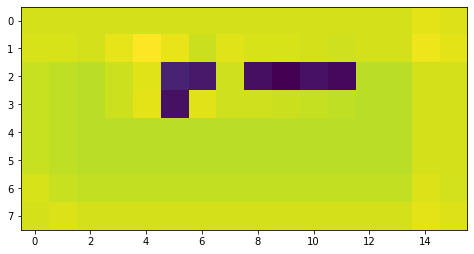

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0882, device='cuda:0')
tensor(0.0617, device='cuda:0')
tensor([[[0.0331, 0.0331, 0.0331,  ..., 0.0331, 0.0331, 0.0331],
         [0.0331, 0.0000, 0.0331,  ..., 0.0331, 0.0331, 0.0331],
         [0.0331, 0.0000, 0.0000,  ..., 0.0000, 0.0331, 0.0331],
         ...,
         [0.0165, 0.0000, 0.0000,  ..., 0.0000, 0.0331, 0.0331],
         [0.0165, 0.0165, 0.0165,  ..., 0.0331, 0.0331, 0.0331],
         [0.0165, 0.0165, 0.0165,  ..., 0.0331, 0.0331, 0.0331]]],
       device='cuda:0')


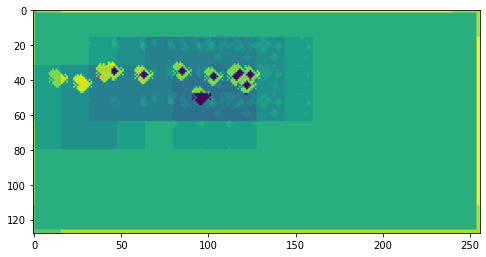

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5004, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


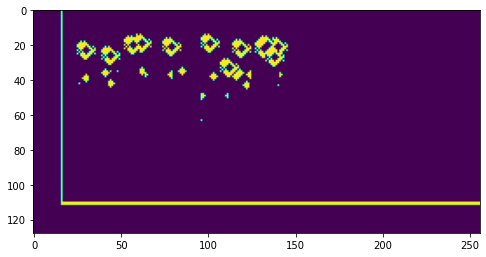

  4%|███▍                                                                               | 1/24 [00:01<00:27,  1.18s/it]

theta_x: 0.2161
theta_y: -0.0080
theta_z: 0.0209
phi: 0.0097
gamma: -0.0265
rho: -0.0015
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0075, device='cuda:0')
tensor(0.0075, device='cuda:0')
tensor([[[ 7.7288,  7.7288,  7.7288,  7.7288,  7.7288,  7.7288,  7.7288,
           7.7288,  7.7288,  7.7288,  7.7288,  7.7288,  7.7288,  7.7288,
           7.7288,  3.8644],
         [11.5932, 13.4953, 13.4877, 13.5254, 13.1933, 12.9518, 13.0122,
          13.4726, 13.5103, 13.6839, 13.5707, 13.5405, 13.5254, 13.5254,
          13.5254,  7.7288],
         [11.5932, 13.4726, 11.5329,  9.6459,  0.0000, -0.0151,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000, -0.0377, 13.5254, 13.5254,
          13.5254,  7.7288],
         [11.5932, 11.5404,  9.4648,  0.0000,  7.3062,  7.0043,  6.7627,
           6.7552,  7.1628,  5.5626,  7.5779,  0.0000, 13.5254, 13.5254,
          13.5254,  7.7288],
         [11.5932, 11.5706,  7.7062,  5.8344,  0.0000,  7.7892,  7.7288,
           7.7288,  7.7364,  5.872

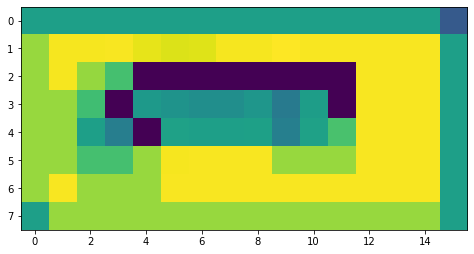

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0804, device='cuda:0')
tensor(0.0563, device='cuda:0')
tensor([[[0.0322, 0.0322, 0.0322,  ..., 0.0322, 0.0322, 0.0322],
         [0.0322, 0.0322, 0.0322,  ..., 0.0322, 0.0322, 0.0322],
         [0.0322, 0.0322, 0.0322,  ..., 0.0322, 0.0322, 0.0322],
         ...,
         [0.0161, 0.0161, 0.0161,  ..., 0.0322, 0.0322, 0.0322],
         [0.0161, 0.0161, 0.0161,  ..., 0.0322, 0.0322, 0.0322],
         [0.0161, 0.0161, 0.0161,  ..., 0.0322, 0.0322, 0.0322]]],
       device='cuda:0')


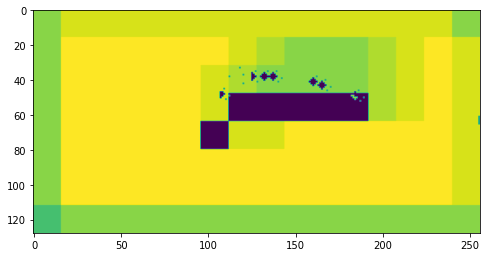

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5005, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


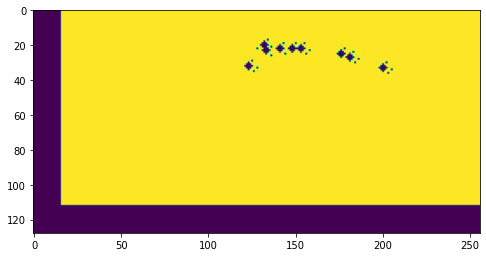

  8%|██████▉                                                                            | 2/24 [00:02<00:25,  1.16s/it]

theta_x: 0.2177
theta_y: -0.0116
theta_z: 0.0205
phi: 0.0098
gamma: -0.0269
rho: -0.0014
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0081, device='cuda:0')
tensor(0.0081, device='cuda:0')
tensor([[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  8.0592e-03,  8.0592e-03,
           8.0592e-03,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 8.0592e-03,  8.0592e-03,  0.0000e+00,  8.0592e-03, -8.0592e-03,
           8.0592e-03, -1.8262e+01, -1.8407e+01, -1.8036e+01, -1.8367e+01,
          -1.8536e+01, -1.8552e+01,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 8.0592e-03, -8.0592e-03,  0.0000e+00, -1.8488e+01

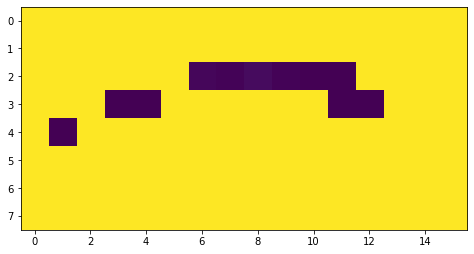

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0843, device='cuda:0')
tensor(0.0506, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


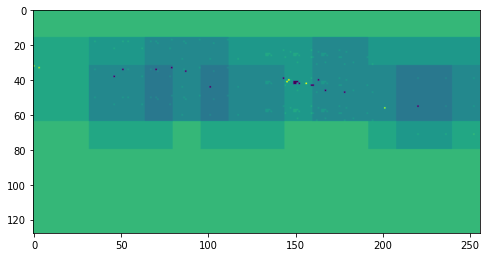

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5001, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


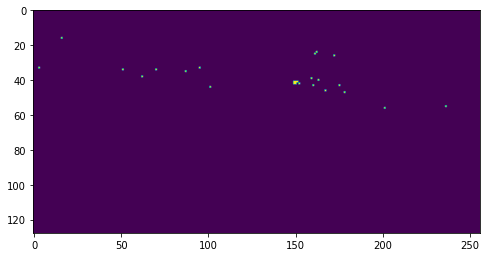

 12%|██████████▍                                                                        | 3/24 [00:03<00:23,  1.11s/it]

theta_x: 0.2178
theta_y: -0.0116
theta_z: 0.0206
phi: 0.0098
gamma: -0.0269
rho: -0.0014
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0080, device='cuda:0')
tensor(0.0080, device='cuda:0')
tensor([[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 3.2074e-02,  3.2074e-02,  1.6037e-02,  0.0000e+00,  0.0000e+00,
           1.2028e-01,  1.2028e-01,  5.6130e-02,  0.0000e+00,  8.0185e-03,
           1.6037e-02,  8.0185e-03,  0.0000e+00, -8.0185e-03,  0.0000e+00,
           0.0000e+00],
         [ 8.8204e-02,  8.8204e-02,  9.6222e-02,  8.0185e-03, -8.0185e-03,
           1.2028e-01, -5.6130e-02, -1.7697e+01,  0.0000e+00,  8.0185e-03,
           6.4148e-02, -1.7304e+01, -1.7553e+01, -1.8298e+01,  8.0185e-02,
          -1.8322e+01],
         [ 1.6839e-01,  8.0185e-03, -1.8202e+01,  8.0185e-03

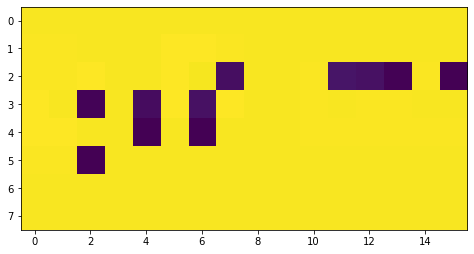

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0914, device='cuda:0')
tensor(0.0629, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


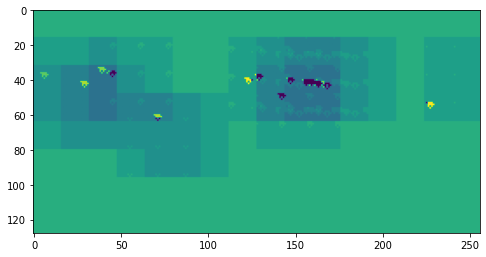

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5002, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


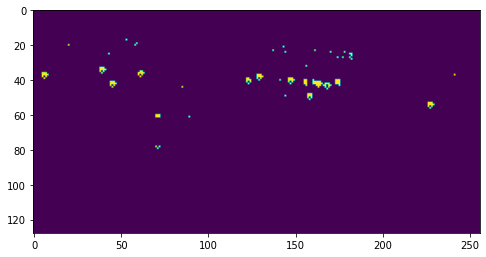

 17%|█████████████▊                                                                     | 4/24 [00:04<00:21,  1.09s/it]

theta_x: 0.2202
theta_y: -0.0137
theta_z: 0.0219
phi: 0.0100
gamma: -0.0273
rho: -0.0013
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0087, device='cuda:0')
tensor(0.0087, device='cuda:0')
tensor([[[ 0.0000e+00,  2.6110e-02,  2.6110e-02, -2.6110e-02,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 1.7407e-01,  2.1759e-01,  9.5738e-02,  8.7035e-03,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  3.4814e-02,
          -1.9330e+01,  0.0000e+00, -3.4814e-02,  1.7407e-02,  3.4814e-02,
           0.0000e+00],
         [ 1.7407e-01, -8.7034e-03, -1.7929e+01, -1.9722e+01,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  3.4814e-02,
          -1.7807e+01, -1.8826e+01, -1.9905e+01,  3.4814e-02,  1.4796e-01,
          -7.8331e-02],
         [ 1.7407e-01,  1.9148e-01,  1.9148e-01,  1.7407e-02

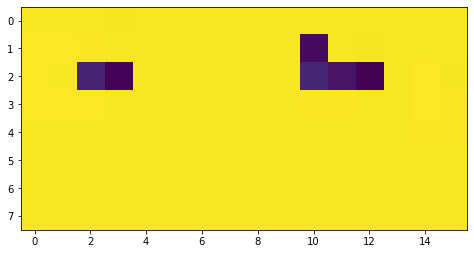

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0914, device='cuda:0')
tensor(0.0609, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


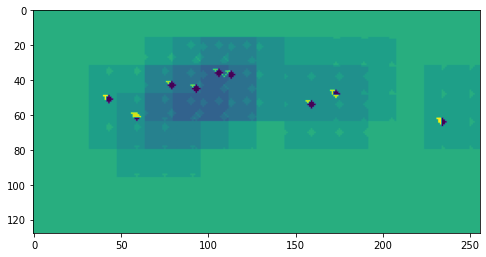

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5003, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


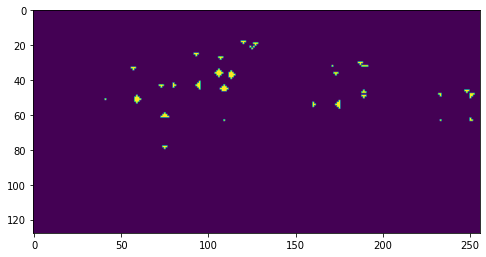

 21%|█████████████████▎                                                                 | 5/24 [00:05<00:20,  1.10s/it]

theta_x: 0.2252
theta_y: -0.0138
theta_z: 0.0225
phi: 0.0101
gamma: -0.0278
rho: -0.0013
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0073, device='cuda:0')
tensor(0.0073, device='cuda:0')
tensor([[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 3.6333e-02,  2.1800e-02,  1.0173e-01,  2.6886e-01,  2.1073e-01,
           2.3980e-01,  4.5053e-01,  3.6333e-01,  5.0866e-02,  7.2666e-03,
          -1.2353e-01, -2.9066e-02,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 1.1626e-01,  1.2353e-01,  1.5986e-01,  3.5606e-01,  4.2146e-01,
          -1.4402e+01,  3.1973e-01, -1.3588e+01, -1.3894e+01, -1.4119e+01,
          -1.5180e+01, -1.6037e+01, -3.6333e-02, -2.9066e-02,  0.0000e+00,
           0.0000e+00],
         [ 5.8132e-02, -1.6510e+01, -1.5587e+01,  2.1073e-01

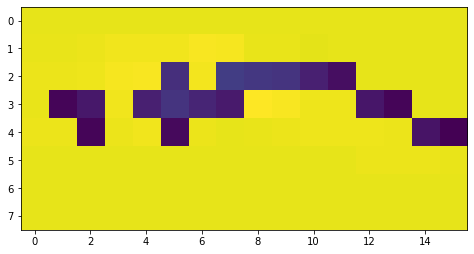

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0914, device='cuda:0')
tensor(0.0578, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


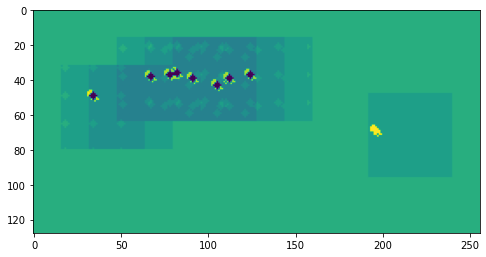

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5004, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


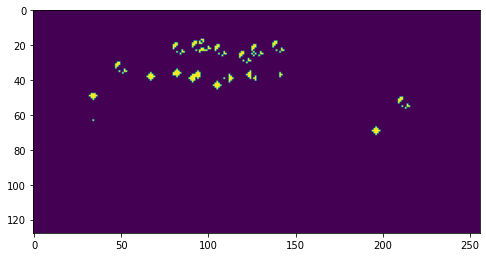

 25%|████████████████████▊                                                              | 6/24 [00:06<00:19,  1.09s/it]

theta_x: 0.2298
theta_y: -0.0123
theta_z: 0.0211
phi: 0.0103
gamma: -0.0282
rho: -0.0013
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0088, device='cuda:0')
tensor(0.0088, device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.3618,   0.8208,   0.9355,
            0.2471,  -0.5119,  -0.0971,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.3618,   0.5913, -16.5033,
          -16.2386, -18.1978, -20.1570,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.3618,   0.8208, -18.2949,
            1.1649,   0.7060,   0.0971,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0

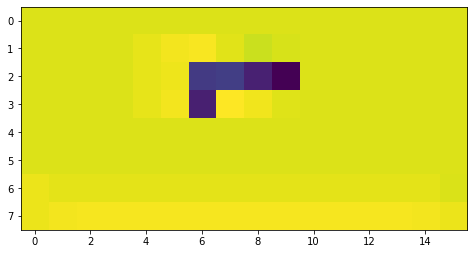

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0912, device='cuda:0')
tensor(0.0555, device='cuda:0')
tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0171,  ..., 0.0342, 0.0342, 0.0000],
         [0.0171, 0.0171, 0.0171,  ..., 0.0342, 0.0000, 0.0000]]],
       device='cuda:0')


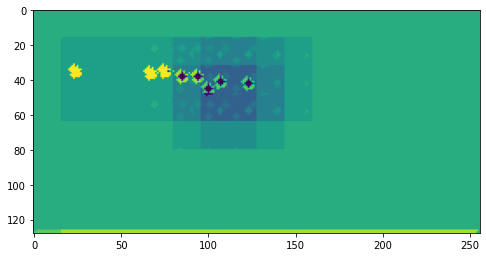

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5004, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


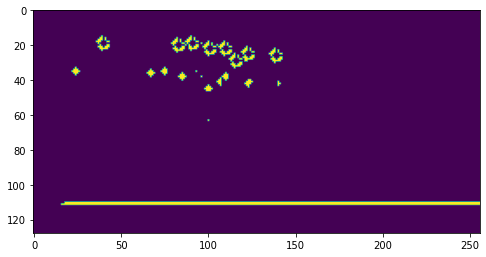

theta_x: 0.2326
theta_y: -0.0140
theta_z: 0.0229
phi: 0.0105
gamma: -0.0289
rho: -0.0013


 29%|████████████████████████▏                                                          | 7/24 [00:07<00:19,  1.12s/it]

in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0084, device='cuda:0')
tensor(0.0084, device='cuda:0')
tensor([[[  0.5213,   0.3868,   0.4036,   0.4036,   0.4036,   0.4036,   0.4036,
            0.4036,   0.4036,   0.4036,   0.4036,   0.4036,   0.4036,   0.4036,
            0.9250,   0.7904],
         [  0.6559,   1.0259,   0.9334,   0.0757,   0.5802,   1.1520,   1.1941,
            0.9166,   0.5718,  -0.2102,   0.4036,   0.4036,   0.4036,   0.4036,
            1.1941,   1.0595],
         [  0.4036,   0.6391,   0.4877, -17.9696,   0.1177,   0.7484, -15.1611,
          -15.2788, -16.3131, -18.3901,   0.0000,   0.0000,   0.0000,   0.0000,
            0.8072,   0.8072],
         [  0.4036,   0.6979,   0.9334,   0.8157,   0.1009,   0.7484, -16.7335,
            1.6061,   1.0595,   0.6138,   0.0000,   0.0000,   0.0000,   0.0000,
            0.8072,   0.8072],
         [  0.4036,   0.1934,   0.4036, -17.9360,   0.3448,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   

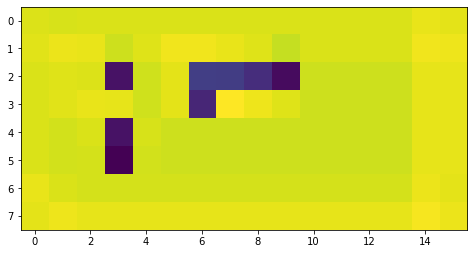

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0868, device='cuda:0')
tensor(0.0582, device='cuda:0')
tensor([[[0.0336, 0.0000, 0.0336,  ..., 0.0336, 0.0336, 0.0336],
         [0.0336, 0.0000, 0.0000,  ..., 0.0000, 0.0336, 0.0336],
         [0.0336, 0.0000, 0.0000,  ..., 0.0000, 0.0336, 0.0336],
         ...,
         [0.0168, 0.0000, 0.0000,  ..., 0.0000, 0.0336, 0.0336],
         [0.0168, 0.0168, 0.0168,  ..., 0.0336, 0.0336, 0.0336],
         [0.0168, 0.0168, 0.0168,  ..., 0.0336, 0.0336, 0.0336]]],
       device='cuda:0')


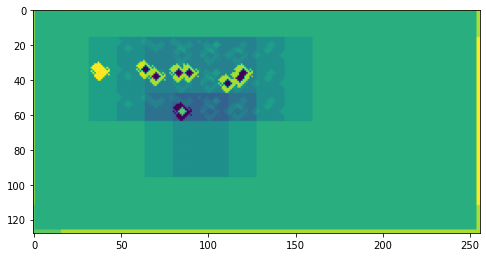

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5004, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


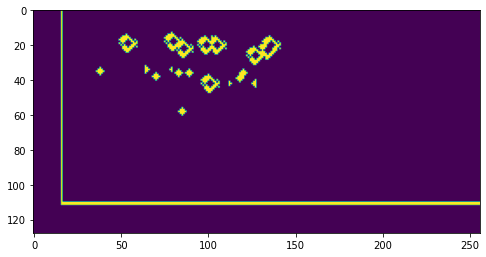

 33%|███████████████████████████▋                                                       | 8/24 [00:08<00:17,  1.12s/it]

theta_x: 0.2346
theta_y: -0.0131
theta_z: 0.0218
phi: 0.0106
gamma: -0.0292
rho: -0.0014
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0079, device='cuda:0')
tensor(0.0079, device='cuda:0')
tensor([[[ 8.1237,  8.1237,  8.1237,  8.1237,  8.1237,  8.1237,  8.1237,
           8.1237,  8.1237,  8.1237,  8.1237,  8.1237,  8.1237,  8.1237,
           8.1237,  4.0618],
         [12.1855, 14.2165, 14.2085, 14.1451, 14.0737, 14.1054, 12.1855,
          12.7012, -0.0714, 14.2323, 14.2165, 14.2165, 14.2165, 14.2165,
          14.2165,  8.1237],
         [12.1855, 14.1927, 14.2244, 12.2569, 12.0427, -0.0159,  7.5128,
           0.0000,  0.0000, 14.2006, 14.2165, 14.2165, 14.2165, 14.2165,
          14.2165,  8.1237],
         [12.1855, 14.1927, 11.9237,  8.0047,  0.0000,  0.0000,  7.9412,
           8.0206, 10.1387, 14.2006, 14.2165, 14.2165, 14.2165, 14.2165,
          14.2165,  8.1237],
         [10.1546, 12.1617,  0.0000,  8.0761,  8.0920,  8.1158, 10.1467,
          10.1546, 12.1855, 14.216

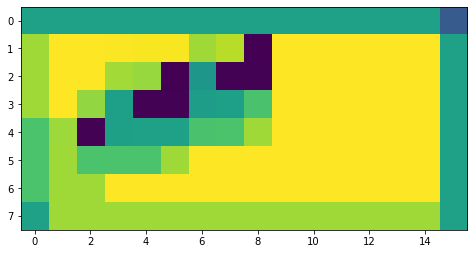

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0825, device='cuda:0')
tensor(0.0578, device='cuda:0')
tensor([[[0.0309, 0.0309, 0.0309,  ..., 0.0309, 0.0309, 0.0309],
         [0.0309, 0.0309, 0.0309,  ..., 0.0309, 0.0309, 0.0309],
         [0.0309, 0.0309, 0.0309,  ..., 0.0309, 0.0309, 0.0309],
         ...,
         [0.0155, 0.0155, 0.0155,  ..., 0.0309, 0.0309, 0.0309],
         [0.0155, 0.0155, 0.0155,  ..., 0.0309, 0.0309, 0.0309],
         [0.0155, 0.0155, 0.0155,  ..., 0.0309, 0.0309, 0.0309]]],
       device='cuda:0')


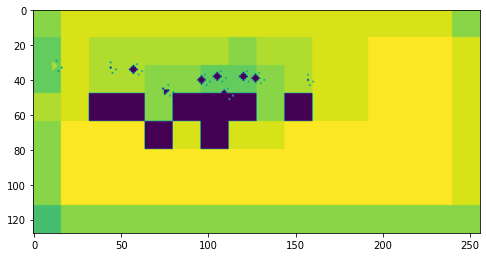

tensor(-0.2503, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5005, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


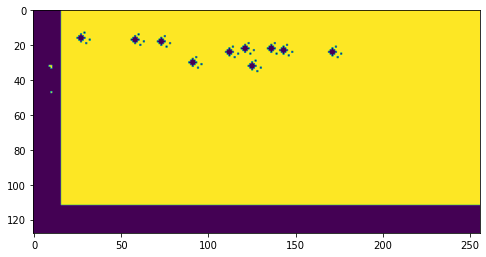

 38%|███████████████████████████████▏                                                   | 9/24 [00:10<00:17,  1.16s/it]

theta_x: 0.2356
theta_y: -0.0109
theta_z: 0.0219
phi: 0.0106
gamma: -0.0295
rho: -0.0016
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0087, device='cuda:0')
tensor(0.0087, device='cuda:0')
tensor([[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           1.7410e-02,  2.6115e-02,  8.7051e-03, -8.7051e-03,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           1.7410e-02,  8.7051e-03, -1.8942e+01, -1.9778e+01, -1.9900e+01,
          -2.0039e+01,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00

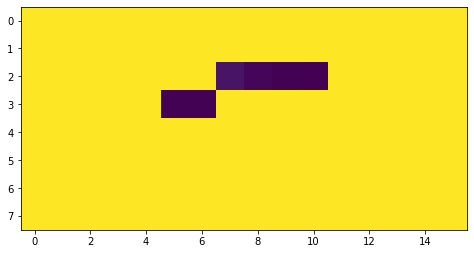

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0871, device='cuda:0')
tensor(0.0496, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


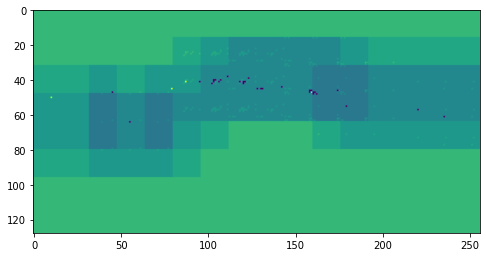

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5001, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


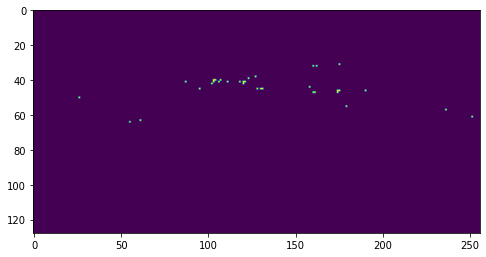

 42%|██████████████████████████████████▏                                               | 10/24 [00:11<00:16,  1.16s/it]

theta_x: 0.2357
theta_y: -0.0109
theta_z: 0.0219
phi: 0.0106
gamma: -0.0296
rho: -0.0016
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0090, device='cuda:0')
tensor(0.0090, device='cuda:0')
tensor([[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  6.2944e-02,  6.2944e-02,  8.9919e-02,
           5.3952e-02,  4.4960e-02,  0.0000e+00, -8.9919e-03,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  6.2944e-02, -4.4960e-02, -2.0592e+01,
           5.3952e-02, -8.9919e-03, -1.9800e+01, -2.0574e+01,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  6.2944e-02,  6.2944e-02

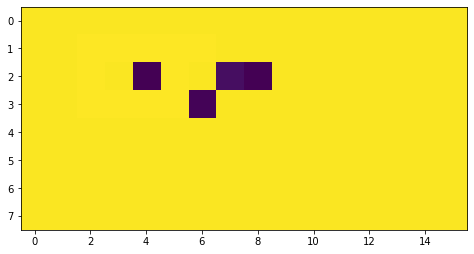

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0899, device='cuda:0')
tensor(0.0540, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


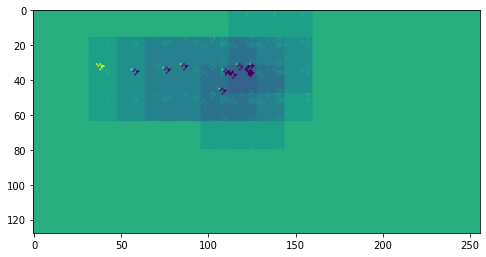

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5002, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


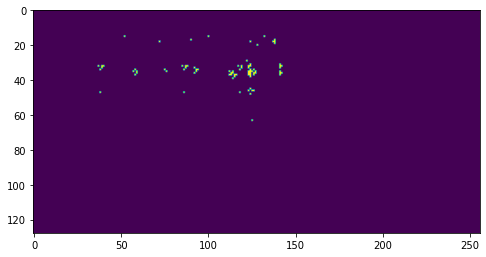

 46%|█████████████████████████████████████▌                                            | 11/24 [00:12<00:14,  1.13s/it]

theta_x: 0.2361
theta_y: -0.0116
theta_z: 0.0227
phi: 0.0107
gamma: -0.0299
rho: -0.0016
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0087, device='cuda:0')
tensor(0.0087, device='cuda:0')
tensor([[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  1.3056e-01,
           2.2630e-01,  2.5241e-01,  8.7040e-03, -8.7040e-02, -8.7040e-03,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 1.2186e-01,  1.1315e-01,  8.7040e-02,  0.0000e+00,  1.3926e-01,
           3.4816e-02, -1.7295e+01, -1.7077e+01, -1.8748e+01, -1.9949e+01,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 1.2186e-01, -2.6112e-02,  8.7040e-02,  0.0000e+00

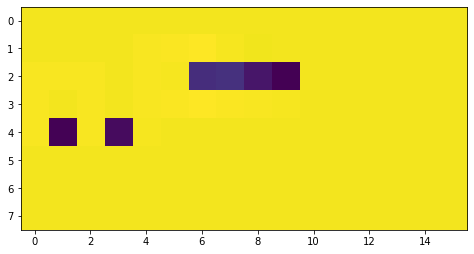

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0899, device='cuda:0')
tensor(0.0540, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


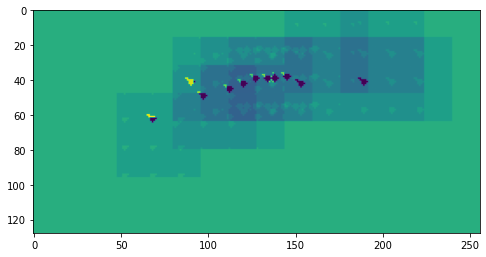

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5003, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


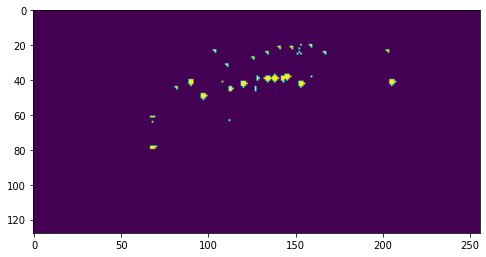

 50%|█████████████████████████████████████████                                         | 12/24 [00:13<00:13,  1.10s/it]

theta_x: 0.2389
theta_y: -0.0113
theta_z: 0.0230
phi: 0.0108
gamma: -0.0301
rho: -0.0016
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0082, device='cuda:0')
tensor(0.0082, device='cuda:0')
tensor([[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 0.0000e+00,  4.0901e-02,  8.9982e-02,  8.1802e-03, -4.9081e-02,
           0.0000e+00,  1.6360e-01,  1.6360e-01, -9.8163e-02, -1.7260e+01,
          -1.6655e+01,  8.9982e-02, -1.7996e+01,  8.1802e-02, -1.6360e-02,
           0.0000e+00],
         [ 0.0000e+00,  4.0901e-02,  8.9982e-02, -1.7800e+01, -1.8700e+01,
           0.0000e+00,  1.6360e-01,  9.8163e-02, -1.6516e+01, -1.6140e+01,
          -1.7915e+01, -8.9982e-02, -1.8471e+01, -5.7262e-02, -1.8324e+01,
           0.0000e+00],
         [ 0.0000e+00,  4.0901e-02,  8.9982e-02,  8.9982e-02

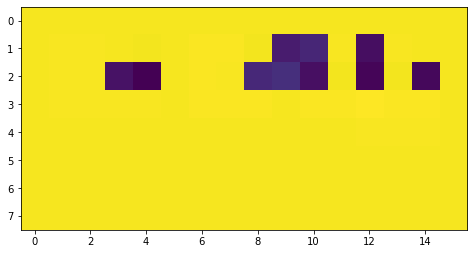

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0899, device='cuda:0')
tensor(0.0616, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


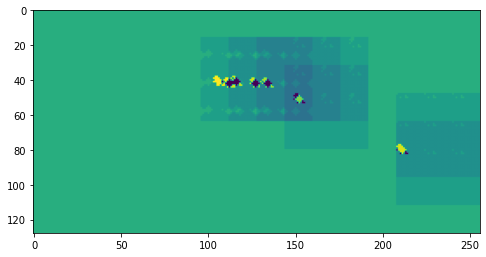

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5003, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


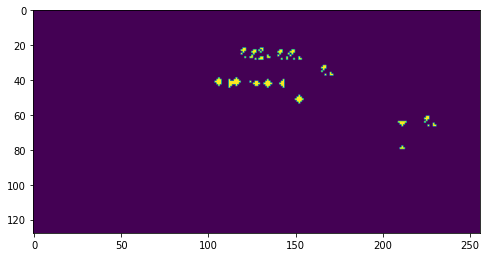

 54%|████████████████████████████████████████████▍                                     | 13/24 [00:14<00:11,  1.09s/it]

theta_x: 0.2430
theta_y: -0.0101
theta_z: 0.0211
phi: 0.0110
gamma: -0.0306
rho: -0.0016
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0082, device='cuda:0')
tensor(0.0082, device='cuda:0')
tensor([[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  1.1453e-01,  1.9635e-01,
           2.6998e-01,  5.1541e-01,  1.8816e-01, -2.9452e-01, -1.3613e+01,
          -1.4570e+01, -3.0270e-01, -5.7267e-02,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  1.1453e-01,  1.9635e-01,
          -1.7377e+01,  4.8268e-01, -1.6550e+01, -1.5438e+01, -1.3891e+01,
          -1.4832e+01, -1.7368e+01,  5.7267e-02,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  1.1453e-01

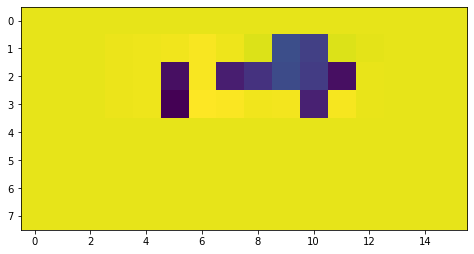

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0884, device='cuda:0')
tensor(0.0540, device='cuda:0')
tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0332, 0.0000],
         [0.0000, 0.0166, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],
       device='cuda:0')


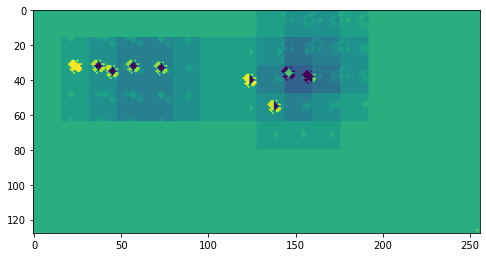

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5004, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


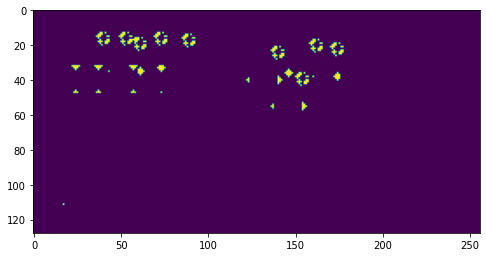

 58%|███████████████████████████████████████████████▊                                  | 14/24 [00:15<00:10,  1.08s/it]

theta_x: 0.2472
theta_y: -0.0105
theta_z: 0.0214
phi: 0.0113
gamma: -0.0311
rho: -0.0016
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0075, device='cuda:0')
tensor(0.0075, device='cuda:0')
tensor([[[ 1.4978e-02,  1.4978e-02,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  1.4978e-02,
           1.4978e-02],
         [ 7.4892e-02,  7.4892e-02,  0.0000e+00,  4.3437e-01,  4.1190e-01,
          -2.7710e-01, -9.7359e-02,  3.0706e-01,  3.0706e-01, -1.4978e-01,
           5.9913e-02, -1.4978e-02, -2.2467e-02,  0.0000e+00,  1.4978e-02,
           1.4978e-02],
         [ 3.2203e-01,  2.7710e-01, -1.1983e-01,  5.3173e-01, -1.5293e+01,
          -1.2567e+01,  4.5684e-01,  1.7974e-01,  2.9208e-01, -1.3563e+01,
           1.3480e-01, -1.5158e+01, -1.4664e+01, -1.4095e+01, -1.3922e+01,
           4.1939e-01],
         [ 3.2203e-01, -1.6057e+01,  3.5948e-01,  5.3173e-01

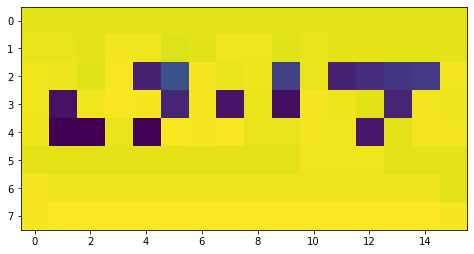

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0944, device='cuda:0')
tensor(0.0566, device='cuda:0')
tensor([[[0.0304, 0.0000, 0.0000,  ..., 0.0000, 0.0304, 0.0304],
         [0.0304, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0152, 0.0152, 0.0152,  ..., 0.0304, 0.0304, 0.0304],
         [0.0152, 0.0152, 0.0152,  ..., 0.0304, 0.0304, 0.0304]]],
       device='cuda:0')


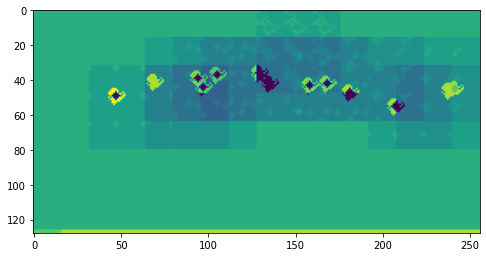

tensor(-0.2503, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5005, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


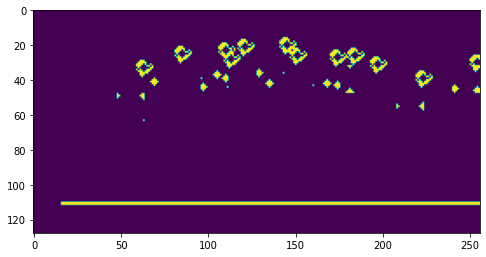

 62%|███████████████████████████████████████████████████▎                              | 15/24 [00:16<00:09,  1.10s/it]

theta_x: 0.2504
theta_y: -0.0102
theta_z: 0.0213
phi: 0.0115
gamma: -0.0316
rho: -0.0017
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0075, device='cuda:0')
tensor(0.0075, device='cuda:0')
tensor([[[ 7.7302e+00,  7.7302e+00,  7.7302e+00,  7.7302e+00,  7.7302e+00,
           7.7302e+00,  7.7226e+00,  7.7226e+00,  7.7377e+00,  7.7302e+00,
           7.7302e+00,  7.7302e+00,  7.7302e+00,  7.7302e+00,  7.7302e+00,
           3.8651e+00],
         [ 1.1595e+01,  1.3528e+01,  1.3528e+01,  1.3422e+01,  1.3218e+01,
           1.3218e+01,  1.3037e+01,  1.3316e+01,  1.3135e+01,  1.3520e+01,
           1.3852e+01,  1.3535e+01,  1.3528e+01,  1.3528e+01,  1.3528e+01,
           7.7302e+00],
         [ 1.1595e+01,  1.3528e+01,  1.3528e+01,  1.1490e+01,  9.1570e+00,
           0.0000e+00,  0.0000e+00, -7.5490e-03,  0.0000e+00,  0.0000e+00,
          -7.5490e-03, -3.7745e-02,  1.3528e+01,  1.3528e+01,  1.3528e+01,
           7.7302e+00],
         [ 1.1595e+01,  1.3528e+01,  1.3528e+01,  9.5570e+00

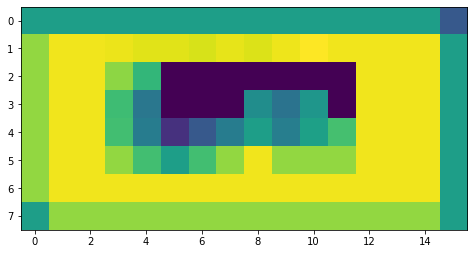

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0837, device='cuda:0')
tensor(0.0586, device='cuda:0')
tensor([[[0.0313, 0.0313, 0.0313,  ..., 0.0313, 0.0313, 0.0313],
         [0.0313, 0.0313, 0.0313,  ..., 0.0313, 0.0313, 0.0313],
         [0.0313, 0.0313, 0.0313,  ..., 0.0313, 0.0313, 0.0313],
         ...,
         [0.0157, 0.0157, 0.0157,  ..., 0.0313, 0.0313, 0.0313],
         [0.0157, 0.0157, 0.0157,  ..., 0.0313, 0.0313, 0.0313],
         [0.0157, 0.0157, 0.0157,  ..., 0.0313, 0.0313, 0.0313]]],
       device='cuda:0')


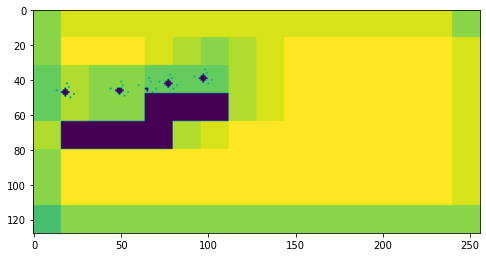

tensor(-0.2503, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5005, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


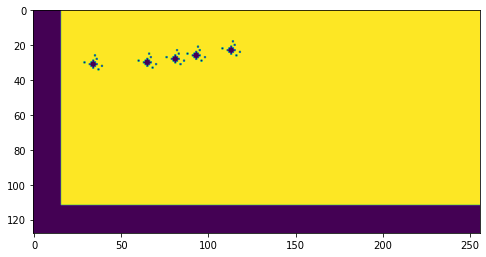

theta_x: 0.2534
theta_y: -0.0122
theta_z: 0.0225
phi: 0.0117
gamma: -0.0320
rho: -0.0017


 67%|██████████████████████████████████████████████████████▋                           | 16/24 [00:17<00:08,  1.11s/it]

in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0079, device='cuda:0')
tensor(0.0079, device='cuda:0')
tensor([[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 5.5588e-02,  3.9705e-02,  2.3823e-02,  3.9705e-02,  2.3823e-02,
           0.0000e+00,  3.9705e-02,  3.9705e-02,  6.3529e-02,  4.7647e-02,
           3.1764e-02, -7.9411e-03,  7.9411e-03,  7.9411e-03, -7.9411e-03,
           0.0000e+00],
         [ 5.5588e-02, -1.7923e+01, -1.7923e+01, -2.3823e-02,  3.9705e-02,
           0.0000e+00,  3.9705e-02, -1.5882e-02, -1.8161e+01, -2.3823e-02,
          -1.8050e+01, -1.8042e+01,  3.9705e-02, -2.3823e-02, -1.8257e+01,
           0.0000e+00],
         [ 5.5588e-02, -1.8177e+01, -1.8177e+01, -1.8257e+01, -1.8257e+01,
           0.0000e+00,  3.9705e-02,  4.7647e-02, -1.7915e+01,  5.5588e-02,

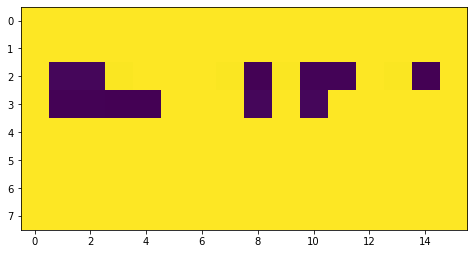

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0870, device='cuda:0')
tensor(0.0581, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


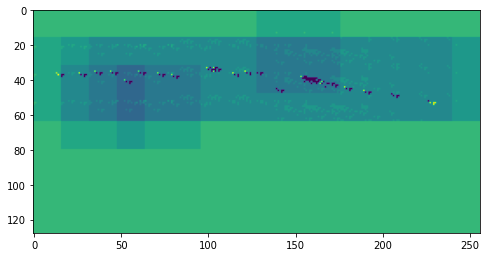

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5002, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


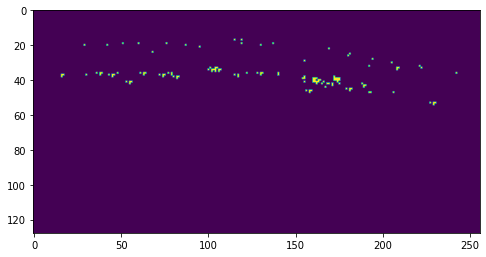

 71%|██████████████████████████████████████████████████████████                        | 17/24 [00:18<00:07,  1.11s/it]

theta_x: 0.2540
theta_y: -0.0131
theta_z: 0.0226
phi: 0.0117
gamma: -0.0322
rho: -0.0017
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0083, device='cuda:0')
tensor(0.0083, device='cuda:0')
tensor([[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  1.4875e-01,  1.4875e-01,  8.2637e-02,  8.2637e-03,
          -1.8585e+01,  0.0000e+00, -8.2637e-03,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           8.2637e-03,  1.5701e-01, -9.0901e-02, -1.8221e+01, -1.7932e+01,
          -1.7180e+01, -1.8073e+01, -1.8676e+01,  9.9164e-02,  9.9164e-02,
           8.2637e-02],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00

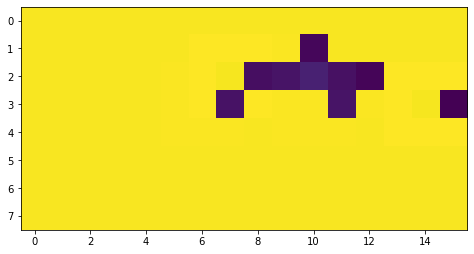

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0899, device='cuda:0')
tensor(0.0539, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


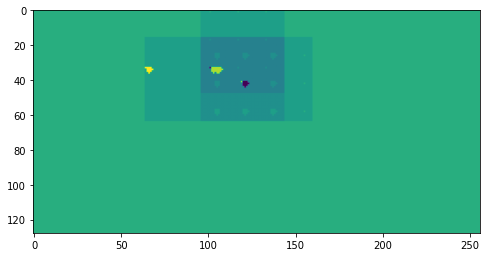

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5002, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


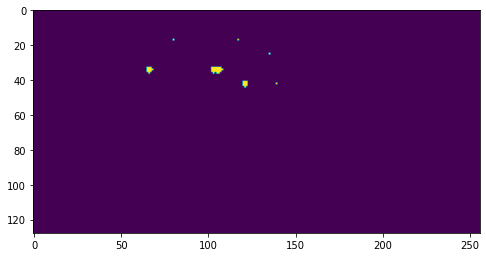

 75%|█████████████████████████████████████████████████████████████▌                    | 18/24 [00:19<00:06,  1.10s/it]

theta_x: 0.2563
theta_y: -0.0131
theta_z: 0.0231
phi: 0.0119
gamma: -0.0326
rho: -0.0018
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0086, device='cuda:0')
tensor(0.0086, device='cuda:0')
tensor([[[  0.0000,   0.0000,   0.0000,   0.0257,   0.0685,   0.2570,   0.1971,
            0.0343,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0257,   0.1371,   0.1628,   0.2570,   0.0942,
          -17.7519,  -0.1199,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0257,   0.1371, -18.1545, -15.9441, -16.4924,
          -17.1179, -19.3283,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0257,   0.1114,   0.1456, -18.8999,   0.1542,
            0.1199,   0.1199,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0

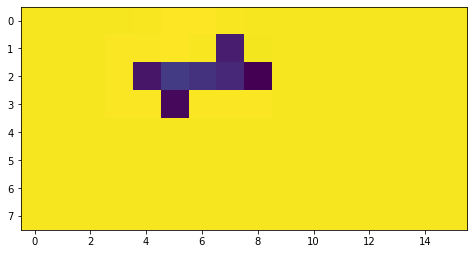

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0884, device='cuda:0')
tensor(0.0548, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


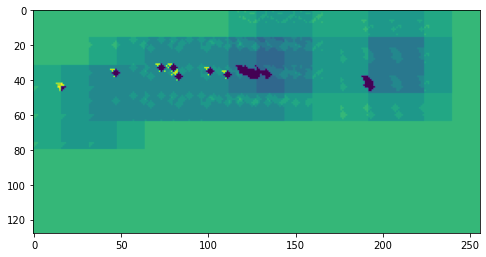

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5003, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


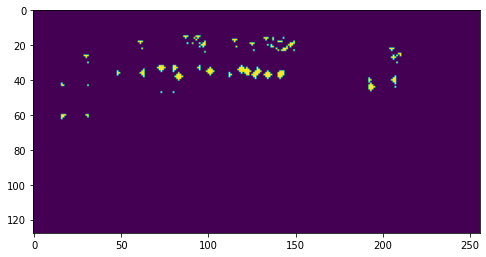

 79%|████████████████████████████████████████████████████████████████▉                 | 19/24 [00:21<00:05,  1.11s/it]

theta_x: 0.2548
theta_y: -0.0108
theta_z: 0.0210
phi: 0.0119
gamma: -0.0328
rho: -0.0018
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0076, device='cuda:0')
tensor(0.0076, device='cuda:0')
tensor([[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 1.5285e-02,  1.5285e-02, -1.5285e-02,  1.3756e-01,  4.3561e-01,
           5.3496e-01,  6.1138e-02, -2.6748e-01, -1.4329e+01,  3.8211e-02,
          -1.2992e-01,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 2.0634e-01,  2.0634e-01, -3.8211e-02,  1.3756e-01,  4.2033e-01,
          -1.4077e+01, -1.4559e+01, -1.4154e+01, -1.6599e+01, -1.5361e+01,
          -1.6836e+01, -1.6034e+01, -1.3756e-01,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 2.0634e-01,  6.8781e-02, -1.7126e+01,  1.3756e-01

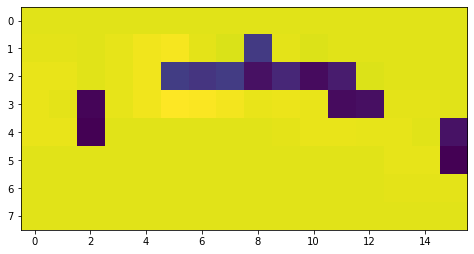

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0899, device='cuda:0')
tensor(0.0616, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


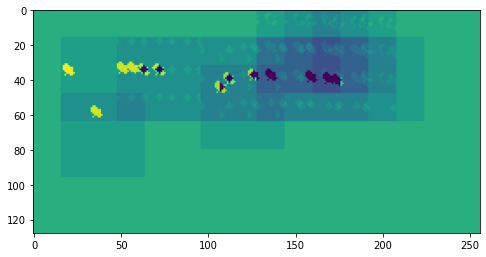

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5004, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


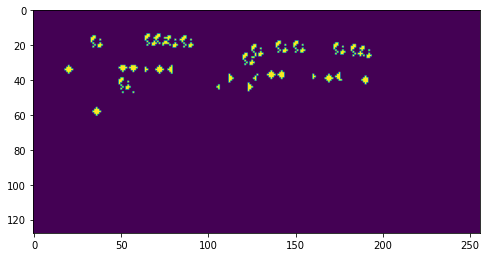

 83%|████████████████████████████████████████████████████████████████████▎             | 20/24 [00:22<00:04,  1.10s/it]

theta_x: 0.2583
theta_y: -0.0091
theta_z: 0.0210
phi: 0.0122
gamma: -0.0333
rho: -0.0019
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0083, device='cuda:0')
tensor(0.0083, device='cuda:0')
tensor([[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  8.2937e-03,  1.6587e-02,
           0.0000e+00, -8.2937e-03,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  3.5663e-01,  8.4596e-01,
           7.7961e-01,  5.3909e-01,  3.2345e-01, -4.2298e-01, -1.4099e-01,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  1.0782e-01,  4.6445e-01,  5.3080e-01,
          -1.5542e+01, -1.4298e+01, -1.4373e+01, -1.5932e+01, -1.7699e+01,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  2.4881e-01,  5.9714e-01

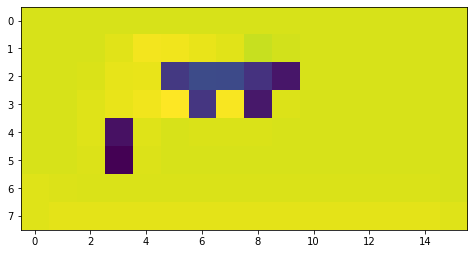

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0898, device='cuda:0')
tensor(0.0572, device='cuda:0')
tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0342, 0.0000],
         [0.0000, 0.0171, 0.0171,  ..., 0.0342, 0.0000, 0.0000]]],
       device='cuda:0')


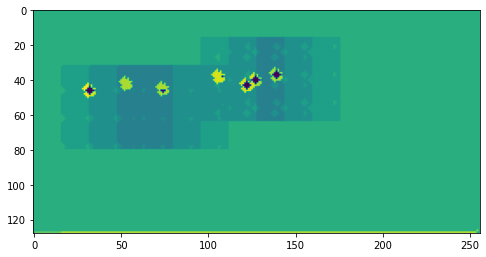

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5004, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


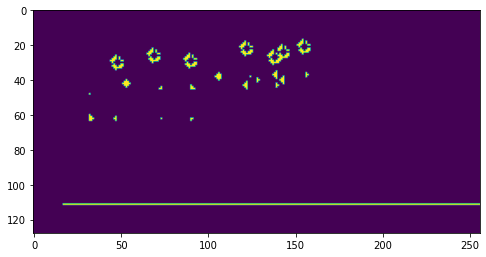

 88%|███████████████████████████████████████████████████████████████████████▊          | 21/24 [00:23<00:03,  1.09s/it]

theta_x: 0.2586
theta_y: -0.0051
theta_z: 0.0200
phi: 0.0123
gamma: -0.0336
rho: -0.0021
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0082, device='cuda:0')
tensor(0.0082, device='cuda:0')
tensor([[[ 1.6486e-02,  1.6486e-02,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  2.4729e-02,
           2.4729e-02],
         [ 1.6486e-02,  1.6486e-02,  0.0000e+00,  0.0000e+00,  5.6053e-01,
           9.8918e-01,  2.4729e-01, -8.2431e-02,  2.1432e-01, -1.6569e+01,
          -5.6053e-01,  0.0000e+00,  0.0000e+00,  0.0000e+00,  2.4729e-02,
           2.4729e-02],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  5.6053e-01,
          -1.6668e+01, -1.5406e+01, -1.6033e+01, -1.7475e+01, -1.5950e+01,
          -1.8209e+01,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 4.8634e-01, -2.7202e-01,  0.0000e+00,  0.0000e+00

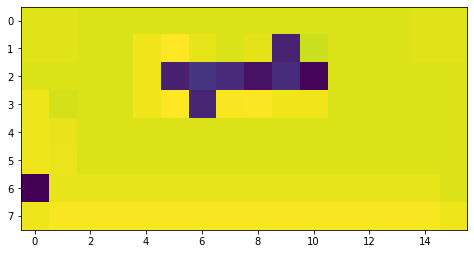

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0882, device='cuda:0')
tensor(0.0552, device='cuda:0')
tensor([[[0.0315, 0.0000, 0.0000,  ..., 0.0000, 0.0315, 0.0315],
         [0.0315, 0.0000, 0.0000,  ..., 0.0000, 0.0315, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0158, 0.0158, 0.0158,  ..., 0.0315, 0.0315, 0.0315],
         [0.0158, 0.0158, 0.0158,  ..., 0.0315, 0.0315, 0.0315]]],
       device='cuda:0')


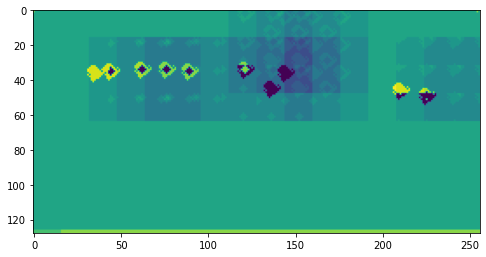

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5005, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


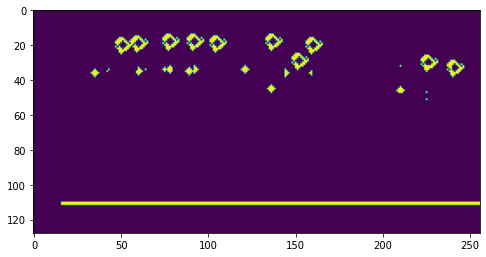

theta_x: 0.2600
theta_y: -0.0037
theta_z: 0.0198
phi: 0.0124
gamma: -0.0338
rho: -0.0022


 92%|███████████████████████████████████████████████████████████████████████████▏      | 22/24 [00:24<00:02,  1.12s/it]

in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0072, device='cuda:0')
tensor(0.0072, device='cuda:0')
tensor([[[ 7.4149,  7.4149,  7.4149,  7.4076,  7.4076,  7.4221,  7.4149,
           7.4076,  7.4076,  7.4221,  7.4149,  7.4149,  7.4149,  7.4149,
           7.4149,  3.7074],
         [11.0716, 13.1860, 12.9905, 12.9254, 12.9254, 13.2005, 12.9543,
          11.0934, 10.9920, -0.0797, 11.1223, 11.2092, -0.0507, 13.0267,
          12.9833,  7.4149],
         [ 9.2179, -0.0507,  0.0000, 11.0716, 10.8834,  0.0000, 11.1006,
           7.3859,  0.0000,  0.0000,  0.0000,  0.0000, -0.0217, -0.0434,
          -0.0290, -0.0579],
         [ 9.2179, -0.0507, 11.1078, 11.0789, 11.0789, 11.0789, 11.1006,
           7.3932,  5.3946,  5.2715,  5.2715,  5.3657,  5.5539,  7.4221,
           9.1962,  5.5612],
         [ 9.2686, 11.1223, 11.1223, 11.1223, 11.1223, 11.1223, 11.1223,
           9.2686,  7.4149,  7.4149,  7.4149,  7.4221,  7.4873,  7.4873,
           9.3338,  5.5612],
         [11.1223, 12

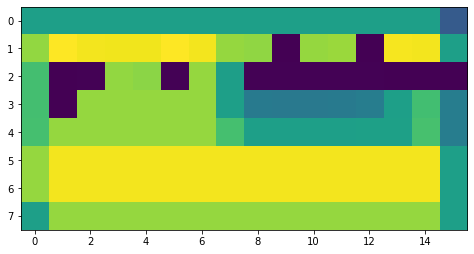

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0815, device='cuda:0')
tensor(0.0570, device='cuda:0')
tensor([[[0.0287, 0.0287, 0.0287,  ..., 0.0287, 0.0287, 0.0287],
         [0.0287, 0.0287, 0.0287,  ..., 0.0287, 0.0287, 0.0287],
         [0.0287, 0.0287, 0.0287,  ..., 0.0287, 0.0287, 0.0287],
         ...,
         [0.0144, 0.0144, 0.0144,  ..., 0.0287, 0.0287, 0.0287],
         [0.0144, 0.0144, 0.0144,  ..., 0.0287, 0.0287, 0.0287],
         [0.0144, 0.0144, 0.0144,  ..., 0.0287, 0.0287, 0.0287]]],
       device='cuda:0')


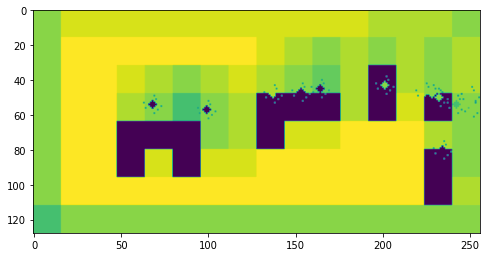

tensor(-0.2503, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5005, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


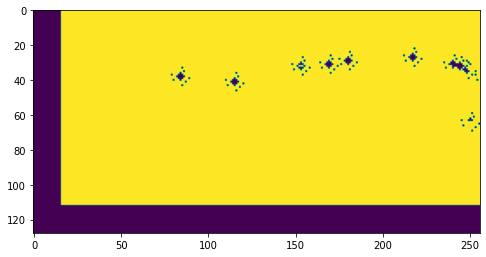

 96%|██████████████████████████████████████████████████████████████████████████████▌   | 23/24 [00:25<00:01,  1.11s/it]

theta_x: 0.2594
theta_y: -0.0052
theta_z: 0.0194
phi: 0.0125
gamma: -0.0343
rho: -0.0020
in.shape
torch.Size([16, 2304, 8, 16])
tensor(-0.0079, device='cuda:0')
tensor(0.0079, device='cuda:0')
tensor([[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  8.6523e-02,  8.6523e-02,  7.0791e-02,
           7.8657e-03,  8.6523e-02,  7.8657e-02, -5.5060e-02,  1.5731e-02,
           0.0000e+00,  0.0000e+00,  7.0791e-02, -1.7800e+01, -1.7887e+01,
          -1.7973e+01],
         [ 0.0000e+00,  0.0000e+00,  8.6523e-02, -7.0791e-02, -1.8036e+01,
           7.8657e-03,  8.6523e-02, -1.5071e+01, -1.6730e+01, -1.5881e+01,
          -1.6998e+01, -1.6778e+01, -1.6927e+01, -1.7690e+01, -6.2926e-02,
          -1.7792e+01],
         [ 0.0000e+00,  0.0000e+00,  8.6523e-02,  8.6523e-02

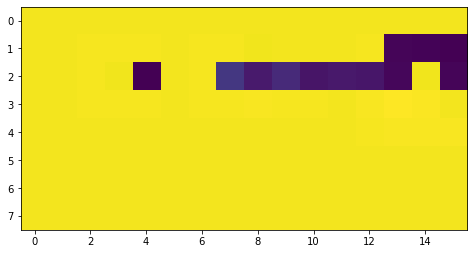

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0885, device='cuda:0')
tensor(0.0531, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


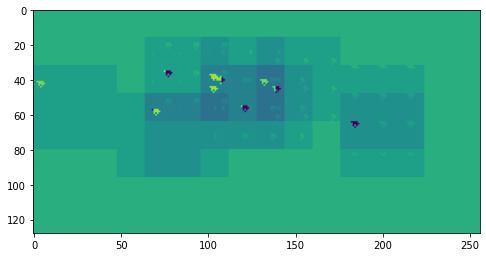

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5002, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


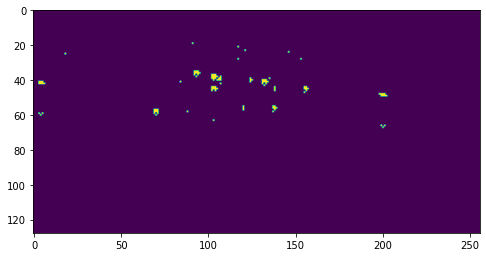

100%|██████████████████████████████████████████████████████████████████████████████████| 24/24 [00:26<00:00,  1.11s/it]

theta_x: 0.2607
theta_y: -0.0070
theta_z: 0.0204
phi: 0.0125
gamma: -0.0346
rho: -0.0020
Train Epoch: (4, 3) 	LR: 0.001000	Loss: 30.657609



  0%|                                                                                           | 0/24 [00:00<?, ?it/s]

in.shape
torch.Size([16, 576, 16, 32])
tensor(-0.0086, device='cuda:0')
tensor(0.0086, device='cuda:0')
tensor([[[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0172,  0.0172, -0.0172,  0.0000,  0.0000,  0.0000,

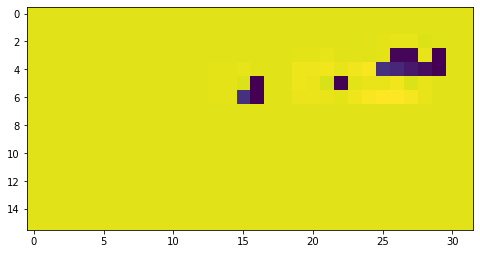

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0873, device='cuda:0')
tensor(0.0611, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


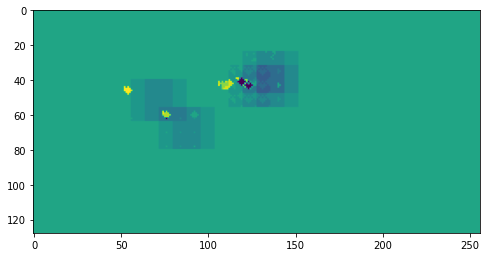

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5003, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


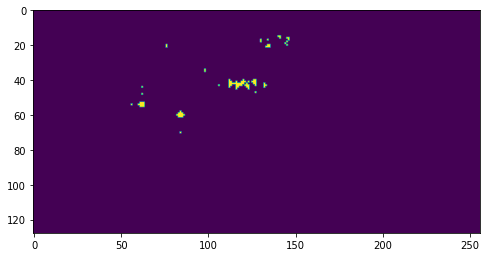

  4%|███▍                                                                               | 1/24 [00:01<00:34,  1.52s/it]

theta_x: 0.2694
theta_y: -0.0098
theta_z: 0.0220
phi: 0.0131
gamma: -0.0358
rho: -0.0017
in.shape
torch.Size([16, 576, 16, 32])
tensor(-0.0085, device='cuda:0')
tensor(0.0085, device='cuda:0')
tensor([[[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0085,  0.0425,  0.0765,  0.0765,  0.0595, -0.0085,
          -0.0510,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  

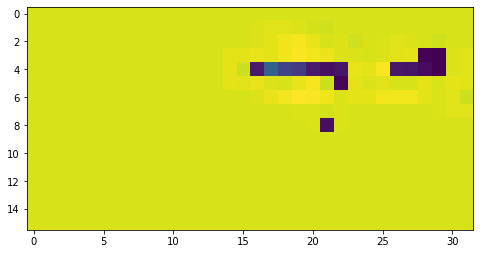

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0880, device='cuda:0')
tensor(0.0616, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


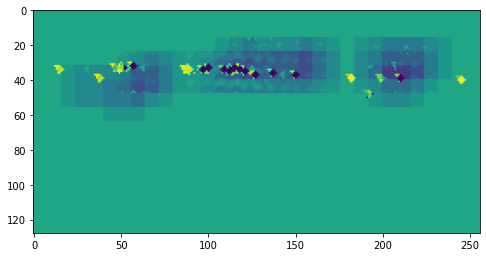

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5003, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


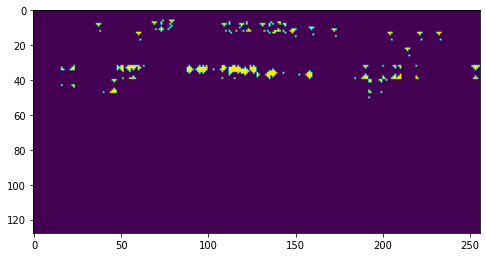

  8%|██████▉                                                                            | 2/24 [00:03<00:33,  1.51s/it]

theta_x: 0.2751
theta_y: -0.0155
theta_z: 0.0218
phi: 0.0135
gamma: -0.0370
rho: -0.0013
in.shape
torch.Size([16, 576, 16, 32])
tensor(-0.0087, device='cuda:0')
tensor(0.0087, device='cuda:0')
tensor([[[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0870,  0.0870, -0.0870,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0870,  0.0870,  0.0870,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  

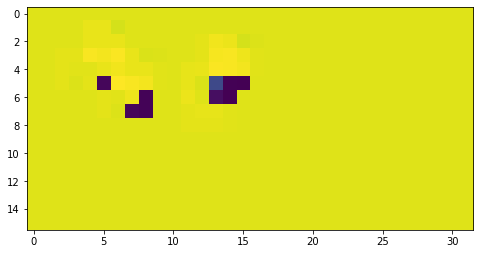

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0881, device='cuda:0')
tensor(0.0617, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


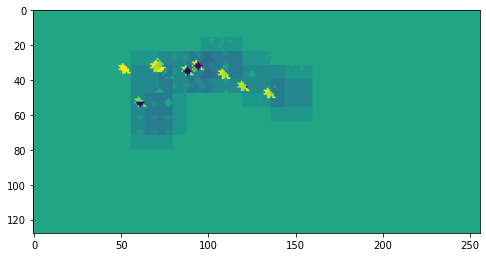

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5003, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


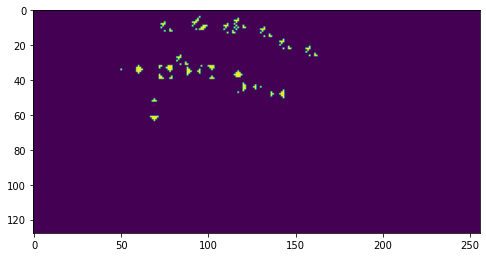

 12%|██████████▍                                                                        | 3/24 [00:04<00:31,  1.51s/it]

theta_x: 0.2802
theta_y: -0.0190
theta_z: 0.0235
phi: 0.0139
gamma: -0.0379
rho: -0.0010
in.shape
torch.Size([16, 576, 16, 32])
tensor(-0.0085, device='cuda:0')
tensor(0.0085, device='cuda:0')
tensor([[[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0680,  0.1530,
           0.1020,  0.0850,  0.0000, -0.0510,  0.1445,  0.0765, -0.1105,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0510,  0.0510, -0.0510,  0.0000,  

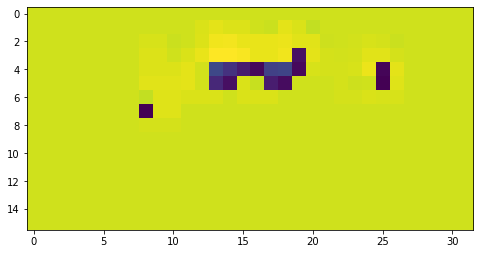

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0885, device='cuda:0')
tensor(0.0619, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


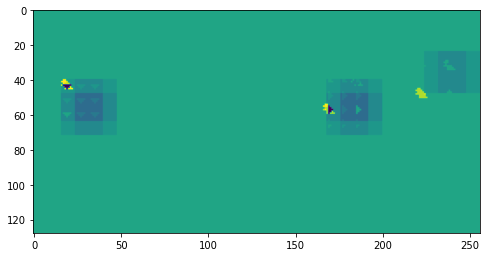

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5004, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


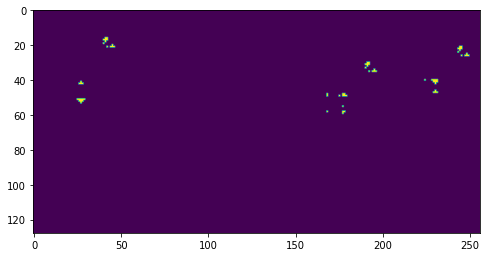

 17%|█████████████▊                                                                     | 4/24 [00:05<00:29,  1.50s/it]

theta_x: 0.2952
theta_y: -0.0215
theta_z: 0.0231
phi: 0.0148
gamma: -0.0393
rho: -0.0007
in.shape
torch.Size([16, 576, 16, 32])
tensor(-0.0085, device='cuda:0')
tensor(0.0085, device='cuda:0')
tensor([[[ 0.0000,  0.0000,  0.0000,  0.0676,  0.0676, -0.0676,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0169,  0.0169, -0.0169,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.1437,  0.1437, -0.0085,  0.0000,
           0.0000,  0.0000,  0.0254,  0.1437,  0.0930, -0.0845,  0.0000,
           0.0000,  0.0000,  0.1268,  0.1268, -0.1268,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.1437,  0.1437,  0.1437,  0.0000,
           0.0845,  0.1268, -0.0169,  0.1015,  0.1437,  

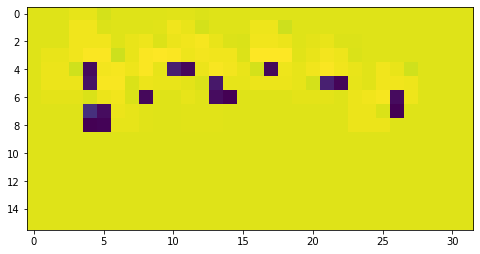

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0880, device='cuda:0')
tensor(0.0622, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


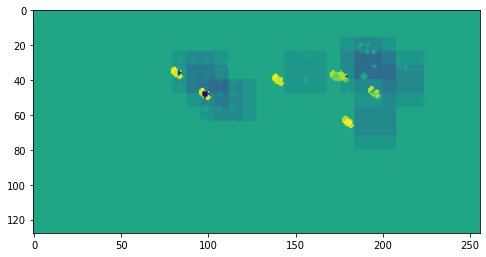

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5004, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


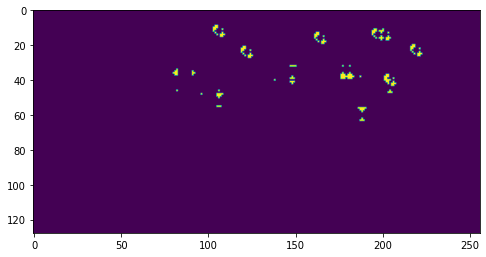

 21%|█████████████████▎                                                                 | 5/24 [00:07<00:28,  1.51s/it]

theta_x: 0.3025
theta_y: -0.0267
theta_z: 0.0231
phi: 0.0153
gamma: -0.0406
rho: -0.0003
in.shape
torch.Size([16, 576, 16, 32])
tensor(-0.0085, device='cuda:0')
tensor(0.0085, device='cuda:0')
tensor([[[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0939,  0.1537, -0.0342,  0.1110,  0.2050, -0.1110,
           0.1452,  0.1452, -0.0171,  0.2306,  0.0939, -0.0427, -0.0854,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.1025,  0.1794,  0.1623,  0.2391,  0.2306,  0.2050,
           0.2135,  0.3587,  0.4527,  0.1110,  0.3587,  

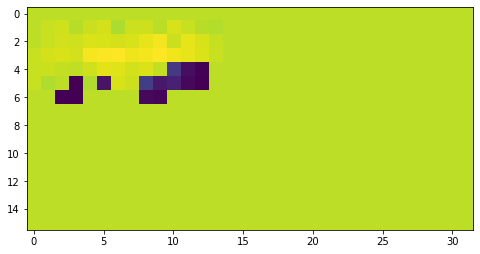

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0869, device='cuda:0')
tensor(0.0608, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


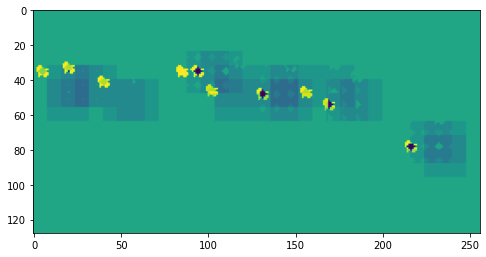

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5004, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


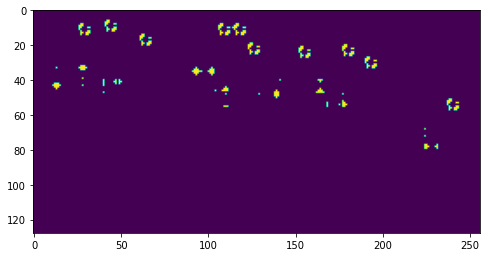

 25%|████████████████████▊                                                              | 6/24 [00:09<00:27,  1.51s/it]

theta_x: 0.3082
theta_y: -0.0235
theta_z: 0.0230
phi: 0.0157
gamma: -0.0413
rho: -0.0004
in.shape
torch.Size([16, 576, 16, 32])
tensor(-0.0083, device='cuda:0')
tensor(0.0083, device='cuda:0')
tensor([[[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0580,
           0.0580, -0.0580,  0.0000,  0.0580,  0.0580, -0.0580,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.1656,
           0.2235,  0.0083, -0.0580,  0.2235,  0.2235, -0.1076,  0.0000,
           0.0248,  0.0248,  0.0331,  0.1490,  0.2318,  0.2318,  0.0497,
           0.1573,  0.0662, -0.1242, -0.0331,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.1656,
           0.2235,  0.2235,  0.0580,  0.2235,  0.2235,  

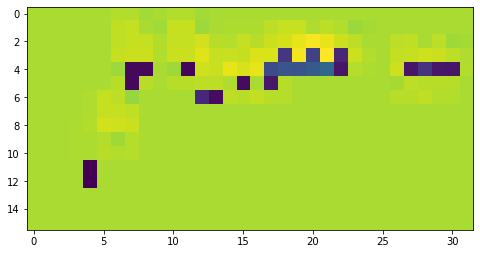

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0870, device='cuda:0')
tensor(0.0609, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


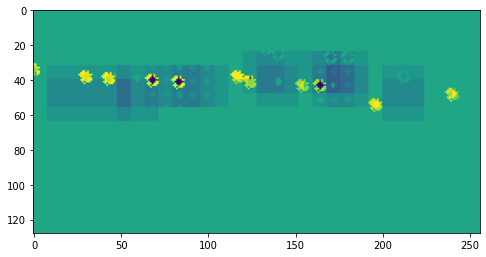

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5004, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


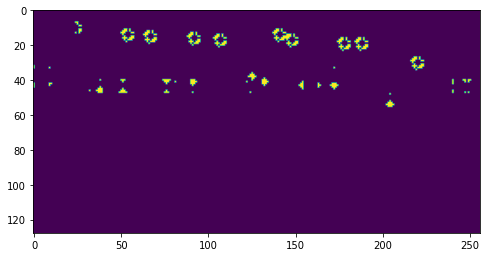

 29%|████████████████████████▏                                                          | 7/24 [00:10<00:25,  1.52s/it]

theta_x: 0.3157
theta_y: -0.0199
theta_z: 0.0215
phi: 0.0163
gamma: -0.0424
rho: -0.0004
in.shape
torch.Size([16, 576, 16, 32])
tensor(-0.0085, device='cuda:0')
tensor(0.0085, device='cuda:0')
tensor([[[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.2116,  0.2708, -0.1523, -0.0592,  0.0000,
           0.0085,  0.2370,  0.2201, -0.0592,  0.1947, -0.1439, -0.0254,
           0.0000,  0.0339,  0.0339,  0.0762,  0.2539,  0.0762, -0.1016,
          -0.0423,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.2201,  0.4316,  0.4740, -0.0339, -0.0592,
           0.0085,  0.2454,  0.2454,  0.4401,  0.2454,  

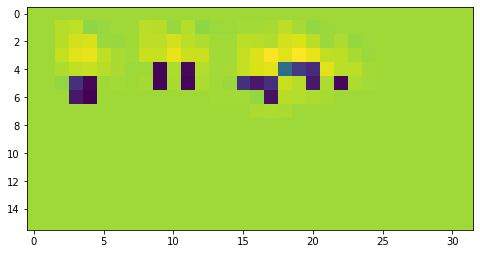

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0867, device='cuda:0')
tensor(0.0607, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


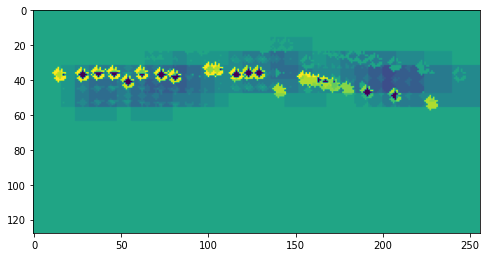

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5004, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


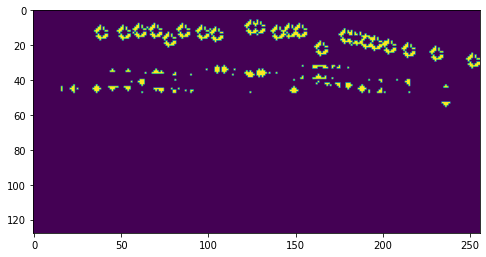

 33%|███████████████████████████▋                                                       | 8/24 [00:12<00:24,  1.53s/it]

theta_x: 0.3224
theta_y: -0.0240
theta_z: 0.0229
phi: 0.0169
gamma: -0.0440
rho: -0.0001
in.shape
torch.Size([16, 576, 16, 32])
tensor(-0.0085, device='cuda:0')
tensor(0.0085, device='cuda:0')
tensor([[[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0085,  0.0085, -0.0085,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0681,
           0.1021, -0.0340, -0.0340,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0851,  0.1277,
          -0.0426,  0.1532,  0.2638, -0.1106, -0.0681,  

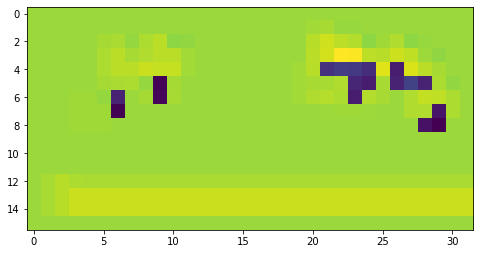

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0890, device='cuda:0')
tensor(0.0623, device='cuda:0')
tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0585,  ..., 0.0000, 0.0000, 0.0000],
         [0.0585, 0.0585, 0.0585,  ..., 0.0000, 0.0000, 0.0000]]],
       device='cuda:0')


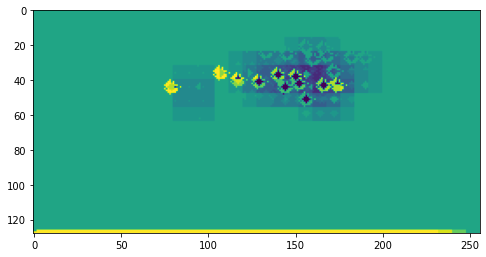

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5005, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


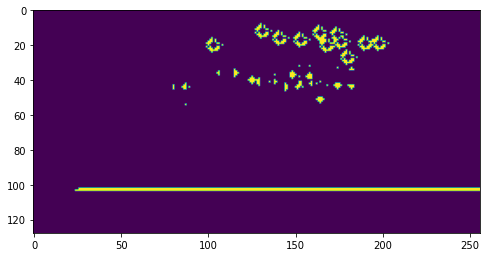

 38%|███████████████████████████████▏                                                   | 9/24 [00:13<00:22,  1.52s/it]

theta_x: 0.3301
theta_y: -0.0254
theta_z: 0.0226
phi: 0.0175
gamma: -0.0451
rho: 0.0001
in.shape
torch.Size([16, 576, 16, 32])
tensor(-0.0082, device='cuda:0')
tensor(0.0082, device='cuda:0')
tensor([[[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0165,  0.0330,  0.0000, -0.0165,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0165,  0.1484,  0.1320,  0.0990,  0.3464,  0.0990,
           0.2309,  0.3546,  0.2887,  0.1072,  0.1732, -0.0247, -0.1567,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0660,  0.3134,  0.4371,  0.0990,  0.4289,  0

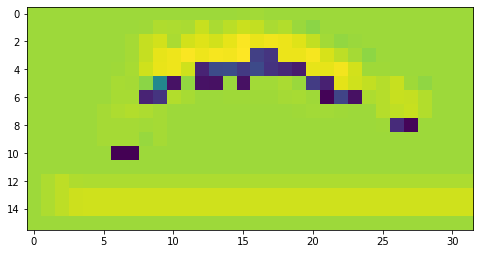

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0879, device='cuda:0')
tensor(0.0616, device='cuda:0')
tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0616, 0.0616,  ..., 0.0000, 0.0000, 0.0000],
         [0.0616, 0.0616, 0.0616,  ..., 0.0000, 0.0000, 0.0000]]],
       device='cuda:0')


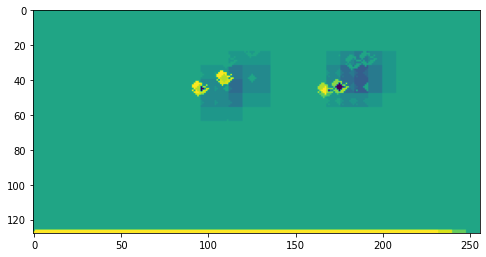

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5005, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


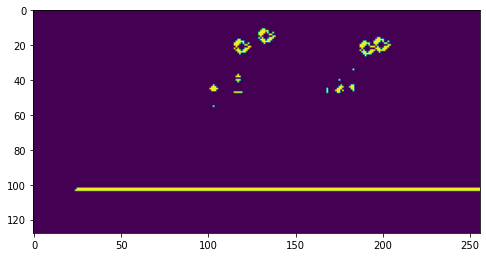

 42%|██████████████████████████████████▏                                               | 10/24 [00:15<00:21,  1.54s/it]

theta_x: 0.3412
theta_y: -0.0262
theta_z: 0.0233
phi: 0.0180
gamma: -0.0463
rho: 0.0003
in.shape
torch.Size([16, 576, 16, 32])
tensor(-0.0085, device='cuda:0')
tensor(0.0085, device='cuda:0')
tensor([[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  2.5488e-02,  1.4443e-01,  1.6992e-01,
           0.0000e+00, -3.3985e-02, -4.2481e-02,  0.0000e+00,  0.0000e+00,
           0.0000e+00

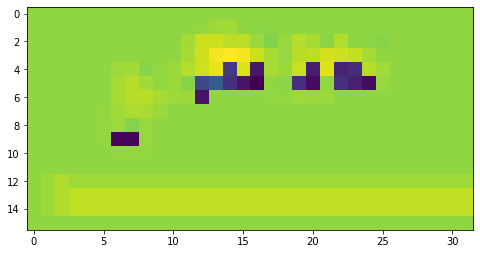

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0890, device='cuda:0')
tensor(0.0623, device='cuda:0')
tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0619, 0.0619, 0.0619,  ..., 0.0000, 0.0000, 0.0000],
         [0.0619, 0.0619, 0.0619,  ..., 0.0000, 0.0000, 0.0000]]],
       device='cuda:0')


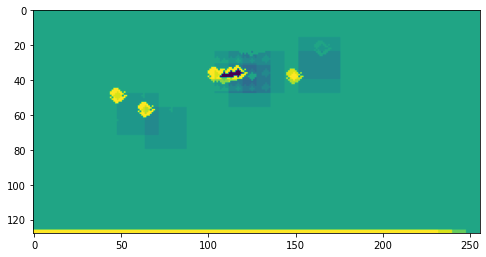

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5005, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


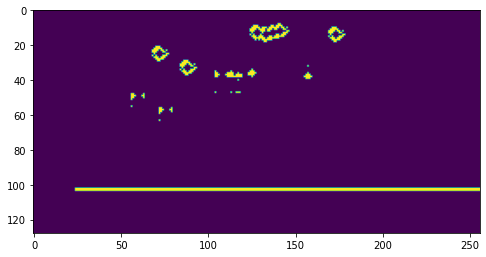

 46%|█████████████████████████████████████▌                                            | 11/24 [00:16<00:19,  1.53s/it]

theta_x: 0.3465
theta_y: -0.0233
theta_z: 0.0232
phi: 0.0186
gamma: -0.0474
rho: 0.0001
in.shape
torch.Size([16, 576, 16, 32])
tensor(-0.0088, device='cuda:0')
tensor(0.0088, device='cuda:0')
tensor([[[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.2643,  0.5463,  0.2115,  0.0088,  0.0176,  0.1938,  0.1410,
          -0.0969, -0.0793,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0

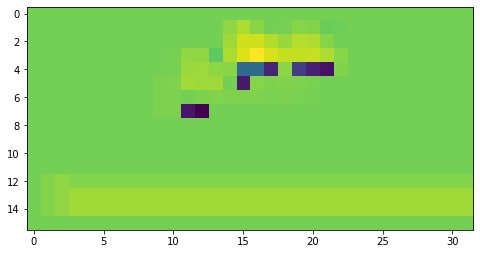

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0881, device='cuda:0')
tensor(0.0617, device='cuda:0')
tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0594, 0.0594, 0.0594,  ..., 0.0000, 0.0000, 0.0000],
         [0.0594, 0.0594, 0.0594,  ..., 0.0000, 0.0000, 0.0000]]],
       device='cuda:0')


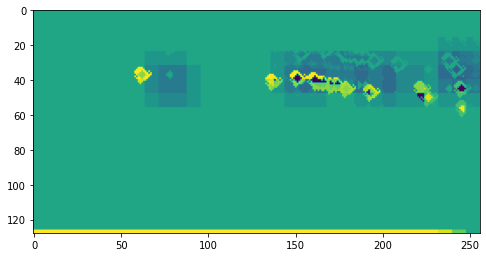

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5005, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


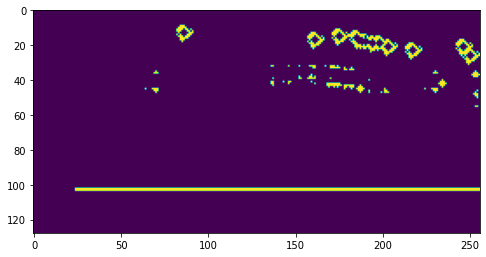

 50%|█████████████████████████████████████████                                         | 12/24 [00:18<00:18,  1.52s/it]

theta_x: 0.3544
theta_y: -0.0244
theta_z: 0.0233
phi: 0.0193
gamma: -0.0488
rho: 0.0003
in.shape
torch.Size([16, 576, 16, 32])
tensor(-0.0084, device='cuda:0')
tensor(0.0084, device='cuda:0')
tensor([[[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.1002,  0.3342,  0.3509,  0.2172,  0.1086, -0.1420, -0.0919,
           0.0000,  0.0334,  0.0334, -0.0334,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.2172,  0.7519,  0.9774,  0.7602,  0.4595,  0

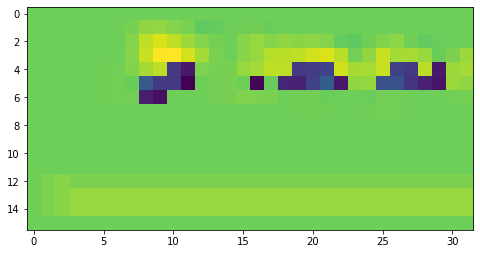

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0873, device='cuda:0')
tensor(0.0611, device='cuda:0')
tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0609, 0.0609, 0.0609,  ..., 0.0000, 0.0000, 0.0000],
         [0.0609, 0.0609, 0.0609,  ..., 0.0000, 0.0000, 0.0000]]],
       device='cuda:0')


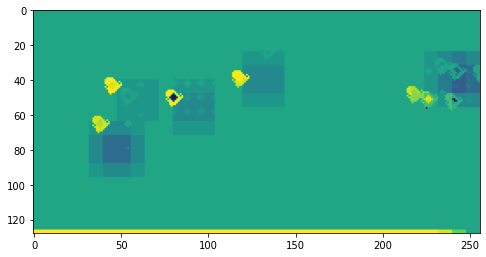

tensor(-0.2503, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5005, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


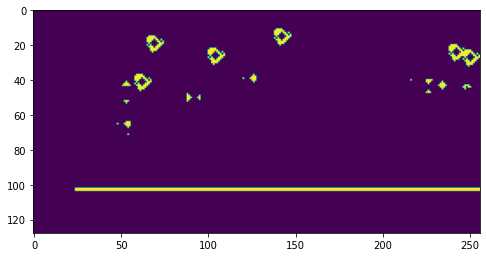

 54%|████████████████████████████████████████████▍                                     | 13/24 [00:19<00:17,  1.55s/it]

theta_x: 0.3599
theta_y: -0.0224
theta_z: 0.0211
phi: 0.0199
gamma: -0.0498
rho: 0.0005
in.shape
torch.Size([16, 576, 16, 32])
tensor(-0.0089, device='cuda:0')
tensor(0.0089, device='cuda:0')
tensor([[[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0891,  0.0980,
          -0.0802, -0.0089,  0.1960,  0.2673, -0.1247, -0.0713,  0.0000,
           0.0000,  0.0000,  0.0000,  0.2228,  0.3742, -0.0713, -0.1515,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.3030,  0.4723,
           0.0446, -0.1515,  0.3475,  0.4723,  0.1693,  0

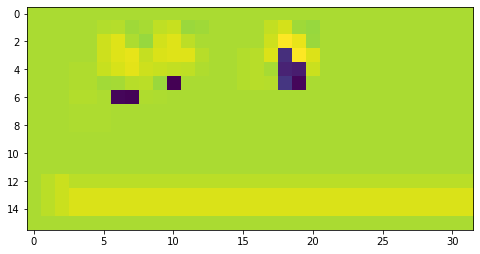

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0891, device='cuda:0')
tensor(0.0624, device='cuda:0')
tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0597, 0.0597, 0.0597,  ..., 0.0000, 0.0000, 0.0000],
         [0.0597, 0.0597, 0.0597,  ..., 0.0000, 0.0000, 0.0000]]],
       device='cuda:0')


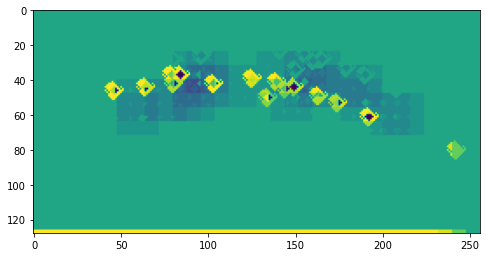

tensor(-0.2503, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5005, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


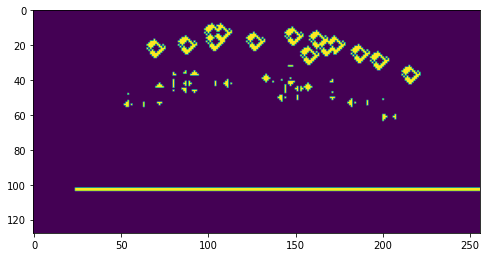

 58%|███████████████████████████████████████████████▊                                  | 14/24 [00:21<00:15,  1.53s/it]

theta_x: 0.3603
theta_y: -0.0237
theta_z: 0.0213
phi: 0.0201
gamma: -0.0505
rho: 0.0007
in.shape
torch.Size([16, 576, 16, 32])
tensor(-0.0090, device='cuda:0')
tensor(0.0090, device='cuda:0')
tensor([[[ 0.0000,  0.2166,  0.2166,  0.0722,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0271,  0.1805,  0.1354, -0.1444, -0.0090,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.2166,  0.2166,  0.0722,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.1986,  0.2437,  0.1173,  0.7312,  0.6680,  0.3611, -0.2347,
          -0.1444,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.2166,  0.2166,  0.0722,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0

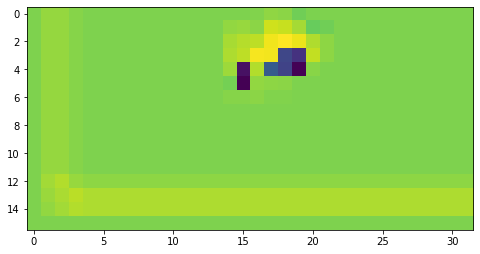

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0903, device='cuda:0')
tensor(0.0632, device='cuda:0')
tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0609, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0609, 0.0609, 0.0609,  ..., 0.0000, 0.0000, 0.0000],
         [0.0609, 0.0609, 0.0609,  ..., 0.0000, 0.0000, 0.0000]]],
       device='cuda:0')


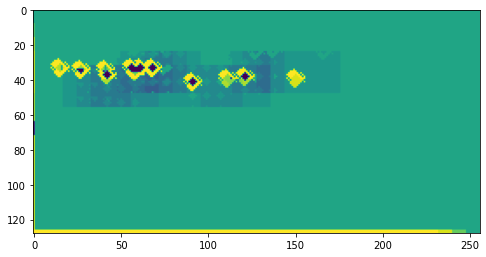

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5005, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


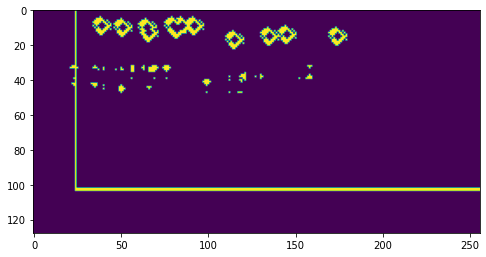

 62%|███████████████████████████████████████████████████▎                              | 15/24 [00:22<00:13,  1.54s/it]

theta_x: 0.3656
theta_y: -0.0215
theta_z: 0.0207
phi: 0.0206
gamma: -0.0512
rho: 0.0006
in.shape
torch.Size([16, 576, 16, 32])
tensor(-0.0090, device='cuda:0')
tensor(0.0090, device='cuda:0')
tensor([[[ 0.0000,  0.2168,  0.2168,  0.0723,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0542,  0.1355,  0.0271, -0.0813,  0.0000,  0.1174,
           0.1988, -0.0361, -0.0813,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.2168,  0.2168,  0.0723,  0.0000,  0.0000,  0.0000,
           0.0000,  0.1446,  0.5240,  0.3433, -0.2168,  0.0000,  0.3343,
           0.6866,  0.3252, -0.0542, -0.0090, -0.0632,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.2168,  0.2168,  0.0723,  0.0000,  0.0000,  0.0000,
           0.0000,  0.1446,  0.5240,  0.5240,  0.3795,  0

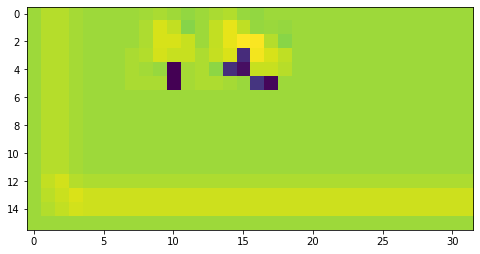

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0905, device='cuda:0')
tensor(0.0634, device='cuda:0')
tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0606, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0606, 0.0606, 0.0606,  ..., 0.0000, 0.0000, 0.0000],
         [0.0606, 0.0606, 0.0606,  ..., 0.0000, 0.0000, 0.0000]]],
       device='cuda:0')


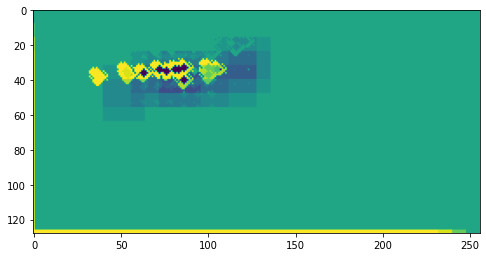

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5005, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


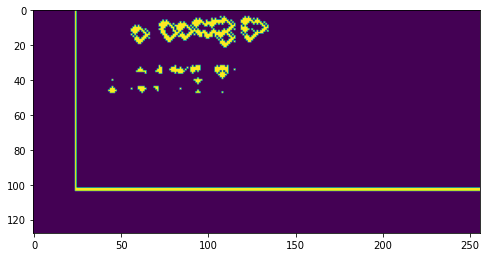

 67%|██████████████████████████████████████████████████████▋                           | 16/24 [00:24<00:12,  1.52s/it]

theta_x: 0.3676
theta_y: -0.0230
theta_z: 0.0216
phi: 0.0207
gamma: -0.0517
rho: 0.0007
in.shape
torch.Size([16, 576, 16, 32])
tensor(-0.0090, device='cuda:0')
tensor(0.0090, device='cuda:0')
tensor([[[ 0.0000,  0.2171,  0.2171,  0.0724,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.2171,  0.2171,  0.0724,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0090,  0.0181,
           0.0000, -0.0090,  0.0000,  0.0000,  0.0000,  0.0995,  0.2804,
           0.0995, -0.1628, -0.0181,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.2171,  0.2171,  0.0724,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0

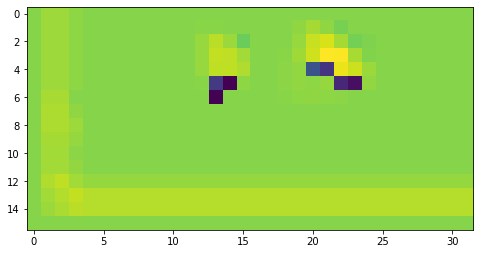

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0910, device='cuda:0')
tensor(0.0637, device='cuda:0')
tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0628, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0628, 0.0628, 0.0628,  ..., 0.0000, 0.0000, 0.0000],
         [0.0628, 0.0628, 0.0628,  ..., 0.0000, 0.0000, 0.0000]]],
       device='cuda:0')


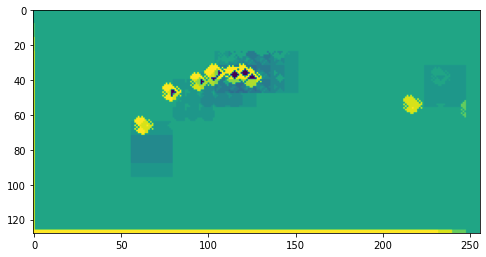

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5005, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


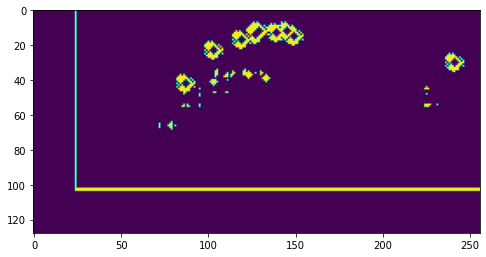

 71%|██████████████████████████████████████████████████████████                        | 17/24 [00:25<00:10,  1.52s/it]

theta_x: 0.3682
theta_y: -0.0232
theta_z: 0.0208
phi: 0.0211
gamma: -0.0524
rho: 0.0009
in.shape
torch.Size([16, 576, 16, 32])
tensor(-0.0087, device='cuda:0')
tensor(0.0087, device='cuda:0')
tensor([[[ 0.0000,  0.2093,  0.2267,  0.0872,  0.0000,  0.0349,  0.0610,
           0.1046,  0.0000, -0.0610,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0174,  0.0349,  0.0000, -0.0174,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.2093,  0.5406,  0.5754,  0.2616,  0.5580,  0.4359,
           0.5754,  0.2877, -0.1831, -0.1482,  0.0000,  0.0000,  0.0000,
           0.0872,  0.4621,  0.6714,  0.0959, -0.2964, -0.0523,  0.0959,
           0.3139,  0.2354, -0.1046, -0.1133,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.2093,  0.6016,  0.6452,  0.9068,  1.0201,  1.1858,
           1.2381,  1.0201,  0.5842,  0.1482,  0.0000,  0

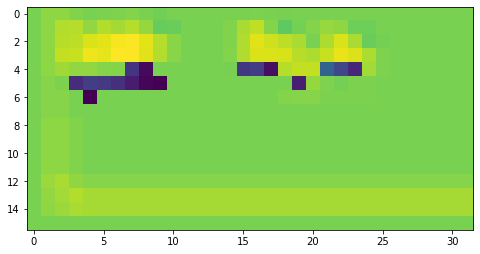

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0896, device='cuda:0')
tensor(0.0627, device='cuda:0')
tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0605, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0605, 0.0605, 0.0605,  ..., 0.0000, 0.0000, 0.0000],
         [0.0605, 0.0605, 0.0605,  ..., 0.0000, 0.0000, 0.0000]]],
       device='cuda:0')


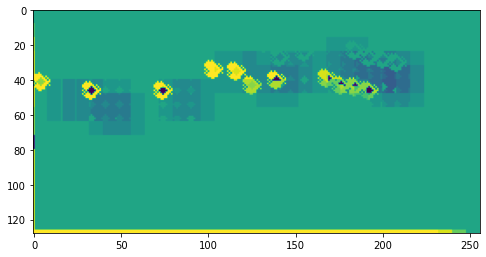

tensor(-0.2503, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5005, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


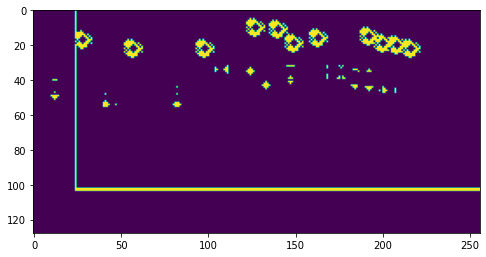

 75%|█████████████████████████████████████████████████████████████▌                    | 18/24 [00:27<00:09,  1.52s/it]

theta_x: 0.3727
theta_y: -0.0259
theta_z: 0.0218
phi: 0.0214
gamma: -0.0533
rho: 0.0011
in.shape
torch.Size([16, 576, 16, 32])
tensor(-0.0087, device='cuda:0')
tensor(0.0087, device='cuda:0')
tensor([[[ 0.0000,  1.4258,  3.0863,  3.8514,  3.9035,  3.8948,  3.8948,
           3.8948,  3.8601,  3.8079,  3.8775,  3.9470,  3.8948,  3.8948,
           3.8948,  3.8948,  3.8948,  3.8948,  3.8948,  3.8948,  3.8948,
           3.8948,  3.8948,  3.8948,  3.8948,  3.8948,  3.8948,  3.8948,
           3.8948,  3.8948,  3.8948,  3.8948],
         [ 0.0000,  1.3128,  2.9385,  3.8601,  3.9209,  3.8948,  3.8948,
           3.7731,  3.5732,  3.6166,  3.8253,  3.9905,  3.8948,  3.8948,
           3.8948,  3.8948,  3.8948,  3.8948,  3.7992,  3.6862,  3.8775,
           4.0079,  3.8948,  3.8775,  3.7471,  3.7818,  4.0166,  3.8601,
           3.8775,  3.9209,  3.8948,  3.8948],
         [ 0.0000,  1.3128,  2.9385,  3.6340,  3.8514,  3.8948,  3.8948,
           3.7384,  3.3819,  3.2515,  3.6514,  3.6949,  3

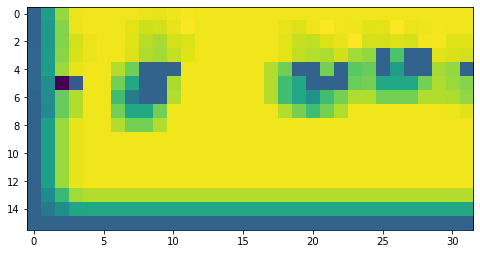

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0914, device='cuda:0')
tensor(0.0640, device='cuda:0')
tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0640, 0.0000, 0.0640,  ..., 0.0000, 0.0000, 0.0000],
         [0.0640, 0.0640, 0.0640,  ..., 0.0000, 0.0000, 0.0000],
         [0.0640, 0.0640, 0.0640,  ..., 0.0000, 0.0000, 0.0000]]],
       device='cuda:0')


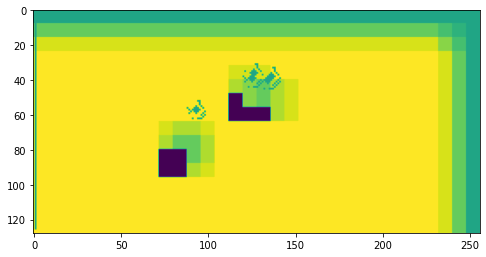

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5004, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


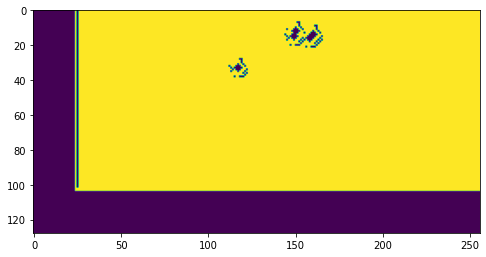

 79%|████████████████████████████████████████████████████████████████▉                 | 19/24 [00:28<00:07,  1.51s/it]

theta_x: 0.3739
theta_y: -0.0271
theta_z: 0.0213
phi: 0.0215
gamma: -0.0534
rho: 0.0011
in.shape
torch.Size([16, 576, 16, 32])
tensor(-0.0085, device='cuda:0')
tensor(0.0085, device='cuda:0')
tensor([[[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0

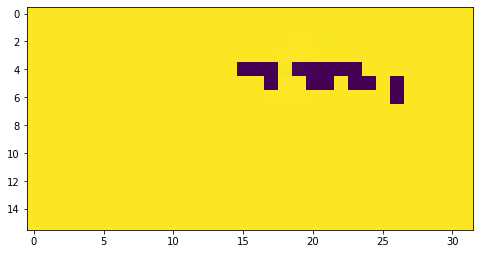

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0856, device='cuda:0')
tensor(0.0478, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


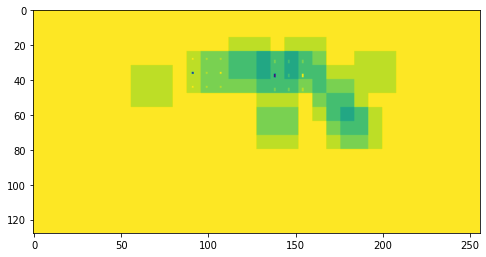

tensor(-0.2500, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5001, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


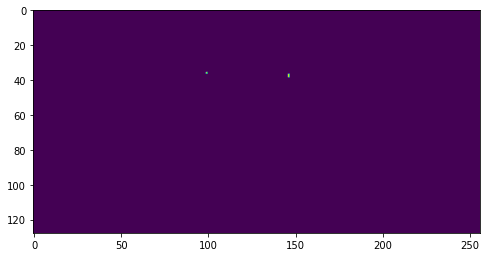

 83%|████████████████████████████████████████████████████████████████████▎             | 20/24 [00:30<00:06,  1.52s/it]

theta_x: 0.3741
theta_y: -0.0271
theta_z: 0.0213
phi: 0.0215
gamma: -0.0534
rho: 0.0011
in.shape
torch.Size([16, 576, 16, 32])
tensor(-0.0084, device='cuda:0')
tensor(0.0084, device='cuda:0')
tensor([[[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0

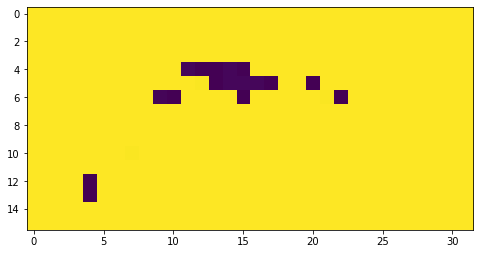

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0884, device='cuda:0')
tensor(0.0606, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


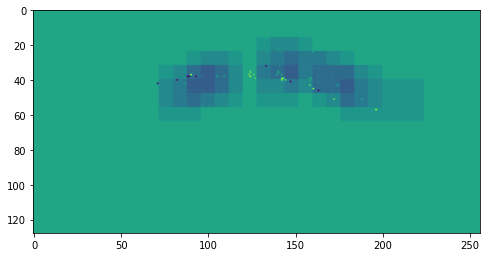

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5001, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


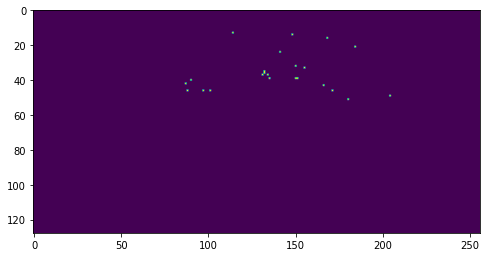

 88%|███████████████████████████████████████████████████████████████████████▊          | 21/24 [00:32<00:04,  1.56s/it]

theta_x: 0.3742
theta_y: -0.0276
theta_z: 0.0215
phi: 0.0215
gamma: -0.0535
rho: 0.0012
in.shape
torch.Size([16, 576, 16, 32])
tensor(-0.0083, device='cuda:0')
tensor(0.0083, device='cuda:0')
tensor([[[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0

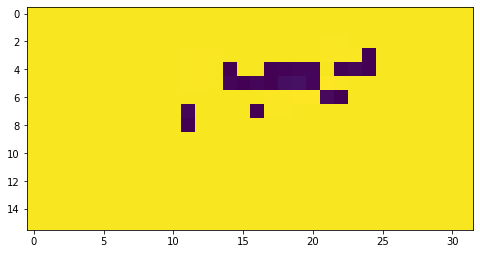

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0869, device='cuda:0')
tensor(0.0595, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


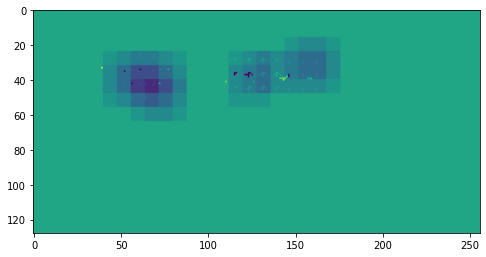

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5002, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


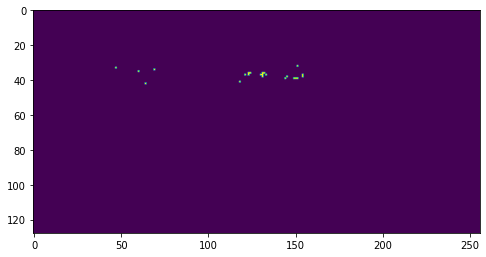

 92%|███████████████████████████████████████████████████████████████████████████▏      | 22/24 [00:33<00:03,  1.53s/it]

theta_x: 0.3747
theta_y: -0.0286
theta_z: 0.0218
phi: 0.0216
gamma: -0.0536
rho: 0.0013
in.shape
torch.Size([16, 576, 16, 32])
tensor(-0.0083, device='cuda:0')
tensor(0.0083, device='cuda:0')
tensor([[[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0083,  0.0083, -0.0083,  0.0000,  0.0000,  0.0083,
           0.0083, -0.0083,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0083,  0.0083,  0.0083,  0.0000,  0.0000,  0.0083,
           0.0083,  0.0083,  0.0000,  0.0000,  0.0000,  0

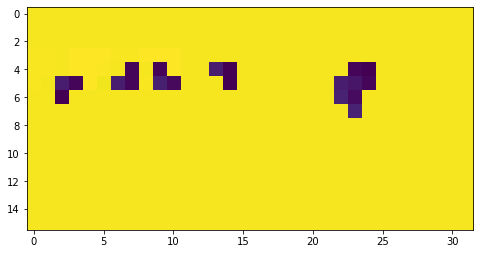

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0891, device='cuda:0')
tensor(0.0624, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


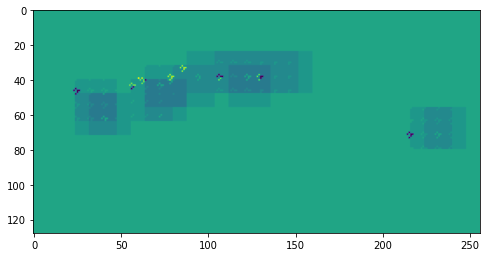

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5002, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


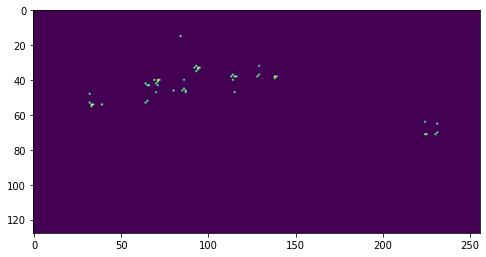

 96%|██████████████████████████████████████████████████████████████████████████████▌   | 23/24 [00:35<00:01,  1.52s/it]

theta_x: 0.3772
theta_y: -0.0273
theta_z: 0.0215
phi: 0.0218
gamma: -0.0540
rho: 0.0013
in.shape
torch.Size([16, 576, 16, 32])
tensor(-0.0084, device='cuda:0')
tensor(0.0084, device='cuda:0')
tensor([[[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0084,  0.0084,  0.0000,  0.0084, -0.0084,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0084,  0.0084, -0.0084,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0084,  0.0168,  0.0252,  0.0000,  0.0084,
           0.0084,  0.0084, -0.0084,  0.0000,  0.0000,  0

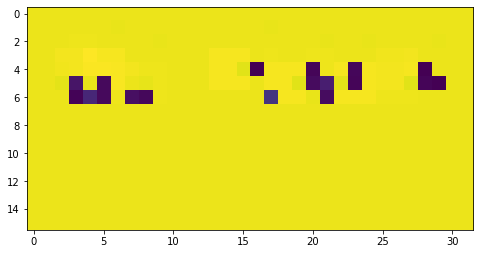

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0877, device='cuda:0')
tensor(0.0614, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


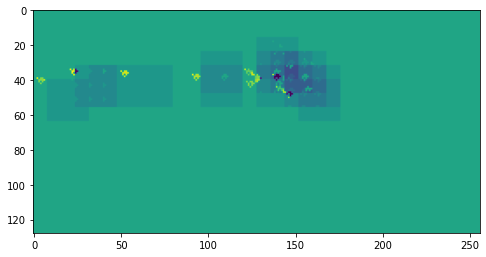

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5002, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


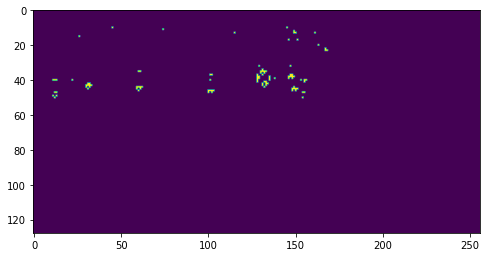

100%|██████████████████████████████████████████████████████████████████████████████████| 24/24 [00:36<00:00,  1.52s/it]

theta_x: 0.3787
theta_y: -0.0267
theta_z: 0.0214
phi: 0.0220
gamma: -0.0545
rho: 0.0013
Train Epoch: (3, 0) 	LR: 0.001000	Loss: 69.766304



  0%|                                                                                           | 0/24 [00:00<?, ?it/s]

in.shape
torch.Size([16, 576, 16, 32])
tensor(-0.0085, device='cuda:0')
tensor(0.0085, device='cuda:0')
tensor([[[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0085,  0.0085, -0.0085,  0.0169,

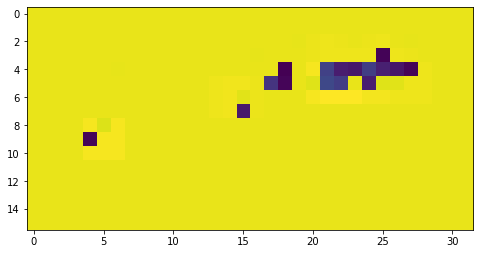

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0881, device='cuda:0')
tensor(0.0616, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


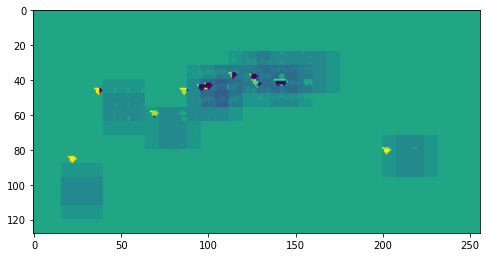

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5002, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


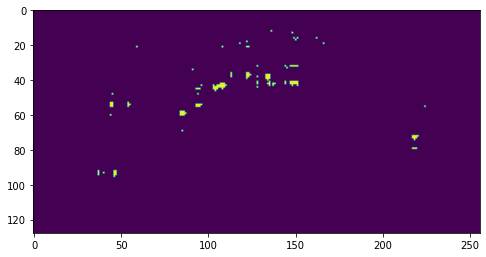

  4%|███▍                                                                               | 1/24 [00:01<00:34,  1.52s/it]

theta_x: 0.3802
theta_y: -0.0278
theta_z: 0.0224
phi: 0.0222
gamma: -0.0551
rho: 0.0015
in.shape
torch.Size([16, 576, 16, 32])
tensor(-0.0084, device='cuda:0')
tensor(0.0084, device='cuda:0')
tensor([[[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0084,  0.0084, -0.0084,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0084,  0.0084, -0.0084,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0084,  0.0084,  0.0084,  0.0084,  0.0252,  0.0084, -0.0168,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0084,  0.0084,  0.0084,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0

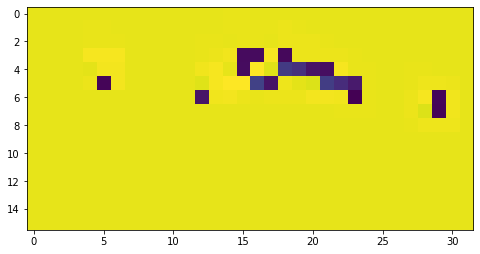

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0853, device='cuda:0')
tensor(0.0597, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


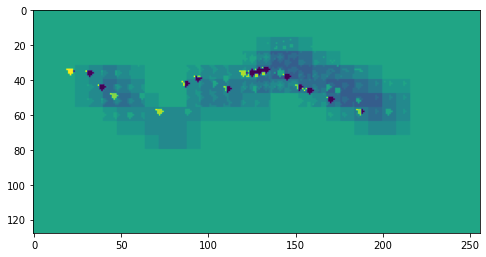

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5003, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


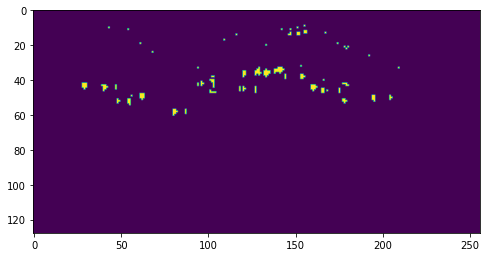

  8%|██████▉                                                                            | 2/24 [00:03<00:33,  1.52s/it]

theta_x: 0.3827
theta_y: -0.0301
theta_z: 0.0220
phi: 0.0225
gamma: -0.0560
rho: 0.0018
in.shape
torch.Size([16, 576, 16, 32])
tensor(-0.0083, device='cuda:0')
tensor(0.0083, device='cuda:0')
tensor([[[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0083,  0.0083, -0.0083,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0083,  0.0415,  0.0249, -0.0332,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0083,  0.0083, -0.0083,  0.0000,  0.0083,  0

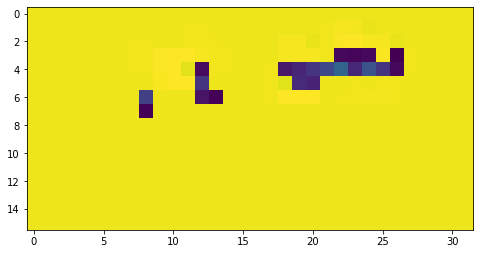

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0877, device='cuda:0')
tensor(0.0614, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


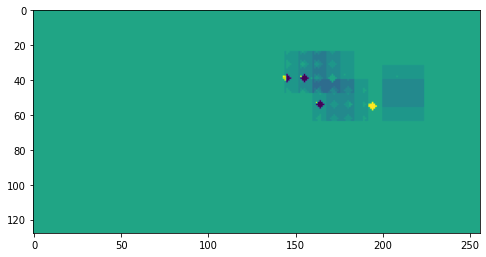

tensor(-0.2501, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5003, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


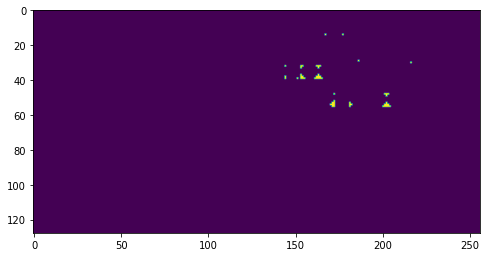

 12%|██████████▍                                                                        | 3/24 [00:04<00:31,  1.51s/it]

theta_x: 0.3835
theta_y: -0.0284
theta_z: 0.0221
phi: 0.0228
gamma: -0.0566
rho: 0.0019
in.shape
torch.Size([16, 576, 16, 32])
tensor(-0.0086, device='cuda:0')
tensor(0.0086, device='cuda:0')
tensor([[[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0430,  0.0430,
          -0.0430,  0.0000,  0.0000,  0.0000,  0.0000,  0.0258,  0.1635,
           0.1893, -0.0602, -0.0775,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0430,  0.0430,
           0.0430,  0.0000,  0.0000,  0.0000,  0.0000,  0

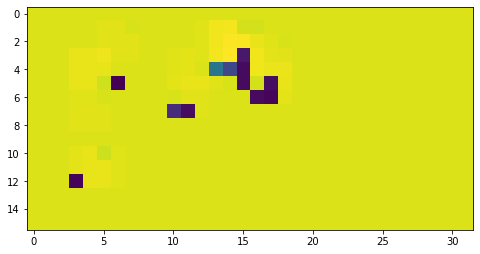

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0881, device='cuda:0')
tensor(0.0617, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


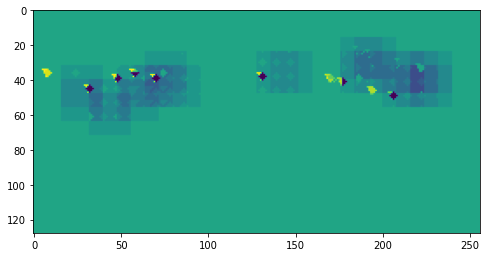

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5003, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


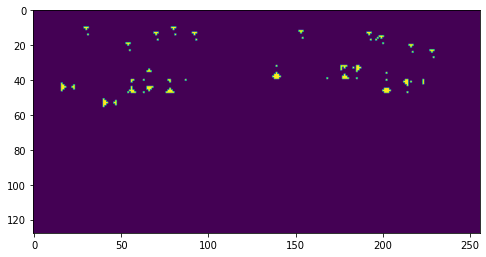

 17%|█████████████▊                                                                     | 4/24 [00:05<00:29,  1.50s/it]

theta_x: 0.3857
theta_y: -0.0220
theta_z: 0.0193
phi: 0.0231
gamma: -0.0571
rho: 0.0018
in.shape
torch.Size([16, 576, 16, 32])
tensor(-0.0082, device='cuda:0')
tensor(0.0082, device='cuda:0')
tensor([[[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0082,  0.0411,  0.0575,
           0.0082,  0.0164,  0.0329, -0.0329,  0.1151,  0.1644, -0.0329,
          -0.0329,  0.0411,  0.0000, -0.0247,  0.0411,  0.0411,  0.0000,
           0.0411, -0.0411,  0.0164,  0.0329,  0.0000, -0.0164,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0082,  0.0904,  0.1562,
           0.0575,  0.1068,  0.1068, -0.0082,  0.1726,  0

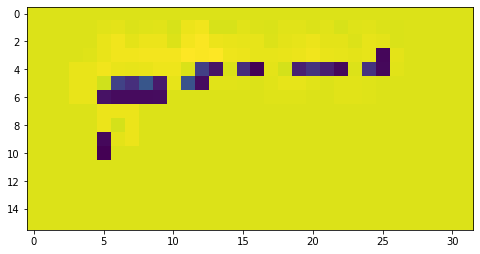

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0882, device='cuda:0')
tensor(0.0618, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


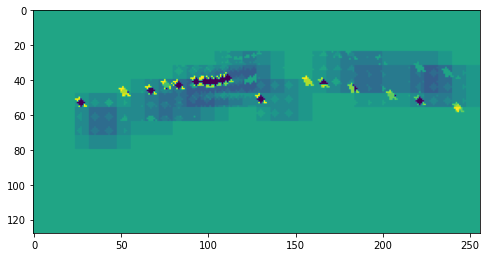

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5003, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


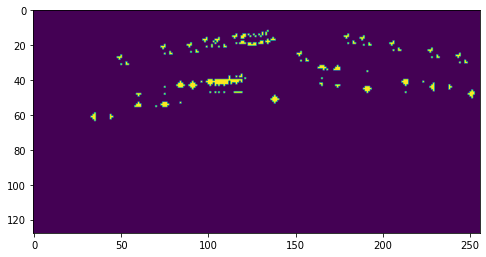

 21%|█████████████████▎                                                                 | 5/24 [00:07<00:28,  1.49s/it]

theta_x: 0.3863
theta_y: -0.0219
theta_z: 0.0175
phi: 0.0234
gamma: -0.0578
rho: 0.0019
in.shape
torch.Size([16, 576, 16, 32])
tensor(-0.0077, device='cuda:0')
tensor(0.0077, device='cuda:0')
tensor([[[ 0.0000e+00,  1.5337e-02,  1.5337e-02,  0.0000e+00,  1.5337e-02,
           0.0000e+00,  3.0675e-02,  4.6012e-02,  6.1349e-02, -1.5337e-02,
          -3.0675e-02,  3.8343e-02,  5.3680e-02,  1.5337e-02,  2.3006e-02,
          -3.8343e-02,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  9.9692e-02,  1.0736e-01,  1.5337e-02,  1.1503e-01,
           9.2024e-02,  1.5337e-01,  1.8405e-01,  1.6104e-01,  5.3680e-02,
          -3.8343e-02,  6.1349e-02,  2.1472e-01,  3.4509e-01,  1.6871e-01,
           7.6686e-02, -5.3680e-02,  4.6566e-10,  9.9692e-02,  9.9692e-02,
           1.8405e-01

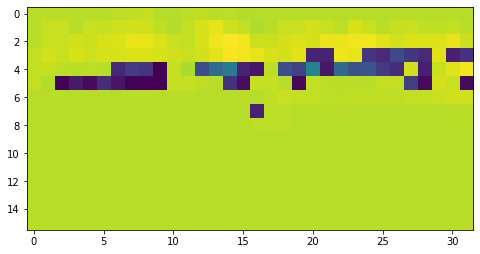

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0885, device='cuda:0')
tensor(0.0619, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


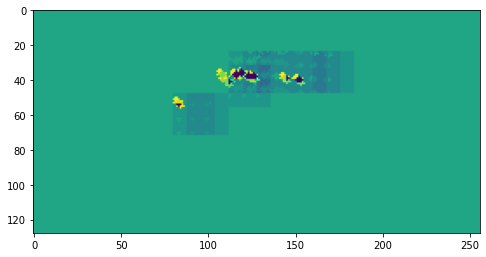

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5004, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


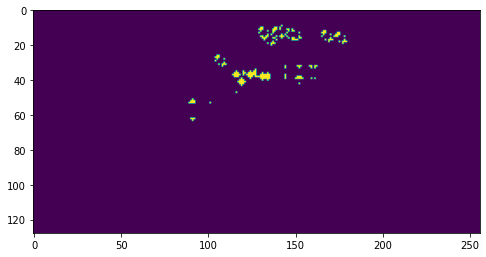

 25%|████████████████████▊                                                              | 6/24 [00:08<00:26,  1.49s/it]

theta_x: 0.3846
theta_y: -0.0239
theta_z: 0.0181
phi: 0.0236
gamma: -0.0584
rho: 0.0023
in.shape
torch.Size([16, 576, 16, 32])
tensor(-0.0083, device='cuda:0')
tensor(0.0083, device='cuda:0')
tensor([[[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0165,  0.0165, -0.0165,  0.0000,  0.0083,  0.0165,
           0.0000, -0.0083,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0992,  0.1571, -0.0083,  0.0165,  0.2233,  0.1736,
           0.0910,  0.1654,  0.1240,  0.1654,  0.0579, -0.1488, -0.0165,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0165,  0.0165,
          -0.0165,  0.0992,  0.2563,  0.3142,  0.1736,  0

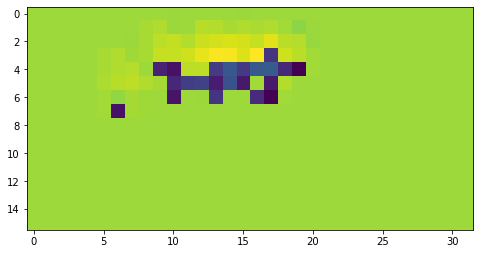

grad_output[0].shape
torch.Size([16, 1, 128, 256])
tensor(-0.0873, device='cuda:0')
tensor(0.0611, device='cuda:0')
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


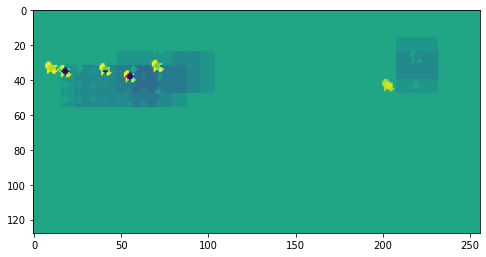

tensor(-0.2502, device='cuda:0', grad_fn=<MinBackward1>)
tensor(0.5004, device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


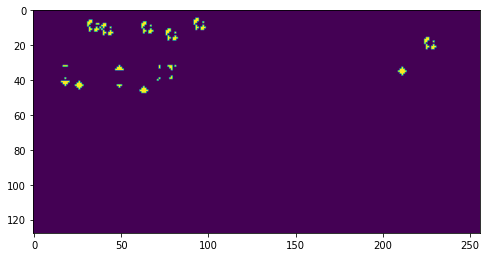

 29%|████████████████████████▏                                                          | 7/24 [00:10<00:25,  1.50s/it]

theta_x: 0.3858
theta_y: -0.0211
theta_z: 0.0172
phi: 0.0239
gamma: -0.0589
rho: 0.0022


In [ ]:
import time
%time


n_epochs_list = [4]
lr_list = [1e-3]
batch_size = 16
n = 4
optimizer = None
model = None


train_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, num_workers=0, sampler=train_sampler)
dev_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, num_workers=0, sampler=valid_sampler)

fileName = None
dev_history = pd.DataFrame(index=pd.MultiIndex.from_tuples((), names=['epoch', 'lr']), columns=['theta_x', 'theta_y', 'theta_z', 'dev_loss'])

torch.cuda.empty_cache()
gc.collect()

for i_epoch in range(len(n_epochs_list)):
    for i_lr in range(len(lr_list)):
        n_epochs = n_epochs_list[i_epoch]
        lr = lr_list[i_lr]
        train_history = pd.DataFrame(index=pd.MultiIndex.from_tuples((), names=['zoom', 'epoch', 'batch_id']), columns=['theta_x', 'theta_y', 'theta_z', 'loss'])

        model = create_model(CAMERA, n)
        if fileName is not None:
            state_dict = torch.load(fileName, map_location='cpu')
            model.load_state_dict(state_dict, strict=False)
            del state_dict
            print("Loaded!!")
        model = model.to(device)

        torch.cuda.empty_cache()

        gc.collect()
        optimizer = optim.SGD(list(model.parameters()), lr=lr)
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=n_epochs, gamma=1.25)

        torch.cuda.empty_cache()
        gc.collect()

        for i in range(n+1):
            for epoch in range(n_epochs):
                zoom = n-i
                torch.cuda.empty_cache()
                gc.collect()

                loader = train_loader
                train_loop_fn(loader, zoom, epoch, train_history)
                
                # scheduler.step()

        loader = dev_loader
        start = time.time()*1000.0
        evaluate_model(loader, (n_epochs, lr), dev_history)
        t_interval = time.time()*1000.0 - start
        print("Speed: {} ms/sample".format(t_interval/(len(dev_loader)*batch_size)))

        gc.collect()
        optimizer = None
        gc.collect()

        train_history.to_csv('train_history_{}_{}.csv'.format(i_epoch, i_lr))
        torch.save(model.state_dict(), "./model_{}_{}.pth".format(i_epoch, i_lr))
dev_history.to_csv('dev_history.csv')

# Result Assessment

**Quantification**

In [ ]:
for i_epoch in range(len(n_epochs_list)):
    for i_lr in range(len(lr_list)):
        train_history = pd.read_csv('train_history_{}_{}.csv'.format(i_epoch, i_lr))
        train_history[['loss']].plot();
        train_history[['theta_x', 'theta_y', 'theta_z']].plot();

In [ ]:
for i_epoch in range(len(n_epochs_list)):
    for i_lr in range(len(lr_list)):
        train_history = pd.read_csv('train_history_{}_{}.csv'.format(i_epoch, i_lr))
        train_history[['loss']].plot();
        train_history[['phi', 'gamma', 'rho']].plot();

In [ ]:
dev_history

In [ ]:
for i_epoch in range(len(n_epochs_list)):
    for i_lr in range(len(lr_list)):
        train_history = pd.read_csv('train_history_{}_{}.csv'.format(i_epoch, i_lr))
        ax = train_history[['theta_x', 'theta_y', 'theta_z']].plot()
        fig = ax.get_figure()
        fig.savefig('./position.png')

In [ ]:
for i_epoch in range(len(n_epochs_list)):
    for i_lr in range(len(lr_list)):
        train_history = pd.read_csv('train_history_{}_{}.csv'.format(i_epoch, i_lr))
        ax = train_history[['phi', 'gamma', 'rho']].plot()
        fig = ax.get_figure()
        fig.savefig('./orientation.png')

**Assessing Camera Calibration via Output-Target Image Comparison**

In [ ]:
with torch.no_grad():
    for batch_idx, (r_mask_batch, input_2Dr_batch, target_2Dr_batch) in enumerate(tqdm(loader)):
        r_mask_batch, input_2Dr_batch, target_2Dr_batch = r_mask_batch.to(device), input_2Dr_batch.to(device), target_2Dr_batch.to(device)

        r, p, y, r_mask, weights = model(input_2Dr_batch, r_mask_batch, r_mask_batch)
        
        plt.figure(figsize=(8,8))
        plt.imshow((r_mask_batch[0,:,:,:].permute(1,2,0).detach().cpu().numpy()[:,:,-1]).squeeze())
        plt.show()
        
        plt.figure(figsize=(8,8))
        plt.imshow((target_2Dr_batch[0,:,:,:].permute(1,2,0).detach().cpu().numpy()[:,:,-1]).squeeze())
        plt.show()
        
        weights = utils.recover_size(weights, n, 0)
        print("out_batch")
        print(weights.min())
        print(weights.max())
        plt.figure(figsize=(8,8))
        plt.imshow(((weights>specials.OFF_THRESH)[0,:,:,:].permute(1,2,0).detach().cpu().numpy()[:,:,-1]).squeeze())
        plt.show()
        break

# Convert tensors to numpy arrays (make sure they are on CPU)
weights_np = (weights[:,-1,:,:]>specials.OFF_THRESH).float().cpu().numpy()
mask_np = (r_mask_batch[:,0,:,:]).cpu().numpy()
target_np = (target_2Dr_batch[:,0,:,:]).cpu().numpy()

fig, axes = plt.subplots(4, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(16):
    ax = axes[i]
    ax.imshow(weights_np[i], cmap='gray', interpolation='nearest', vmin=0, vmax=1)

    out_points = np.argwhere(weights_np[i] > 0)
    target_points = np.argwhere(target_np[i] > 0)

    if target_points.size > 0:
        ax.scatter(target_points[:, 1], target_points[:, 0], facecolors='none',
                   edgecolors='red', s=10, label='Output')

    if out_points.size > 0:
        ax.scatter(out_points[:, 1], out_points[:, 0], marker='x',
                   color='blue', s=10, label='Target')

    ax.set_title(f"Image {i+1}", fontsize=10)
    ax.axis('off')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')

plt.tight_layout()
plt.show()

*Before calibration*

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(16):
    ax = axes[i]
    ax.imshow(weights_np[i], cmap='gray', interpolation='nearest', vmin=0, vmax=1)

    mask_points = np.argwhere(mask_np[i] == 1)
    target_points = np.argwhere(target_np[i] == 1)

    if mask_points.size > 0:
        ax.scatter(mask_points[:, 1], mask_points[:, 0], facecolors='none',
                   edgecolors='red', s=10, label='Mask')

    if target_points.size > 0:
        ax.scatter(target_points[:, 1], target_points[:, 0], marker='x',
                   color='blue', s=10, label='Target')

    ax.set_title(f"Image {i+1}", fontsize=10)
    ax.axis('off')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')

plt.tight_layout()
plt.show()